# 데이터 불러오기

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# 데이터 불러오기
train_df = pd.read_csv('/content/train_dataset.csv')
test_df = pd.read_csv('/content/test_dataset.csv')

In [ ]:
train_df.head().T

,0,1,2,3,4
age,35.0,20.0,45.0,45.0,20.0
height(cm),170.0,175.0,155.0,165.0,165.0
weight(kg),85.0,110.0,65.0,80.0,60.0
waist(cm),97.0,110.0,86.0,94.0,81.0
eyesight(left),0.9,0.7,0.9,0.8,1.5
eyesight(right),0.9,0.9,0.9,0.7,0.1
hearing(left),1.0,1.0,1.0,1.0,1.0
hearing(right),1.0,1.0,1.0,1.0,1.0
systolic,118.0,119.0,110.0,158.0,109.0
relaxation,78.0,79.0,80.0,88.0,64.0


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38984 entries, 0 to 38983
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  38984 non-null  int64  
 1   height(cm)           38984 non-null  int64  
 2   weight(kg)           38984 non-null  int64  
 3   waist(cm)            38984 non-null  float64
 4   eyesight(left)       38984 non-null  float64
 5   eyesight(right)      38984 non-null  float64
 6   hearing(left)        38984 non-null  int64  
 7   hearing(right)       38984 non-null  int64  
 8   systolic             38984 non-null  int64  
 9   relaxation           38984 non-null  int64  
 10  fasting blood sugar  38984 non-null  int64  
 11  Cholesterol          38984 non-null  int64  
 12  triglyceride         38984 non-null  int64  
 13  HDL                  38984 non-null  int64  
 14  LDL                  38984 non-null  int64  
 15  hemoglobin           38984 non-null 

In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16708 entries, 0 to 16707
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  16708 non-null  int64  
 1   height(cm)           16708 non-null  int64  
 2   weight(kg)           16708 non-null  int64  
 3   waist(cm)            16708 non-null  float64
 4   eyesight(left)       16708 non-null  float64
 5   eyesight(right)      16708 non-null  float64
 6   hearing(left)        16708 non-null  int64  
 7   hearing(right)       16708 non-null  int64  
 8   systolic             16708 non-null  int64  
 9   relaxation           16708 non-null  int64  
 10  fasting blood sugar  16708 non-null  int64  
 11  Cholesterol          16708 non-null  int64  
 12  triglyceride         16708 non-null  int64  
 13  HDL                  16708 non-null  int64  
 14  LDL                  16708 non-null  int64  
 15  hemoglobin           16708 non-null 

EDA와 가설 설정 및 검정 부분은 편의상 후에 추가될 파생 변수까지 포함되었다.

# EDA

In [5]:
from scipy import stats

> 흡연0 과 흡연1의 비율

In [ ]:
sns.set_style("darkgrid")
sns.set_palette("bright")

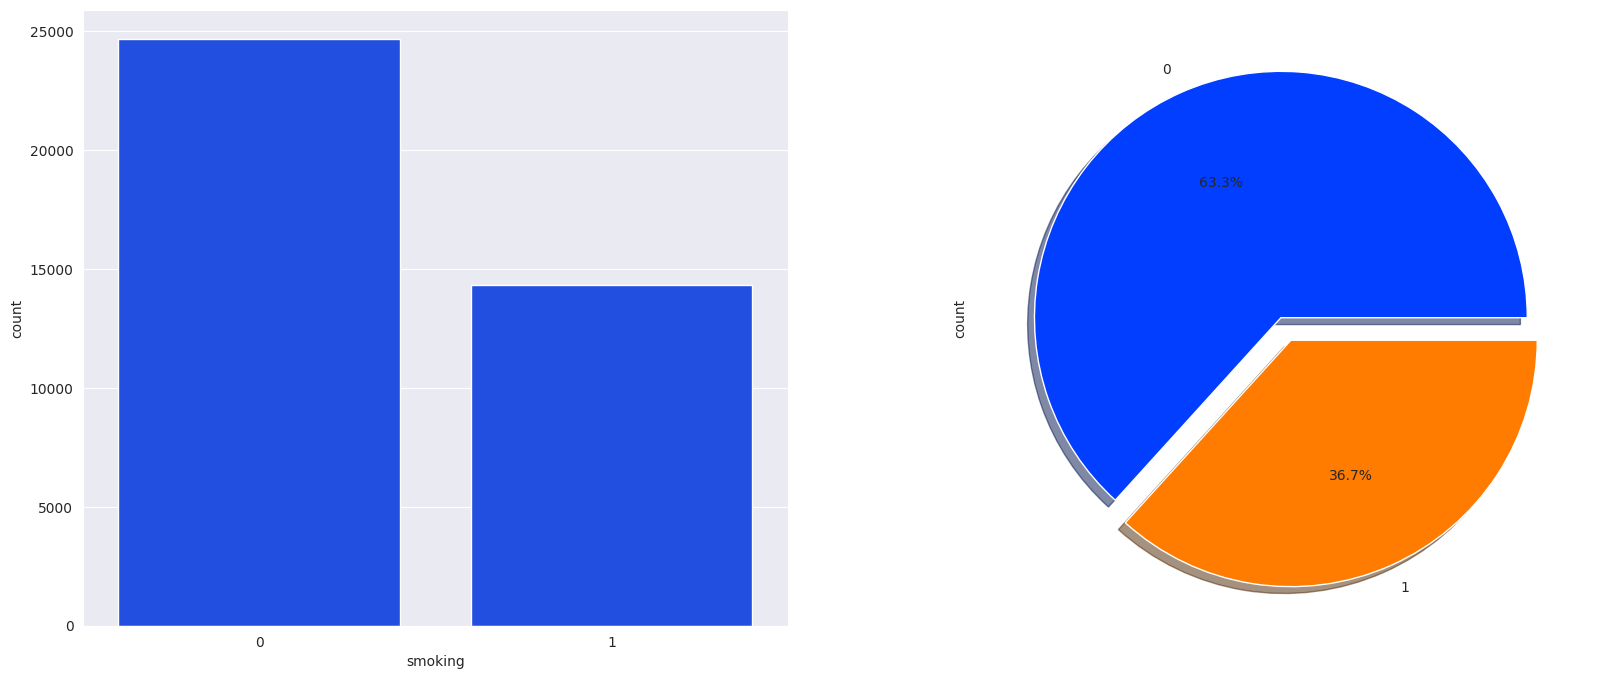

In [ ]:
# 흡연 여부(smoking)의 빈도수를 막대그래프로 시각화
# 흡연 여부의 비율을 파이 차트로 시각화

fig, ax = plt.subplots(1, 2, figsize=(20, 8))

sns.countplot(data=train_df, x="smoking", ax=ax[0])
train_df["smoking"].value_counts().plot.pie(ax=ax[1], shadow=True, explode=[0, 0.1], autopct="%1.1f%%")

plt.show()

> 나이

<Axes: xlabel='age', ylabel='count'>

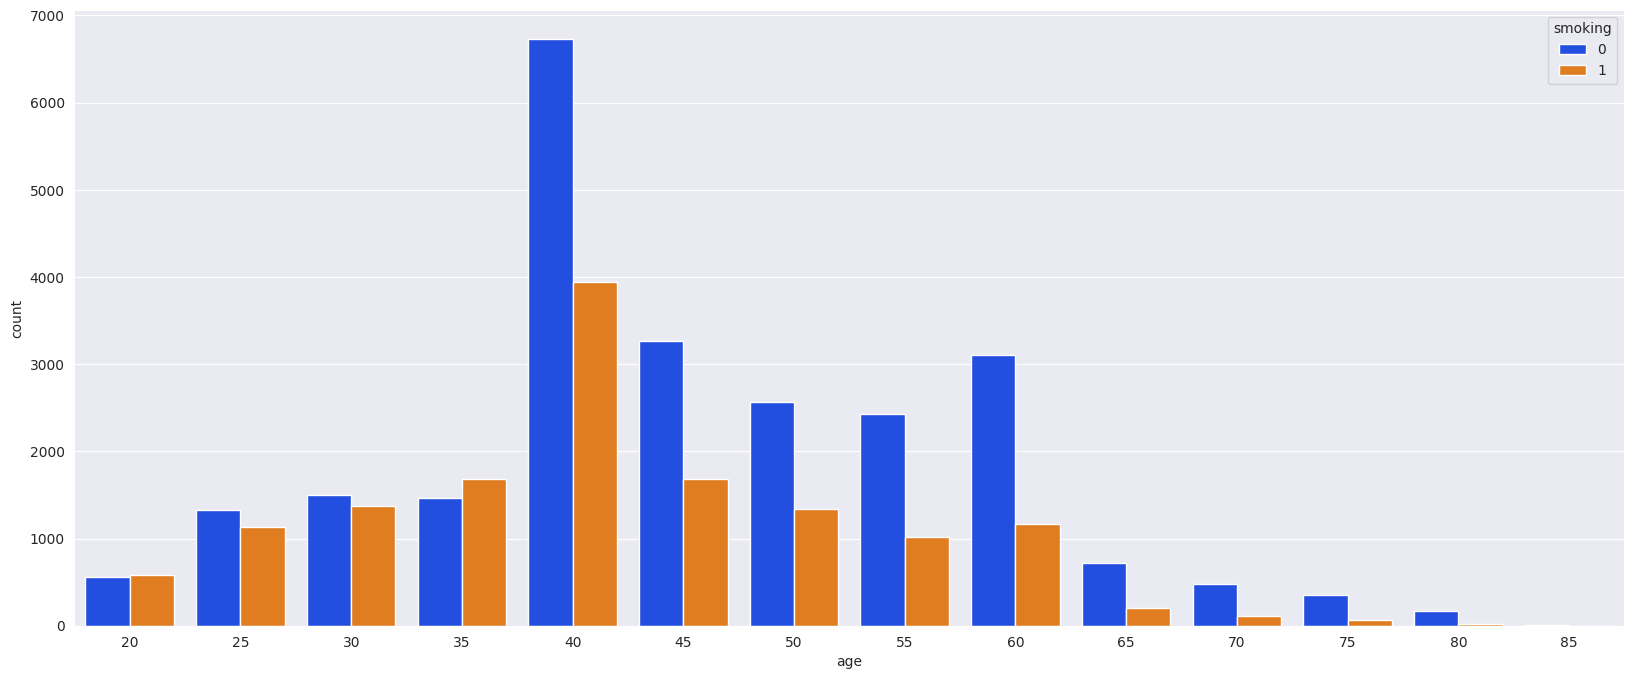

In [ ]:
plt.figure(figsize = (20, 8))
sns.countplot(data = train_df, x = 'age', hue = 'smoking', palette = 'bright')

전체 데이터를 살펴보았을 때, 40대 데이터 수가 가장 많이 분포함을 알 수 있다. 특히 40대의 데이터 비중이 높아 전체 결과에 큰 영향을 미칠 가능성이 있다.

20-30대는 비흡연자와 흡연자의 수에 큰 차이가 없지만, 40대부터는 흡연자에 비해 비흡연자의 수가 약 2배 이상 많아지는 것으로 나타났다.

이러한 변화는 개인의 건강에 대한 인식이 높아지거나, 금연 정책 강화 등 사회적 요인의 영향을 받았을 가능성이 있다.

> BMI와 나이와의 관계

In [ ]:
# BMI 계산 (출력만 하고 저장하지 않음)
bmi = train_df['weight(kg)'] / ((train_df['height(cm)'] / 100) ** 2)

print(bmi)

0        29.411765
1        35.918367
2        27.055151
3        29.384757
4        22.038567
           ...    
38979    22.038567
38980    22.892820
38981    36.332180
38982    21.484375
38983    19.591837
Length: 38984, dtype: float64


<ipython-input-63-63d90324e7d8>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=train_df, x='age', y=bmi, palette='Set2')


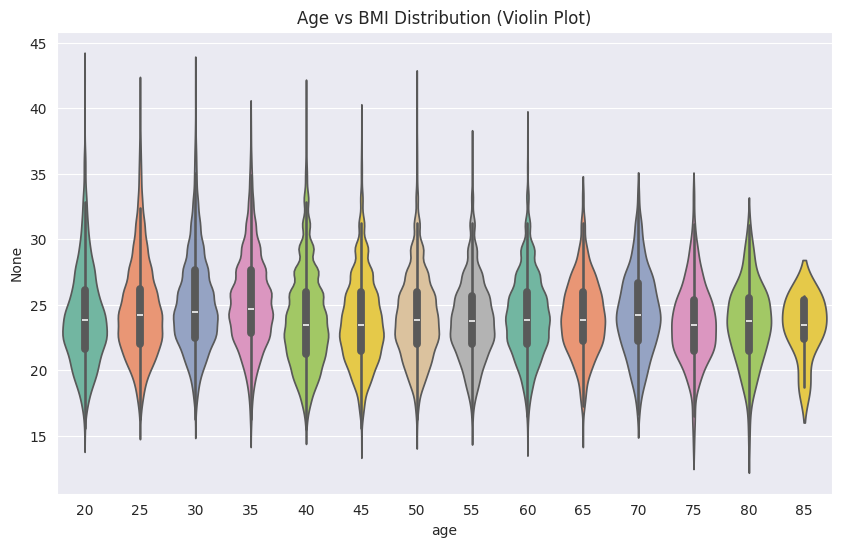

In [ ]:
# 바이올린 플롯으로 age에 따른 BMI 분포 시각화
plt.figure(figsize=(10, 6))
sns.violinplot(data=train_df, x='age', y=bmi, palette='Set2')
plt.title('Age vs BMI Distribution (Violin Plot)')
plt.show()

<ipython-input-64-a8104ba10e17>:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=train_df['age'], y=bmi, palette='coolwarm')


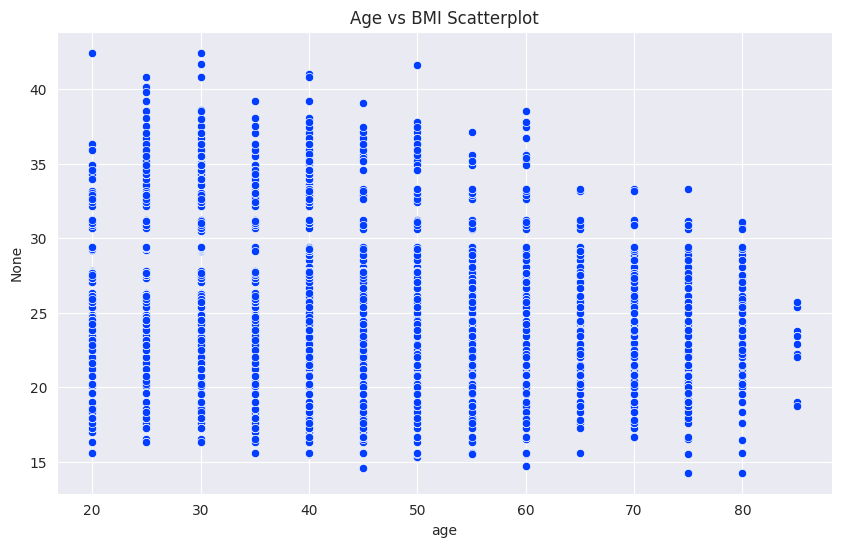

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=train_df['age'], y=bmi, palette='coolwarm')
plt.title('Age vs BMI Scatterplot')
plt.show()

< 한국 표준 BMI 분류 >

- 저체중 (Underweight): BMI < 18.5
- 정상 체중 (Normal weight): 18.5 ≤ BMI < 23
- 과체중 (Overweight): 23 ≤ BMI < 25
- 비만 (Obesity): BMI ≥ 25

< WHO 기준 BMI 분류 > (파생 변수에 쓰일 범위)
- 저체중 (Underweight): BMI < 18.5
- 정상 체중 (Normal weight): 18.5 ≤ BMI < 24.9
- 과체중 (Overweight): 25 ≤ BMI < 29.9

- 비만 (Obesity):

1단계 비만 (Class 1 Obesity): 30 ≤ BMI < 34.9

2단계 비만 (Class 2 Obesity): 35 ≤ BMI < 39.9

3단계 비만 (Class 3 Obesity): BMI ≥ 40 (극단적인 비만, 또는 "병적 비만")

> 흡연과 헤모글로빈

<Axes: xlabel='hemoglobin', ylabel='count'>

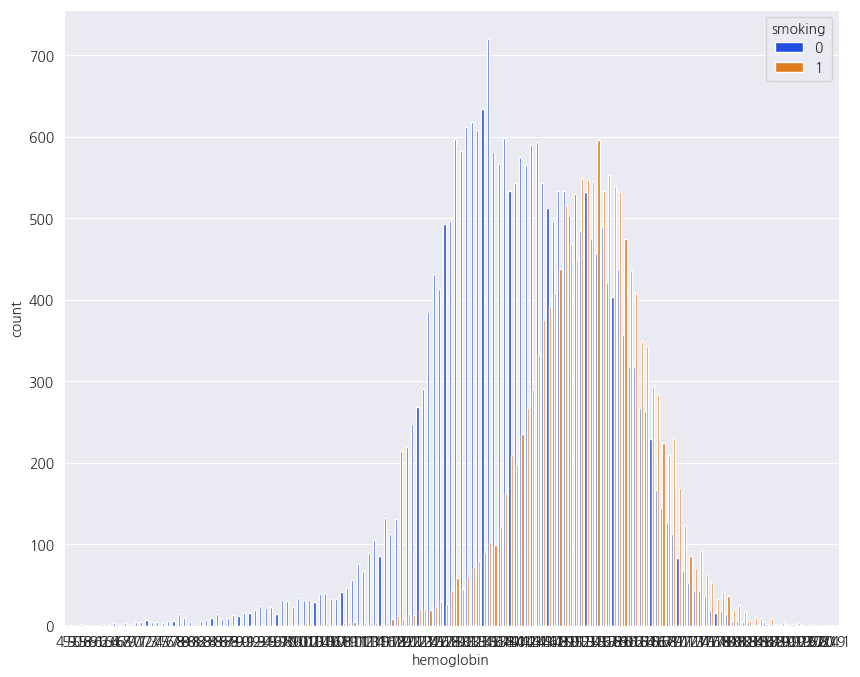

In [ ]:
plt.figure(figsize = (10, 8))
sns.countplot(data = train_df, x = 'hemoglobin', hue = 'smoking', palette = 'bright')

In [ ]:
bin_intervals = [4, 8, 12, 16, 20, 24]

<Axes: xlabel='hemoglobin_interval', ylabel='count'>

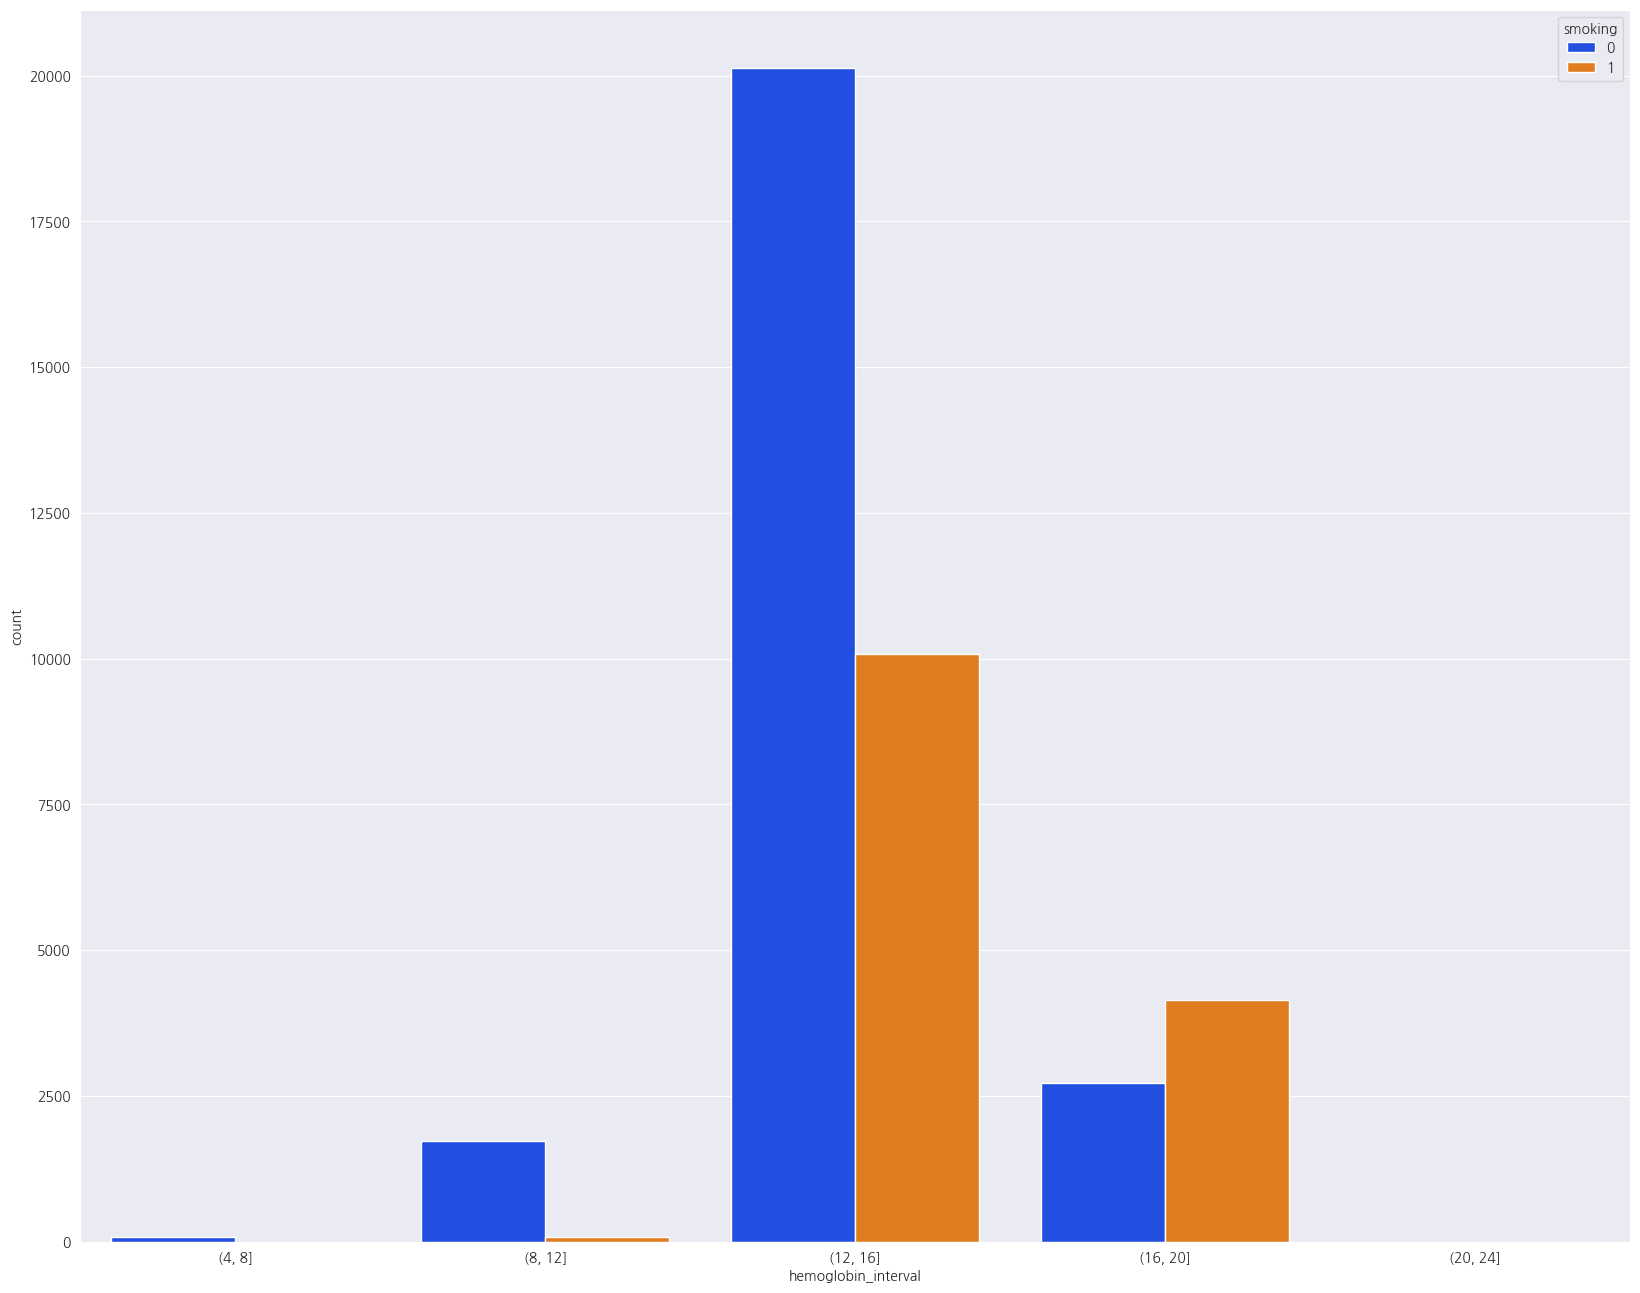

In [ ]:
train_df['hemoglobin_interval'] = pd.cut(train_df['hemoglobin'], bins=bin_intervals)
plt.figure(figsize = (20, 16))
sns.countplot(data = train_df, x = 'hemoglobin_interval', hue = 'smoking', palette = 'bright')

- 헤모글로빈 수치가 8~12: 비흡연자 > 흡연자

- 헤모글로빈 수치가 12-16: 비흡연자 > 흡연자

- **헤모글로빈 수치가 16-20: 비흡연자 < 흡연자**

-> 헤모글로빈 수치가 높아질수록 흡연자/비흡연자 값이 증가함.

-> 이는 흡연이 혈액 내 산소 수치를 감소시키기 때문으로 판단됨. 담배 연기 속 **일산화탄소(CO)**가 헤모글로빈과 결합하여 산소 운반 능력을 떨어뜨리고, 이를 보상하기 위해 **조혈작용이 활발**해짐.

>조혈작용은 골수에서 이루어지는 혈액 세포의 생성 과정. 이 과정에서 적혈구, 백혈구, 혈소판 등 혈액 세포들이 생성되며, 주로 골수에서 발생

- 따라서 헤모글로빈 수치가 높을수록 흡연자일 가능성이 높다는 결과는 흡연으로 인한 혈액학적 변화와 관련이 있을 수 있음.

---

> 흡연과 혈청 크레아티닌

<Axes: xlabel='serum creatinine', ylabel='count'>

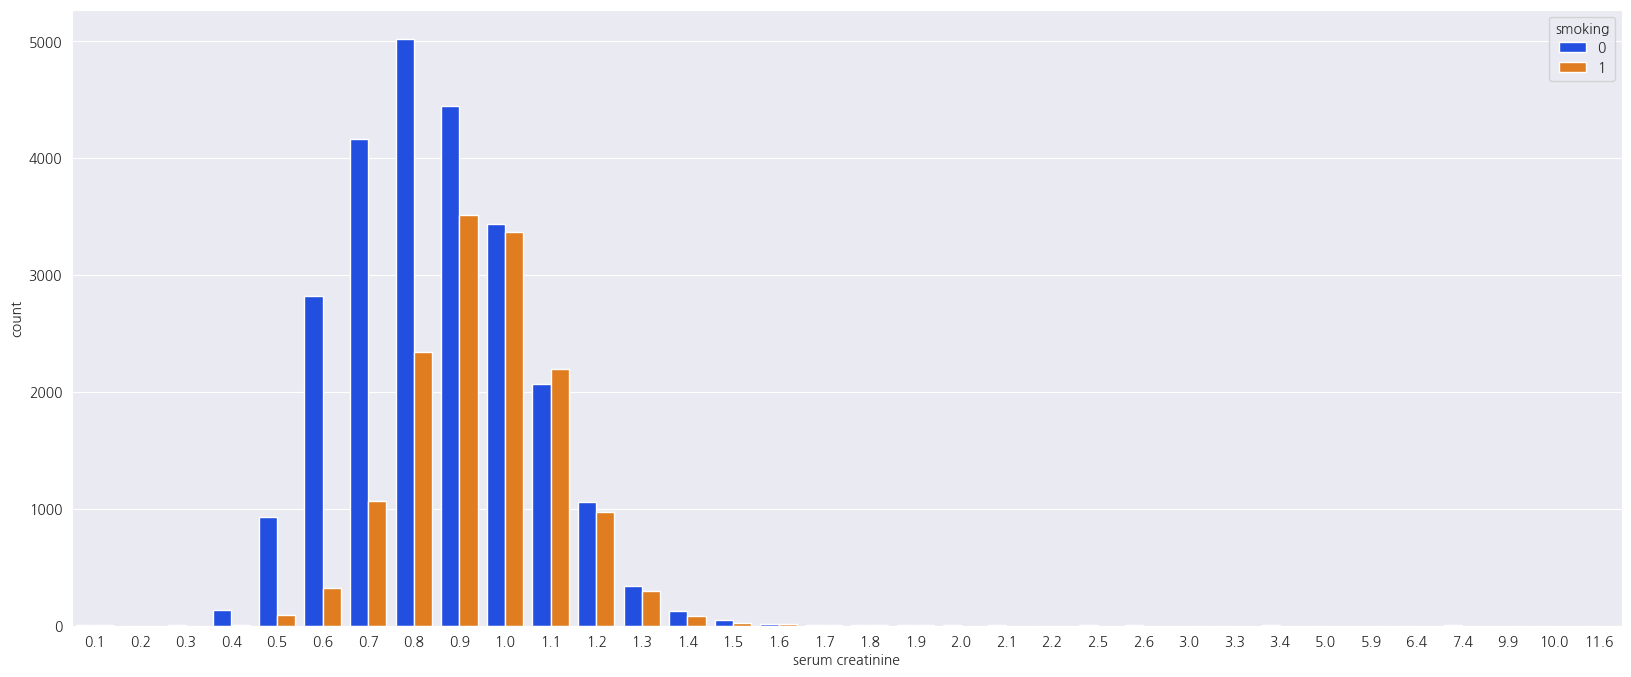

In [ ]:
plt.figure(figsize = (20, 8))
sns.countplot(data = train_df, x = 'serum creatinine', hue = 'smoking', palette = 'bright')

- 비흡연자의 크레아티닌 수치는 0.7~1.0 mg/dL에서 집중되며, 특히 0.8 mg/dL 부근에서 가장 많이 분포하는 경향을 보인다.
- 반면, 1.1 mg/dL 이상에서는 흡연자의 비중이 비흡연자보다 높아지는 것으로 나타났다.
- 비흡연자와 비교했을 때, 전체적으로 **흡연자의 크레아티닌 수치가 더 오른쪽으로** 치우쳐 있음.

이는 흡연이 **신장 혈류 감소와 산화 스트레스 증가를 유발**하여 신장 기능에 부담을 주고, 결과적으로 크레아티닌 수치를 높일 가능성이 있다는 의미로 해석될 수 있다.

> 크레아티닌은 근육 대사 과정에서 생성되는 노폐물로, 신장을 통해 배출된다. 크레아티닌 수치가 높다는 것은 신장 기능이 저하되어 노폐물 배출이 원활하지 않다는 신호이다.

> 지금까지의 EDA를 진행한 항목에 대한 T 검정

In [ ]:
# 분석할 변수 리스트
features = ["age", "height(cm)", "weight(kg)", "waist(cm)", "hemoglobin", "serum creatinine"]

# 흡연 그룹(1)과 비흡연 그룹(0) 분리
smoker = train_df[train_df["smoking"] == 1]
non_smoker = train_df[train_df["smoking"] == 0]

# T-검정 수행 및 결과 출력
t_test_results = {}
for feature in features:
    t_stat, p_value = stats.ttest_ind(smoker[feature].dropna(), non_smoker[feature].dropna(), equal_var=False)
    t_test_results[feature] = {"T-statistic": t_stat, "P-value": p_value}

# 결과 데이터프레임으로 변환 후 출력
t_test_df = pd.DataFrame.from_dict(t_test_results, orient="index")
print(t_test_df)

# 유의수준 0.05 기준으로 해석
significant_features = t_test_df[t_test_df["P-value"] < 0.05]
print("\n통계적으로 유의한 변수들:")
print(significant_features)

                  T-statistic        P-value
age                -33.898655  1.916822e-247
height(cm)          91.868629   0.000000e+00
weight(kg)          62.383340   0.000000e+00
waist(cm)           45.928380   0.000000e+00
hemoglobin          94.406131   0.000000e+00
serum creatinine    45.409625   0.000000e+00

통계적으로 유의한 변수들:
                  T-statistic        P-value
age                -33.898655  1.916822e-247
height(cm)          91.868629   0.000000e+00
weight(kg)          62.383340   0.000000e+00
waist(cm)           45.928380   0.000000e+00
hemoglobin          94.406131   0.000000e+00
serum creatinine    45.409625   0.000000e+00


"age", "height(cm)", "weight(kg)", "waist(cm)", "hemoglobin", "serum creatinine"는 모두 통계적으로 유의한 변수이다.

> 흡연과 요단백

<Axes: xlabel='Urine protein', ylabel='count'>

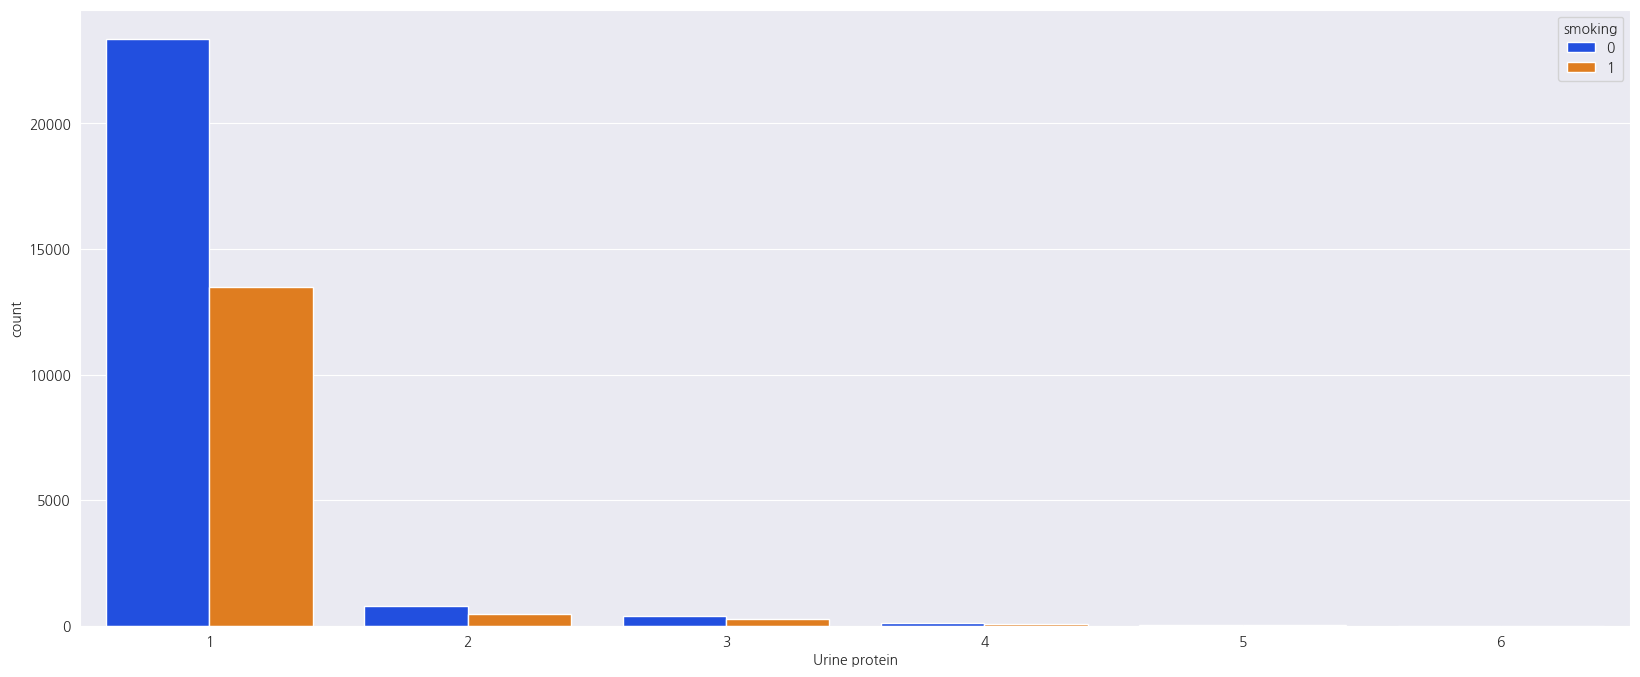

In [ ]:
plt.figure(figsize = (20, 8))
sns.countplot(data = train_df, x = 'Urine protein', hue = 'smoking', palette = 'bright')

- 요단백 수치가 1인 경우가 가장 많음
>요단백 1(정상 또는 약간 증가) 구간에서 막대 그래프가 가장 높고, 대부분의 데이터가 이 구간에 집중되어 있다.
이때 비흡연자(파란색)가 흡연자(주황색)보다 더 많이 분포하는 경향을 보인다.

- 요단백 수치가 증가할수록 흡연자와 비흡연자의 차이가 감소
>요단백 수치가 2 이상으로 증가하면서 막대 그래프가 급격히 감소하고, 3, 4 이상 구간에서는 데이터가 거의 없는 경향을 보인다.
특히, 3, 4 구간에서는 흡연자와 비흡연자의 차이가 거의 없어지며, 두 그룹의 비율 차이가 상대적으로 작아진다.

이는 흡연이 신장 기능에 악영향을 미쳐 단백뇨 발생 가능성을 높일 수 있음을 시사하지만, 요단백 수치가 높아질수록 흡연 여부와 관계없이 신장 기능 저하가 심화되어 두 그룹 간 차이가 감소하는 경향이 나타날 수 있다.

> 요단백과 충치의 카이제곱검정

In [ ]:
# 카이제곱 검정 함수 정의
def chi_square_test(var):
    contingency_table = pd.crosstab(train_df[var], train_df["smoking"])  # 분할표 생성
    chi2, p, dof, expected = stats.chi2_contingency(contingency_table)  # 카이제곱 검정 수행
    print(f"▶ {var} vs smoking 카이제곱 검정 결과")
    print(f"카이제곱 통계량: {chi2:.4f}")
    print(f"p-value: {p:.4f}")
    print("-" * 30)

# Urine protein (요단백) vs Smoking
chi_square_test("Urine protein")

# Dental caries (충치) vs Smoking
chi_square_test("dental caries")

▶ Urine protein vs smoking 카이제곱 검정 결과
카이제곱 통계량: 11.0959
p-value: 0.0495
------------------------------
▶ dental caries vs smoking 카이제곱 검정 결과
카이제곱 통계량: 450.8087
p-value: 0.0000
------------------------------


< 결론 >
둘 다 p-value가 0.05이하이기에 Urine protein과 smoking, dental caries와 smoking은 유의미한 관계를 가진다.

# 가설 설정 및 검정

## ✅ 1. 신체적 요인과 흡연의 관계

- **가설 1: 흡연자는 비흡연자보다 허리둘레(waist)가 클 것이다.**

니코틴이 코르티솔(스트레스 호르몬)을 증가시켜 복부 지방 축적을 유발할 수 있음.

흡연량이 많을수록 허리둘레가 증가하며, 특히 하루 20개비 이상 흡연자는 비흡연자보다 허리둘레가 평균 3cm 이상 증가한다는 연구 결과가 있음.

따라서, 흡연자는 비흡연자보다 평균적으로 허리둘레(waist)가 더 클 가능성이 높다.

In [6]:
!pip install koreanize-matplotlib
import numpy as np
import koreanize_matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

<Figure size 1200x600 with 0 Axes>

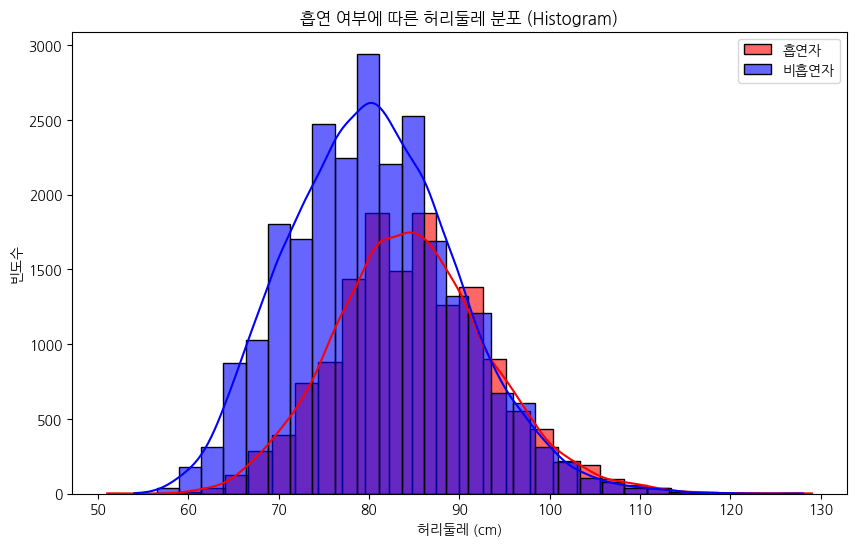

In [ ]:
plt.figure(figsize=(12, 6))

# 흡연자와 비흡연자로 데이터 나누기
smokers = train_df[train_df['smoking'] == 1]['waist(cm)']
non_smokers = train_df[train_df['smoking'] == 0]['waist(cm)']

# 히스토그램 그리기
plt.figure(figsize=(10, 6))
sns.histplot(smokers, label="흡연자", color="red", kde=True, bins=30, alpha=0.6)
sns.histplot(non_smokers, label="비흡연자", color="blue", kde=True, bins=30, alpha=0.6)

plt.title("흡연 여부에 따른 허리둘레 분포 (Histogram)")
plt.xlabel("허리둘레 (cm)")
plt.ylabel("빈도수")
plt.legend()
plt.show()

In [ ]:
# 흡연자의 허리둘레 평균
train_df[train_df['smoking'] == 1]['waist(cm)'].mean()

84.79636820785025

In [ ]:
# 비흡연자의 허리둘레 평균
train_df[train_df['smoking'] == 0]['waist(cm)'].mean()

80.47494932295467

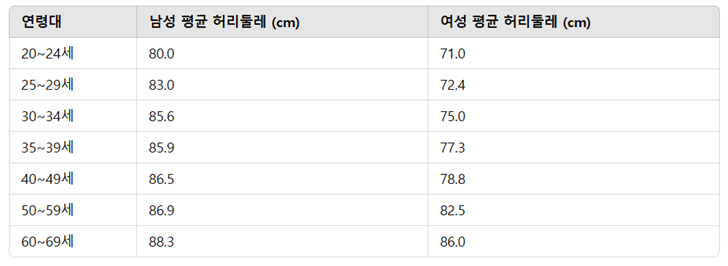

복부비만의 기준은 남성의 경우 허리둘레 90cm 이상, 여성은 85cm 이상

이는 심혈관 질환, 당뇨병 등의 만성 질환과 연관될 수 있으므로, 자신의 허리둘레를 주기적으로 측정하고 관리하는 것이 중요

- 흡연자가 비흡연자에 비해 분포의 중앙이 오른쪽으로 치우쳐 있음.

- 흡연자의 평균 허리둘레가 84.8cm로 대략 85cm에 가까워서 여성 기준으로는 복부비만이라고 할 수 있음. 남성 기준으로는 평균적으로 복부비만 전 단계라고 볼 수 있음.

- 분포만으로는 결론을 내리기 힘듦. 따라서 t-검정을 이용하여 가설 검정을 진행할 필요가 있음.

In [7]:
# 가설 2: 흡연자와 비흡연자의 평균 허리둘레 비교
smokers_waist = train_df[train_df['smoking'] == 1]['waist(cm)']  # 흡연자 허리둘레
non_smokers_waist = train_df[train_df['smoking'] == 0]['waist(cm)']  # 비흡연자 허리둘레

# t-test
t_stat_waist, p_val_waist = stats.ttest_ind(smokers_waist, non_smokers_waist)
print(f"가설 2 - 허리둘레 t-검정 결과: t-통계량 = {t_stat_waist}, p-값 = {p_val_waist}")

가설 2 - 허리둘레 t-검정 결과: t-통계량 = 45.242693690172736, p-값 = 0.0


p-값이 0.05보다 작아서, 귀무가설을 기각할 수 있음.

즉, 흡연자와 비흡연자 간의 평균 허리둘레에 유의미한 차이가 있다는 것을 알 수 있기에 **가설 1은 채택**된다.

---

< 최종 결론 >

✅ 1. 신체적 요인과 흡연의 관계
- 가설 1 채택 : 흡연자는 비흡연자보다 허리둘레(waist)가 더 크다.

## ✅ 2. 치아 건강과 흡연의 관계

- **가설 2: 흡연자는 비흡연자보다 충치(dental caries) 발생률이 높을 것이다.**

<Axes: xlabel='dental caries', ylabel='count'>

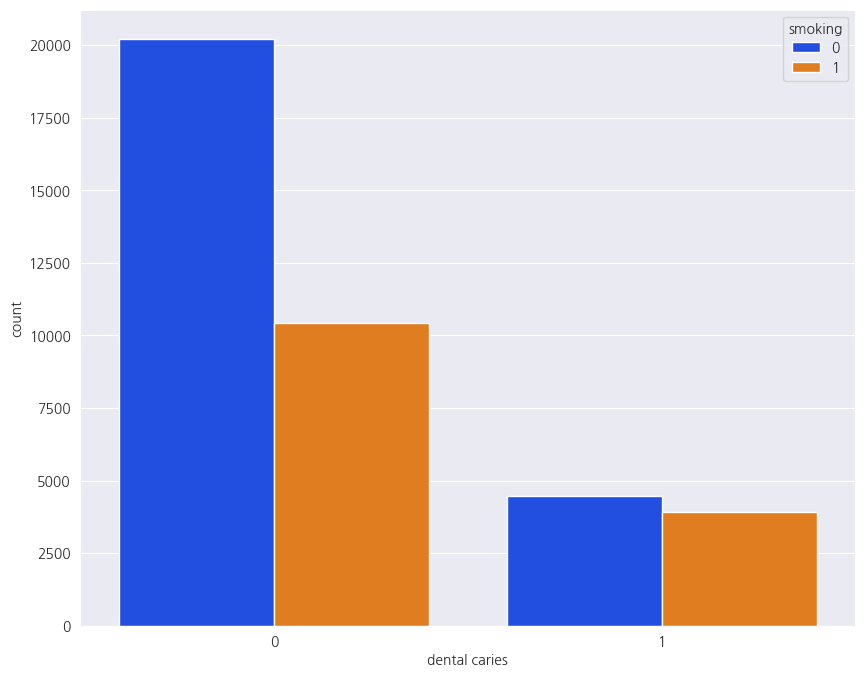

In [ ]:
plt.figure(figsize = (10, 8))
sns.countplot(data = train_df, x = 'dental caries', hue = 'smoking', palette = 'bright')

충치 x (dental caries=0): 비흡연자 > 흡연자

충치 O (dental caries=1): 비흡연자 > 흡연자

- 치아 질환이 없는 경우에서는 비흡연자와 흡연자 수 간에 상당한 차이를 보이는 반면, **치아 질환이 있는 사람들은 흡연자와 비흡연자 사이의 큰 차이가 없다.**

해당 그래프로는 흡연과 치아 칠환과의 관계성의 유의미함을 판단하기 어렵기에 통계분석을 진행하는 것이 좋을 것 같다.

In [ ]:
from scipy.stats import chi2_contingency

# 흡연자와 비흡연자별 충치 발생 여부를 구간으로 나눈 교차표 생성
contingency_table = pd.crosstab(train_df['smoking'], train_df['dental caries'])

# 카이제곱 검정
chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table)

print(f"가설 3 - 충치 발생률 카이제곱 검정 결과: 카이제곱 통계량 = {chi2_stat}, p-값 = {p_val}")

가설 3 - 충치 발생률 카이제곱 검정 결과: 카이제곱 통계량 = 450.8087198531697, p-값 = 4.809679216057804e-100


p-값이 매우 작아, 귀무가설을 기각할 수 있음.

즉, 흡연자와 비흡연자 간의 충치 발생률에 유의미한 차이가 있기에 흡연자는 비흡연자보다 충치 발생률이 더 높다는 가설을 채택할 수 있음.

< 최종 결론 >

✅ 2. 치아 건강과 흡연의 관계
- 가설 2 채택 : 흡연자는 비흡연자보다 충치(dental caries) 발생률이 높다.


## ✅ **3. 간 건강과 흡연의 관계**

### 📌 **가설 3: 흡연자는 비흡연자보다 간 수치(AST, ALT, Gtp)가 높을 것이다.**

- **근거:** 흡연은 간 기능 저하 및 지방간과 관련이 있을 수 있음.
- **검증 방법:** `AST`, `ALT`, `Gtp` 수치를 비교하여 통계적 차이 분석.

### 📖 **용어 설명**
- **AST:** (아스파테이트아미노전이효소)는 간기능을 나타내는 검사 수치로, 간 손상 여부를 확인하는 데 도움이 됩니다.
  - 간, 심장, 골격근, 적혈구 등에 많이 포함된 아미노산 대사 효소
  - 간 세포가 손상되면 세포 내의 AST가 혈액으로 유출되어 혈중 수치가 증가
  - 건강한 사람의 경우 혈액의 AST 농도는 낮음
  - 정상 수치는 40 이하로, 41~59는 경계 범위
- **ALT:** (알라닌아미노전이효소)는 간 세포 내에 있는 효소로, 간 손상이 발생하면 혈중으로 유출되어 수치가 증가합니다. 간기능 검사에서 간 손상의 정도를 확인하는 데 사용되는 검사입니다.
  - 정상 범위 정상 범위는 0-40, 41-59는 주의가 필요한 수치
- **Gtp:** 감마-GTp는 '감마글루타밀 전이효소'라고 부르고, 주로 간이나 담관(쓸개관)에 분포하지만, 췌장, 신장, 대장, 뇌 등에도 존재합니다.
  - 검사법에 따라 다르지만, 대략 5-25 IU/L 정도임.(중년 남성 관련 아티클에 나오는 내용이긴 했음. 출처: https://www.chamc.co.kr/health/e_clinic/content.asp?cc_id=10906&co_id=1180&ct_id=109#:~:text=%E2%91%A0%20%EC%A0%95%EC%83%81%EC%B9%98%EB%8A%94%20%EA%B2%80%EC%82%AC%EB%B2%95%EC%97%90,%EB%84%98%EC%A7%80%20%EC%95%8A%EB%8A%94%20%EA%B2%83%EC%9D%B4%20%EC%9D%BC%EB%B0%98%EC%A0%81%EC%9E%85%EB%8B%88%EB%8B%A )
  - 성인 남성 기준 11-63 iu/l, 여성 8-35 iu/l가 정상이다.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# 데이터 불러오기
train_df = pd.read_csv('/content/train_dataset.csv')

# age group mapping
age_mapping = {20:'20s', 25:'20s', 30:'30s', 35:'30s', 40:'40s', 45:'40s', 50:'50s', 55:'50s', 60:'60s', 65:'60s', 70:'70s', 75: '70s', 80:'80s',85:'80s' }
train_df['age group'] = train_df['age'].map(age_mapping)

In [ ]:
pd.set_option('display.max_columns', None)
# smoking/non smoking 나눠주기

df_smoker = train_df[train_df['smoking'] == 1]
df_nonsmoker = train_df[train_df['smoking'] == 0]

AST
검정통계량(t): 12.430392888085624 , p-value: 1.0432843528615722e-35
→ 귀무가설 기각 (흡연자는 비흡연자보다 간수치(AST)가 높다.)


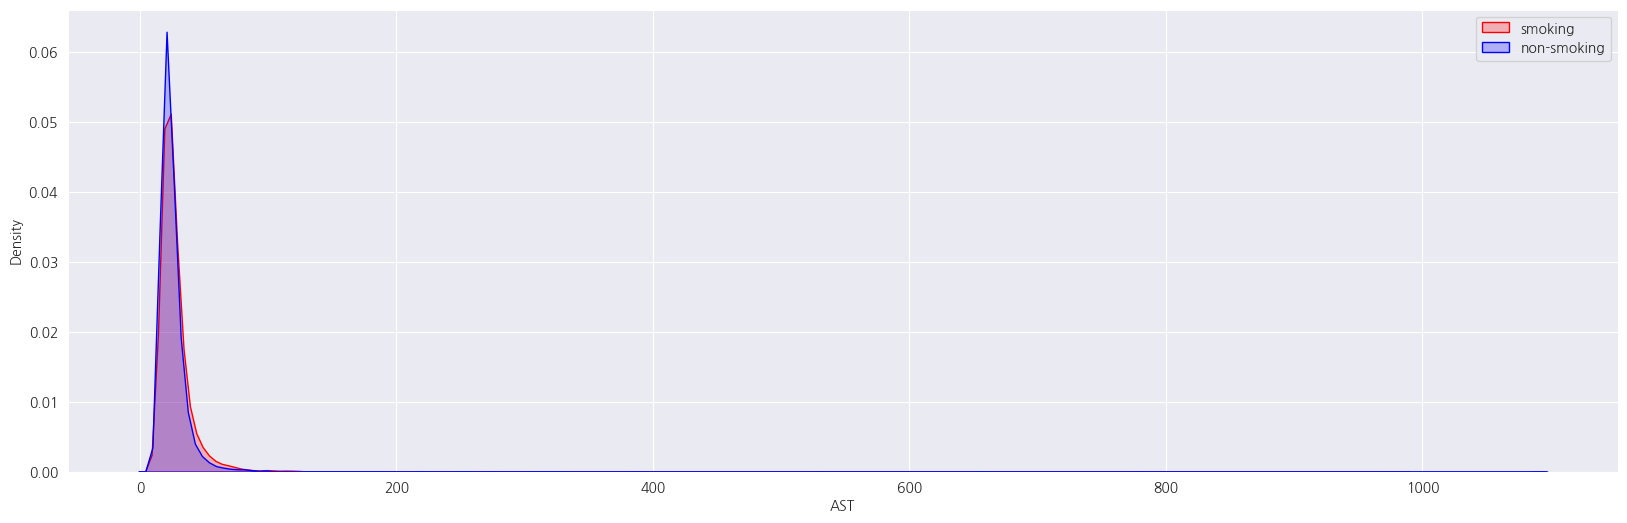

ALT
검정통계량(t): 19.5657282921896 , p-value: 3.873593285130913e-85
→ 귀무가설 기각 (흡연자는 비흡연자보다 간수치(ALT)가 높다.)


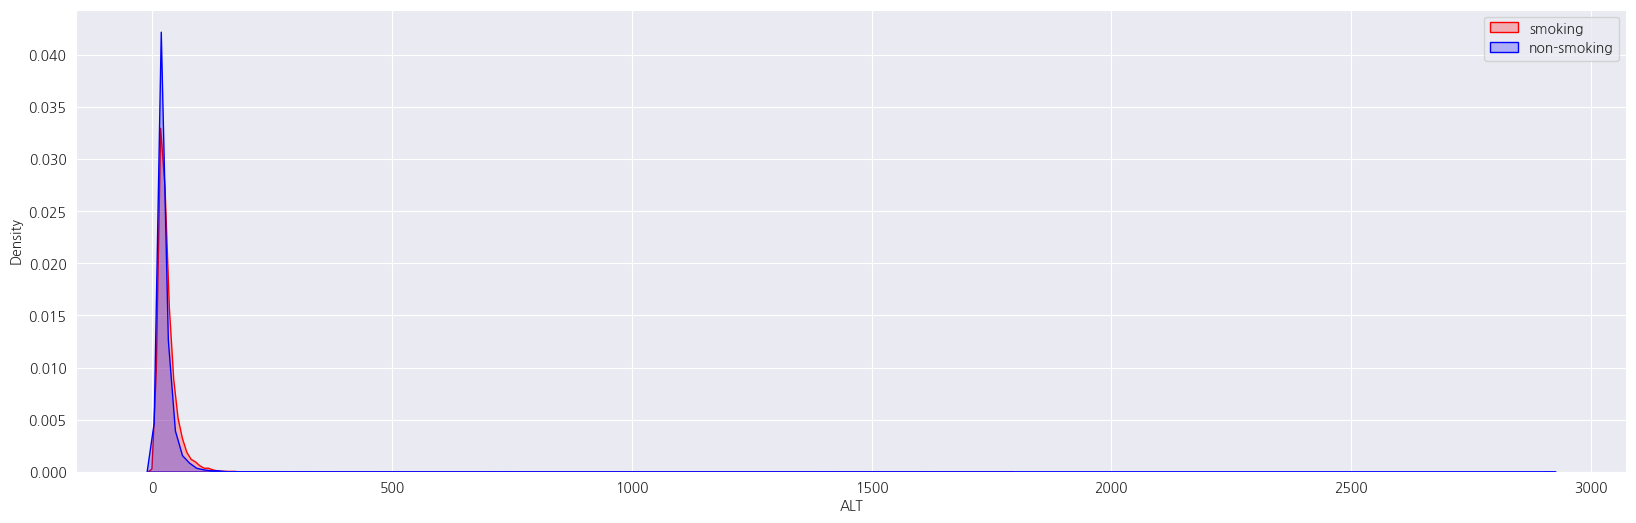

Gtp
검정통계량(t): 48.87112660707951 , p-value: 0.0
→ 귀무가설 기각 (흡연자는 비흡연자보다 간수치(Gtp)가 높다.)


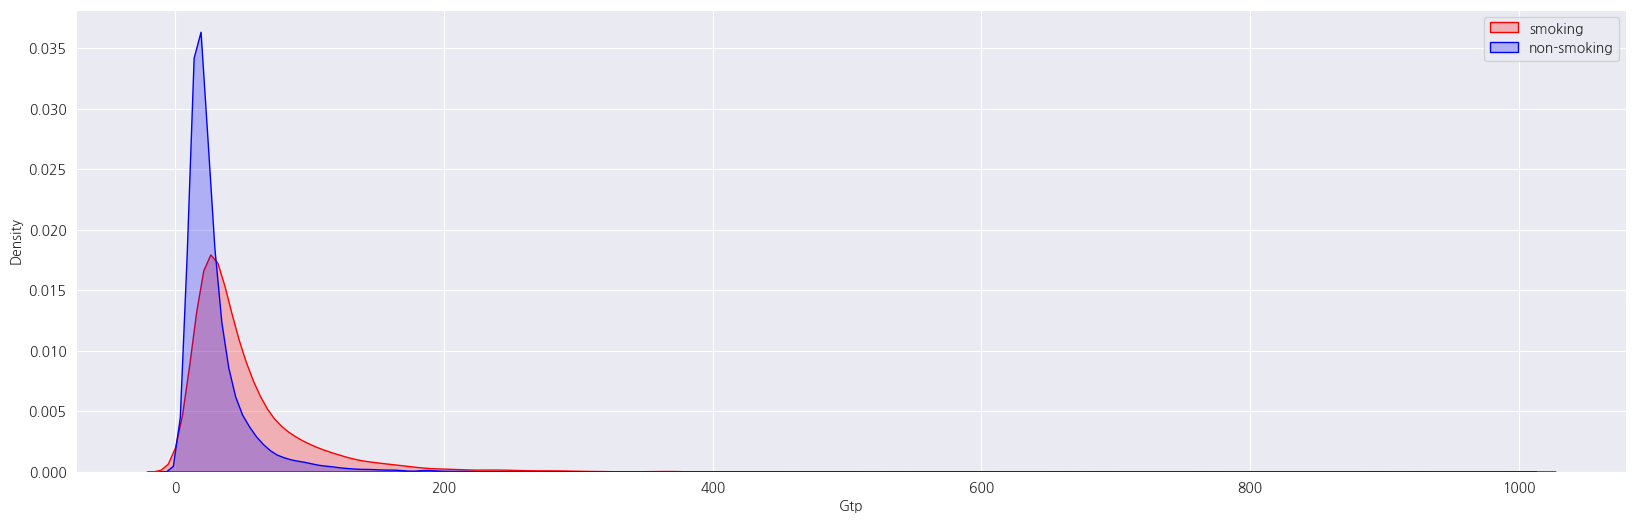

In [ ]:
import scipy.stats as st
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

# H0: 흡연자는 비흡연자보다 간수치가 높지 않다.
liver_columns = ['AST', 'ALT', 'Gtp']# 간수치 관련 컬럼들

for col in liver_columns:
  t_stat, p_val = st.ttest_ind(df_smoker[col],df_nonsmoker[col], alternative = 'greater' ) # 대립가설이 흡연자는 비흡연자보다 간수치가 '높다'이므로 단측검정. alternative를 'greater'로 설정.
  print('='*50)
  print(f'{col}')
  print("검정통계량(t):", t_stat, ", p-value:", p_val)

  alpha = 0.05
  if p_val < alpha:
      print(f"→ 귀무가설 기각 (흡연자는 비흡연자보다 간수치({col})가 높다.)")
  else:
      print(f"→ 귀무가설 채택 (흡연자는 비흡연자보다 간수치({col}가 높지 않다.) )")

  # 분포 그래프 그리기
  # Figure  생성
  # fig = go.Figure()

  # # Histogram 추가
  # fig.add_trace(go.Histogram(x=df_smoker[col]))
  # fig.add_trace(go.Histogram(x=df_nonsmoker[col]))

  # fig.update_layout(barmode='overlay')
  # fig.show()
  plt.figure(figsize = (20,6))
  sns.kdeplot(df_smoker[col], label = 'smoking', color ='red', fill = True)
  sns.kdeplot(df_nonsmoker[col], label = 'non-smoking', color ='blue', fill = True)
  plt.legend()
  plt.show()

## ✅ **4. 감각 기능(시력, 청력)과 흡연의 관계**

### 📌 **가설 4: 흡연자는 비흡연자보다 시력이 나쁠 것이다.**

- **근거:** 흡연은 망막 건강에 영향을 미칠 수 있으며, 황반변성과 관련이 있음.
- **검증 방법:** `eyesight(left)`, `eyesight(right)`의 평균 비교.

### 📌 **가설 5: 흡연자는 비흡연자보다 청력(hearing)이 나쁠 것이다.**

- **근거:** 일부 연구에서는 흡연이 청각 신경 손상과 관련될 수 있다고 보고됨.
- **검증 방법:** `hearing(left)`, `hearing(right)` 값 분석.

In [ ]:
#시력
#시력 평균 컬럼 생성
df_smoker['eyesight(mean)'] = df_smoker[['eyesight(left)', 'eyesight(right)']].mean(axis = 1)
df_nonsmoker['eyesight(mean)'] = df_nonsmoker[['eyesight(left)', 'eyesight(right)']].mean(axis = 1)

# H0: 흡연자와 비흡연자간의 시력에 차이가 있다.
eye_columns = ['eyesight(left)', 'eyesight(right)', 'eyesight(mean)'] # 시력 관련 컬럼들

for col in eye_columns:
  t_stat, p_val = st.ttest_ind(df_smoker[col],df_nonsmoker[col] ) # 단측검정으로 했을 때는 흡연자가 비흡연자보다 시력이 나쁘지 않다라고 나왔음.
  print('='*50)
  print(f'{col}')
  print("검정통계량(t):", t_stat, ", p-value:", p_val)

  alpha = 0.05
  if p_val < alpha:
      print(f"→ 귀무가설 기각 (흡연자와 비흡연자간의 시력({col})에 차이가 있다.)")
  else:
      print(f"→ 귀무가설 채택 (흡연자와 비흡연자간의 시력({col})에 차이가 없다.) )")

eyesight(left)
검정통계량(t): 11.750348828348717 , p-value: 7.959102348683755e-32
→ 귀무가설 기각 (흡연자와 비흡연자간의 시력(eyesight(left))에 차이가 있다.)
eyesight(right)
검정통계량(t): 12.77859914415625 , p-value: 2.5660486516059466e-37
→ 귀무가설 기각 (흡연자와 비흡연자간의 시력(eyesight(right))에 차이가 있다.)
eyesight(mean)
검정통계량(t): 15.024028334883601 , p-value: 7.097061560715557e-51
→ 귀무가설 기각 (흡연자와 비흡연자간의 시력(eyesight(mean))에 차이가 있다.)


단측검정(H0: 흡연자가 비흡연자보다 시력이 나쁘지 않다. alternative = 'less')을 했을 때는 귀무가설이 채택되었으나 양측 검정으로 진행하였더니 귀무가설이 기각되었음. 흡연자와 비흡연자간의 시력에 차이가 있다는 것이니까 유의미한 컬럼이다.

In [ ]:
#청력
#청력 평균 컬럼 생성
df_smoker['hearing(mean)'] = df_smoker[['hearing(left)', 'hearing(right)']].mean(axis = 1)
df_nonsmoker['hearing(mean)'] = df_nonsmoker[['hearing(left)', 'hearing(right)']].mean(axis = 1)

# H0: 흡연자는 비흡연자보다 청력이 나쁘지 않다.
hearing_columns = ['hearing(left)', 'hearing(right)', 'hearing(mean)'] # 청력 관련 컬럼들

for col in hearing_columns:
  t_stat, p_val = st.ttest_ind(df_smoker[col],df_nonsmoker[col], alternative = 'less' ) # 대립가설이 흡연자는 비흡연자보다 청력이 '나쁘다'이므로 단측검정. alternative를 'less'로 설정.
  print('='*50)
  print(f'{col}')
  print("검정통계량(t):", t_stat, ", p-value:", p_val)

  alpha = 0.05
  if p_val < alpha:
      print(f"→ 귀무가설 기각 (흡연자는 비흡연자보다 청력({col})이 나쁘다.)")
  else:
      print(f"→ 귀무가설 채택 (흡연자는 비흡연자보다 청력({col}이 나쁘지 않다.) )")

hearing(left)
검정통계량(t): -4.359919557864818 , p-value: 6.522161733844228e-06
→ 귀무가설 기각 (흡연자는 비흡연자보다 청력(hearing(left))이 나쁘다.)
hearing(right)
검정통계량(t): -3.749946026516788 , p-value: 8.856412750510692e-05
→ 귀무가설 기각 (흡연자는 비흡연자보다 청력(hearing(right))이 나쁘다.)
hearing(mean)
검정통계량(t): -4.6519381793907915 , p-value: 1.6495419494889314e-06
→ 귀무가설 기각 (흡연자는 비흡연자보다 청력(hearing(mean))이 나쁘다.)


## ✅ **5. 나이와 흡연의 관계**

### 📌 **가설 6: 연령대가 증가할수록 흡연율이 높아질 것이다.**

- **근거:** 과거 흡연율이 높았기에 특정 연령대(예: 40~50대) 이상의 흡연율이 높을 가능성이 있음.
- **검증 방법:** `age`를 기준으로 `smoking` 비율 비교.

In [ ]:
train_df['age'].unique()

array([35, 20, 45, 60, 40, 50, 75, 55, 25, 30, 70, 65, 80, 85])

In [ ]:
import plotly.express as px

ages = ['20s', '30s','40s', '50s', '60s', '70s', '80s']

# age group별로 smoking(흡연 여부) 값의 개수 계산
age_smoking_counts = train_df.groupby(["age group", "smoking"]).size().reset_index(name="count")

# 전체 연령대별 총 인원 수 계산
total_counts = train_df.groupby("age group")["smoking"].count().reset_index(name="total")

# 흡연자 비율(흡연자 / 전체) 계산
smoking_ratio = age_smoking_counts[age_smoking_counts["smoking"] == 1].merge(total_counts, on="age group")
smoking_ratio["ratio"] = smoking_ratio["count"] / smoking_ratio["total"]

# Stacked Bar Plot 생성
fig = px.bar(age_smoking_counts, x="age group", y="count", color="smoking",
             title="Age Group별 흡연 여부 분포",
             labels={"count": "인원 수", "age group": "연령대", "smoking": "흡연 여부"},
             barmode="stack")
for i, row in smoking_ratio.iterrows():
    fig.add_annotation(x=row["age group"], y=row["total"], text=f"{row['ratio']:.2%}",
                       showarrow=False, font=dict(size=12, color="black"))

# 그래프 표시
fig.show()

데이터에서 40대의 비율이 많기는 하나 나이가 많아진다고 흡연 비율이 높아지진 않음. 오히려 30대의 흡연 비율이 가장 높음.

따라서 '연령대가 증가할수록 흡연율이 높아질 것이다.'라는 **가설 6을 기각**함.

## ✅ **6. 혈압, 심혈관 건강과 흡연의 관계**

### 📌 **가설 7: 흡연자는 비흡연자보다 평균 혈압(systolic, relaxation)이 높을 것이다.**

- **근거:** 흡연은 혈관을 수축시키고, 혈압을 증가시키는 요인으로 작용.
- **검증 방법:** `systolic`, `relaxation` 값의 평균 비교 및 회귀 분석.

### 📌 **가설 8: 흡연자와 비흡연자의 콜레스테롤(Cholesterol, HDL, LDL) 수치가 다를 것이다.**

- **근거:** 흡연은 LDL(나쁜 콜레스테롤)을 증가시키고, HDL(좋은 콜레스테롤)을 감소시킬 가능성이 있음.
- **검증 방법:** `HDL`, `LDL`, `Cholesterol` 수치를 기준으로 `smoking` 그룹 간 평균 비교.

---


## ✅ **7. 당뇨 및 대사 건강과 흡연의 관계**

### 📌 **가설 9: 흡연자는 비흡연자보다 공복 혈당(fasting blood sugar)이 높을 것이다.**

- **근거:** 흡연은 인슐린 저항성을 증가시키고, 당뇨병 발병 위험을 높일 가능성이 있음.
- **검증 방법:** `fasting blood sugar` 수치의 평균 비교.

### 📌 **가설 10: 흡연자는 비흡연자보다 중성지방(triglyceride) 수치가 더 높을 것이다.**

- **근거:** 흡연은 지방 대사에 영향을 주고, 중성지방 수치를 증가시킬 가능성이 있음.
- **검증 방법:** `triglyceride` 수치의 평균 비교.

In [ ]:
from IPython.display import Markdown #폰트 볼드체
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm

In [ ]:
# 데이터 불러오기
train_df = pd.read_csv('/content/train_dataset.csv')

In [ ]:
# 양측 검정
# 비교할 변수 리스트
variables = ['systolic', 'relaxation', "Cholesterol", "HDL", "LDL", "fasting blood sugar", "triglyceride"]

# 흡연자 vs 비흡연자 평균 비교
smoking_stats = train_df.groupby("smoking")[variables].mean()


# 독립표본 t-검정 (흡연자 vs 비흡연자)
t_test_results = []
for var in variables:
    t_stat, p_value = stats.ttest_ind(
        train_df[train_df["smoking"] == 1][var], train_df[train_df["smoking"] == 0][var], equal_var=False
    )
    t_test_results.append([var, t_stat, p_value, p_value < 0.05])

# t-검정 결과를 데이터프레임으로 저장
t_test = pd.DataFrame(t_test_results, columns=["Variable", "t-statistic", "p-value", "Significant (p < 0.05)"])

print('\n==smoking_stats==\n')
print(smoking_stats)
print('\n==T test==\n')  # 줄바꿈 \n
print(t_test)


==smoking_stats==

           systolic  relaxation  Cholesterol        HDL         LDL  \
smoking                                                               
0        120.746169   75.231574   197.644977  59.292346  116.441539   
1        122.732295   77.308563   195.571658  53.849071  112.738511   

         fasting blood sugar  triglyceride  
smoking                                     
0                  97.770980    113.015325  
1                 102.049169    150.409624  

==T test==

              Variable  t-statistic        p-value  Significant (p < 0.05)
0             systolic    14.123337   3.748850e-45                    True
1           relaxation    20.719376   1.039728e-94                    True
2          Cholesterol    -5.421628   5.951755e-08                    True
3                  HDL   -36.738946  2.061550e-289                    True
4                  LDL    -8.030779   1.006628e-15                    True
5  fasting blood sugar    18.274796   4.345370e-74  

=> 흡연자와 비흡연자간의 혈압, 콜레스테롤 수치, 공복혈당, 중성지방 수치에 차이가 있다.

In [ ]:
# 단측 검정
# 비교할 변수 리스트
variables = ['systolic', 'relaxation', "Cholesterol", "HDL", "LDL", "fasting blood sugar", "triglyceride"]

# 흡연자 vs 비흡연자 평균 비교
smoking_stats = train_df.groupby("smoking")[variables].mean()


# 독립표본 t-검정 (흡연자 vs 비흡연자)
t_test_results = []
for var in variables:
    t_stat, p_value = stats.ttest_ind(
        train_df[train_df["smoking"] == 1][var], train_df[train_df["smoking"] == 0][var], alternative = 'greater'
    )
    t_test_results.append([var, t_stat, p_value, p_value < 0.05])

# t-검정 결과를 데이터프레임으로 저장
t_test = pd.DataFrame(t_test_results, columns=["Variable", "t-statistic", "p-value", "Significant (p < 0.05)"])

print('\n==smoking_stats==\n')
print(smoking_stats)
print('\n==T test==\n')  # 줄바꿈 \n
print(t_test)


==smoking_stats==

           systolic  relaxation  Cholesterol        HDL         LDL  \
smoking                                                               
0        120.746169   75.231574   197.644977  59.292346  116.441539   
1        122.732295   77.308563   195.571658  53.849071  112.738511   

         fasting blood sugar  triglyceride  
smoking                                     
0                  97.770980    113.015325  
1                 102.049169    150.409624  

==T test==

              Variable  t-statistic       p-value  Significant (p < 0.05)
0             systolic    13.889742  4.648080e-44                    True
1           relaxation    20.577936  6.813223e-94                    True
2          Cholesterol    -5.430259  1.000000e+00                   False
3                  HDL   -36.027310  1.000000e+00                   False
4                  LDL    -8.225997  1.000000e+00                   False
5  fasting blood sugar    19.824978  2.436795e-87         

=> 흡연자가 비흡연자보다 혈압, 공복혈당, 중성지방 수치가 높다.

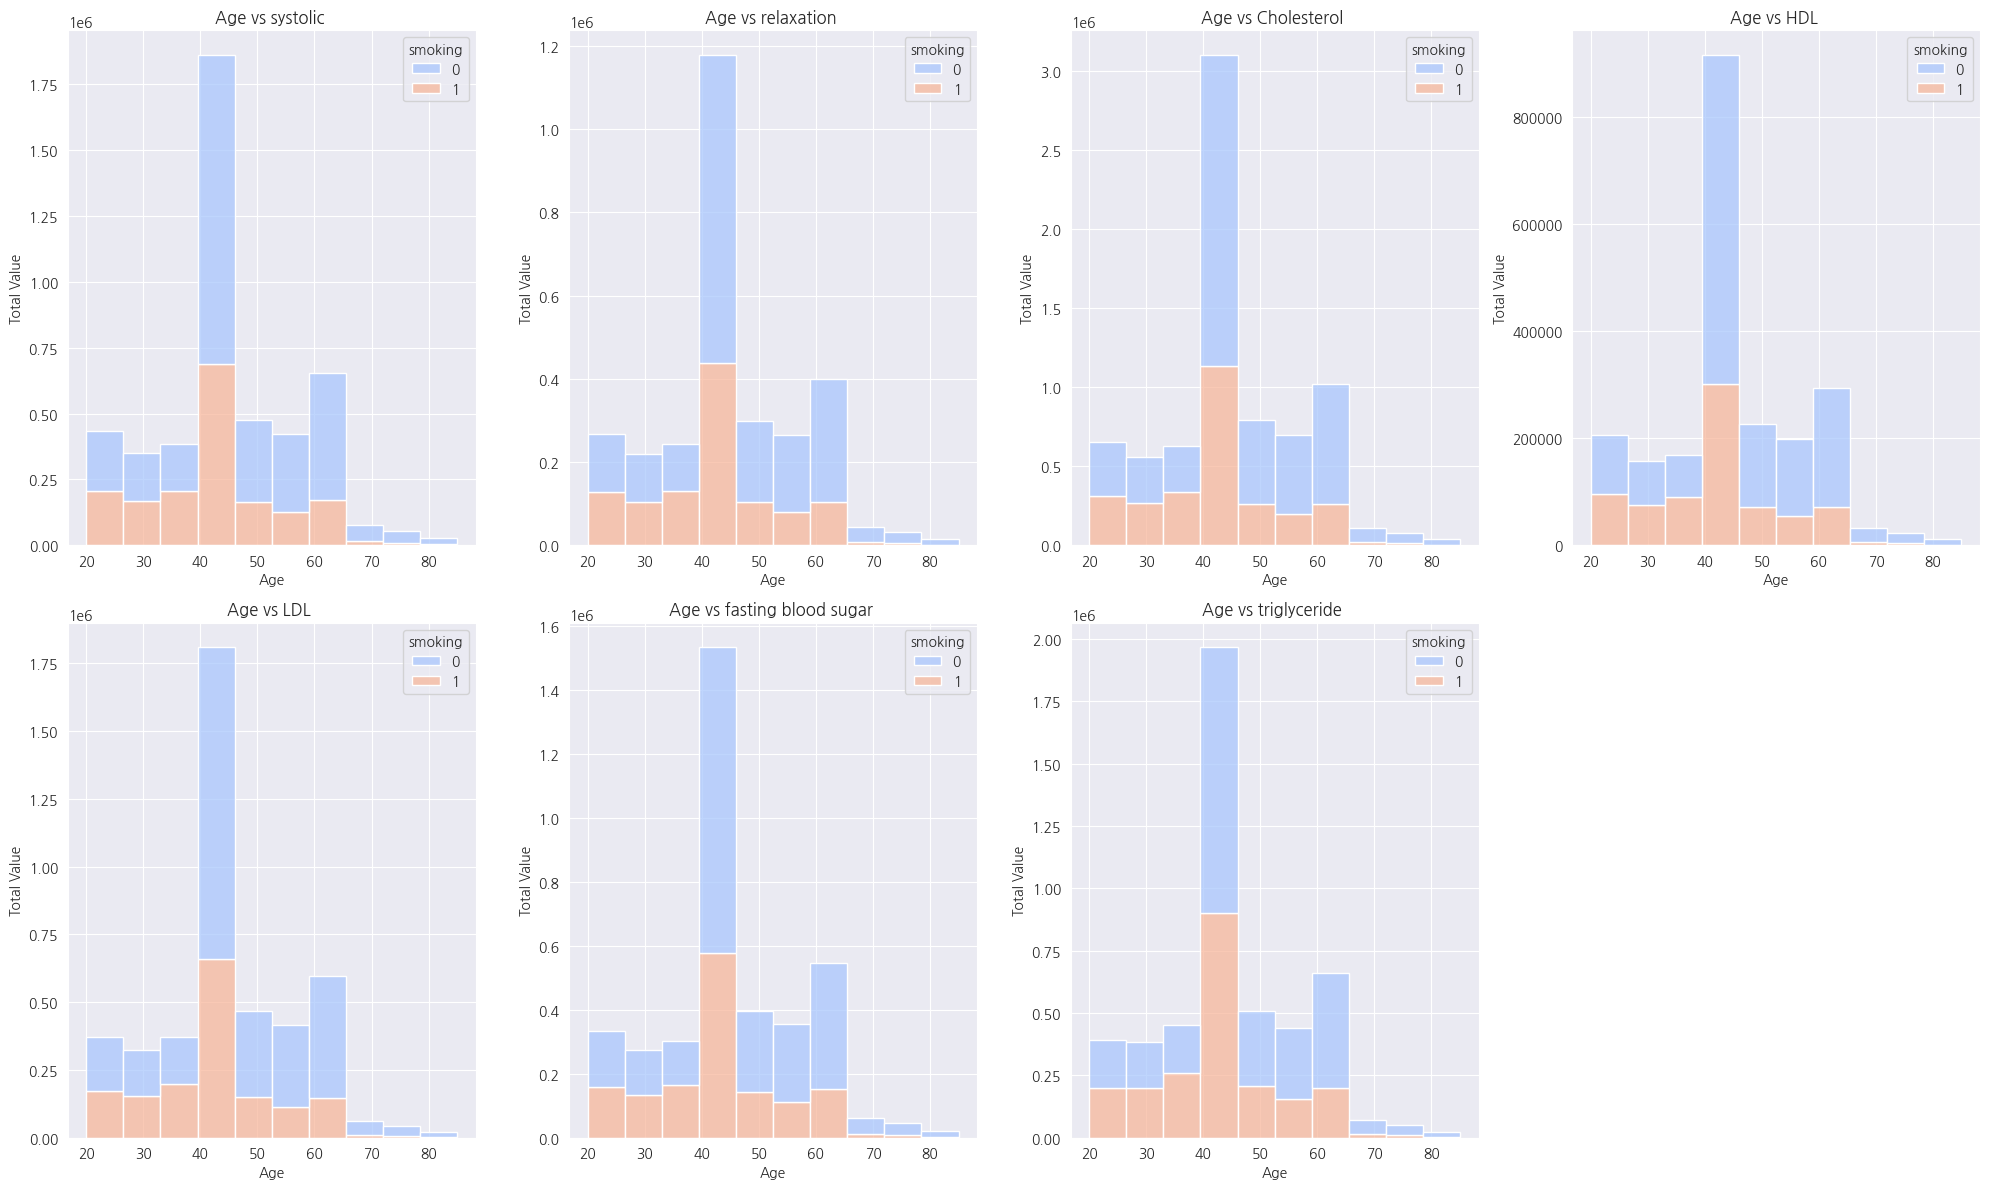

In [ ]:
# 시각화할 변수 재설정
columns = ["systolic", "relaxation", "Cholesterol", "HDL", "LDL", "fasting blood sugar", "triglyceride"]

# 서브플롯 행과 열 개수 설정
n_cols = 4  # 한 행에 4개의 그래프
n_rows = int(np.ceil(len(columns) / n_cols))  # 필요한 행 개수 자동 계산

# 서브플롯 생성
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 12))
axes = axes.flatten()  # 2D 배열을 1D 리스트로 변환

for i, col in enumerate(columns):
    sns.histplot(
        data=train_df, x="age", hue="smoking", weights=train_df[col], multiple="stack", palette="coolwarm", bins=10, ax=axes[i]
    )
    axes[i].set_title(f"Age vs {col} ")
    axes[i].set_xlabel("Age")
    axes[i].set_ylabel("Total Value")

# 불필요한 빈 플롯 숨기기
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# 다중공선성 확인

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(df):
    vif = pd.DataFrame()
    vif["Feature"] = df.columns
    vif["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    return vif.sort_values(by="VIF", ascending=False)

X_train = train_df.drop(columns=['smoking'])
vif_df = calculate_vif(X_train)
print(vif_df)

                Feature         VIF
1            height(cm)  298.457662
3             waist(cm)  286.810830
8              systolic  199.504967
9            relaxation  153.531042
15           hemoglobin  146.805215
2            weight(kg)  132.505680
11          Cholesterol   90.300810
6         hearing(left)   59.749528
7        hearing(right)   58.364825
13                  HDL   28.459801
10  fasting blood sugar   27.634955
0                   age   23.825785
17     serum creatinine   21.295432
14                  LDL   20.914625
16        Urine protein    8.469103
12         triglyceride    7.682059
18                  AST    5.991808
5       eyesight(right)    5.962930
4        eyesight(left)    5.907951
19                  ALT    3.696186
20                  Gtp    2.186851
21        dental caries    1.296038


5 ~ 10 : 다중공선성 존재 가능성 있음. 검토 필요

10 이상 : 다중공선성 높음. 변수 제거 또는 차원 축소.



---

대부분이 10 이상으로 다중공선성이 너무 높음.

하지만 부스팅 모델은 다중공선성의 영향을 거의 받지 않기에 고려하지 않아도 됨.

# HistGradientBoosting, CatBoost

## 모델링

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 7.5 MB/s eta 0:00:00


===== CatBoostClassifier =====
정확도: 0.7652
ROC-AUC: 0.8472
분류 보고서:
               precision    recall  f1-score   support

           0       0.82      0.81      0.81      4933
           1       0.68      0.69      0.68      2864

    accuracy                           0.77      7797
   macro avg       0.75      0.75      0.75      7797
weighted avg       0.77      0.77      0.77      7797



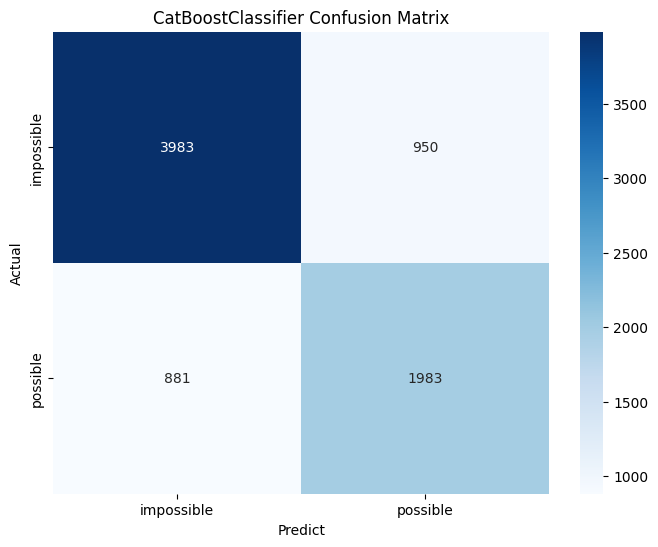



===== HistGradientBoostingClassifier =====
정확도: 0.7561
ROC-AUC: 0.8383
분류 보고서:
               precision    recall  f1-score   support

           0       0.81      0.80      0.81      4933
           1       0.66      0.68      0.67      2864

    accuracy                           0.76      7797
   macro avg       0.74      0.74      0.74      7797
weighted avg       0.76      0.76      0.76      7797



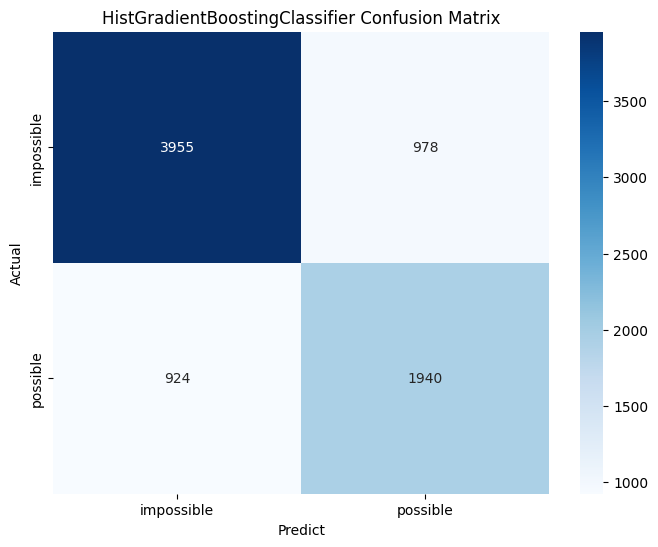

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# 타겟 변수 분리
y = train_df['smoking']
X = train_df.drop(columns=['smoking'])

# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 모델 리스트
models = {
    'CatBoostClassifier': CatBoostClassifier(verbose=0, random_state=42),
    'HistGradientBoostingClassifier': HistGradientBoostingClassifier(max_iter=100, random_state=42)
}

# 모델 학습 및 평가
for name, model in models.items():
    print(f'===== {name} =====')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # 성능 평가
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]) if hasattr(model, 'predict_proba') else None

    print(f'정확도: {accuracy:.4f}')
    if roc_auc is not None:
        print(f'ROC-AUC: {roc_auc:.4f}')
    print('분류 보고서:\n', classification_report(y_test, y_pred))

    # 혼동 행렬 시각화
    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_test, y_pred),
                annot=True, fmt='d', cmap='Blues',
                xticklabels=['impossible', 'possible'],
                yticklabels=['impossible', 'possible'])
    plt.title(f'{name} Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predict')
    plt.show()
    print('\n')

## 성능 개선을 위한 방법 1 - 컬럼 추리기

제일 먼저 떠오른 방법은 smoking과의 상관계수가 상대적으로 높은 컬럼들만 추려서 따로 데이터프레임을 제작한 후, 모델 학습을 하는 것이다.

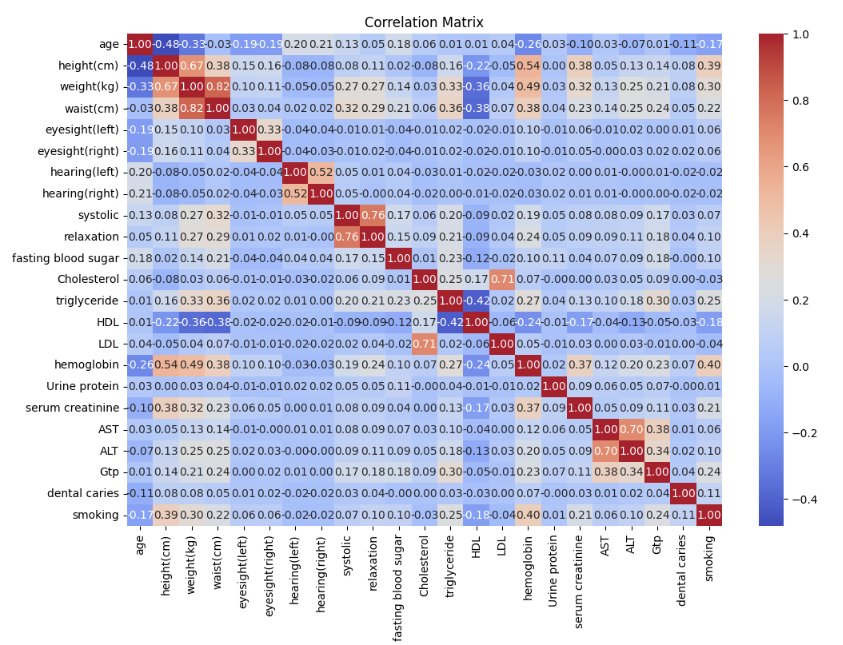

히트맵을 보면, 전체적으로 상관관계가 높지는 않다.

따라서 0.1이상인 컬럼들을 추려서 모델 학습을 진행하겠다.

===== CatBoostClassifier =====
정확도: 0.7418
ROC-AUC: 0.8242
분류 보고서:
               precision    recall  f1-score   support

           0       0.80      0.79      0.80      4933
           1       0.65      0.66      0.65      2864

    accuracy                           0.74      7797
   macro avg       0.72      0.72      0.72      7797
weighted avg       0.74      0.74      0.74      7797



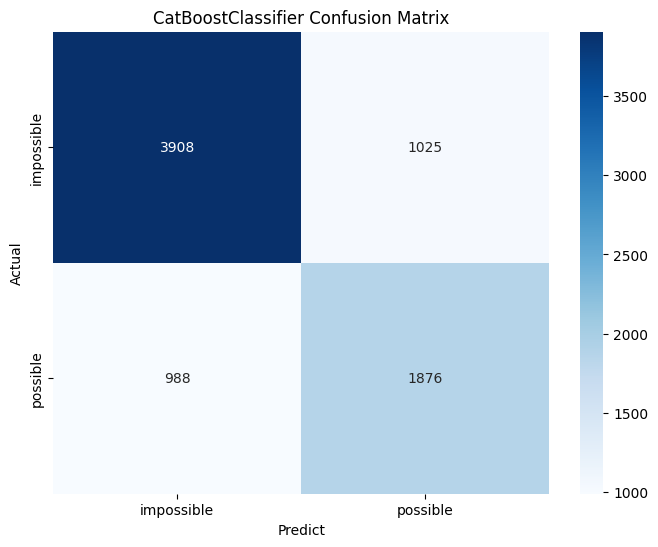



===== HistGradientBoostingClassifier =====
정확도: 0.7352
ROC-AUC: 0.8162
분류 보고서:
               precision    recall  f1-score   support

           0       0.80      0.78      0.79      4933
           1       0.63      0.66      0.65      2864

    accuracy                           0.74      7797
   macro avg       0.72      0.72      0.72      7797
weighted avg       0.74      0.74      0.74      7797



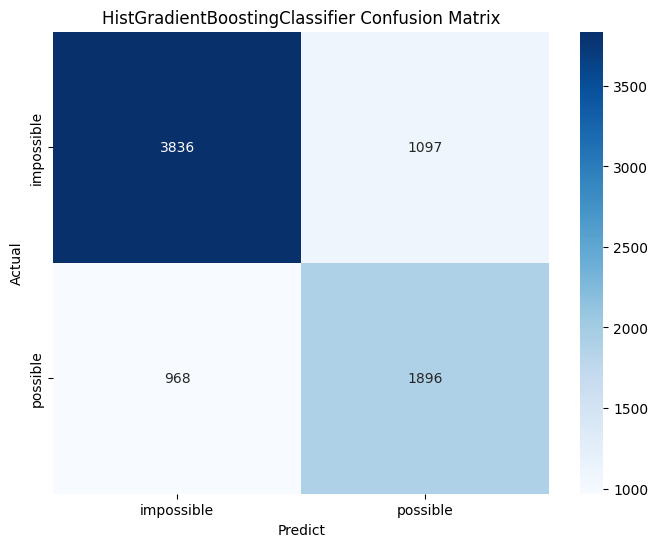

In [ ]:
# 상관계수 계산
correlations = train_df.corr()['smoking']
selected_features = correlations[correlations >= 0.1].index.tolist()
selected_features.remove('smoking')

# 타겟 변수 분리
y = train_df['smoking']
X = train_df[selected_features]

# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 모델 리스트
models = {
    'CatBoostClassifier': CatBoostClassifier(verbose=0, random_state=42),
    'HistGradientBoostingClassifier': HistGradientBoostingClassifier(max_iter=100, random_state=42)
}

# 모델 학습 및 평가
for name, model in models.items():
    print(f'===== {name} =====')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # 성능 평가
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]) if hasattr(model, 'predict_proba') else None

    print(f'정확도: {accuracy:.4f}')
    if roc_auc is not None:
        print(f'ROC-AUC: {roc_auc:.4f}')
    print('분류 보고서:\n', classification_report(y_test, y_pred))

    # 혼동 행렬 시각화
    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_test, y_pred),
                annot=True, fmt='d', cmap='Blues',
                xticklabels=['impossible', 'possible'],
                yticklabels=['impossible', 'possible'])
    plt.title(f'{name} Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predict')
    plt.show()
    print('\n')

오히려 성능 평가 결과가 전보다 안 좋은 것으로 보아 해당 방법은 맞지 않은 것 같다.

Selected Features: ['age', 'height(cm)', 'weight(kg)', 'waist(cm)', 'fasting blood sugar', 'triglyceride', 'HDL', 'AST', 'ALT', 'Gtp']
===== CatBoostClassifier =====
정확도: 0.7391
ROC-AUC: 0.8183
분류 보고서:
               precision    recall  f1-score   support

           0       0.79      0.79      0.79      4933
           1       0.65      0.64      0.64      2864

    accuracy                           0.74      7797
   macro avg       0.72      0.72      0.72      7797
weighted avg       0.74      0.74      0.74      7797



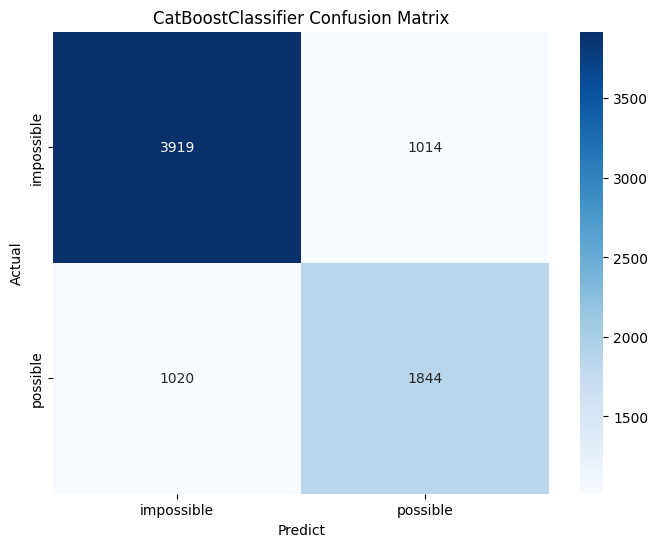



===== HistGradientBoostingClassifier =====
정확도: 0.7380
ROC-AUC: 0.8131
분류 보고서:
               precision    recall  f1-score   support

           0       0.79      0.80      0.79      4933
           1       0.64      0.64      0.64      2864

    accuracy                           0.74      7797
   macro avg       0.72      0.72      0.72      7797
weighted avg       0.74      0.74      0.74      7797



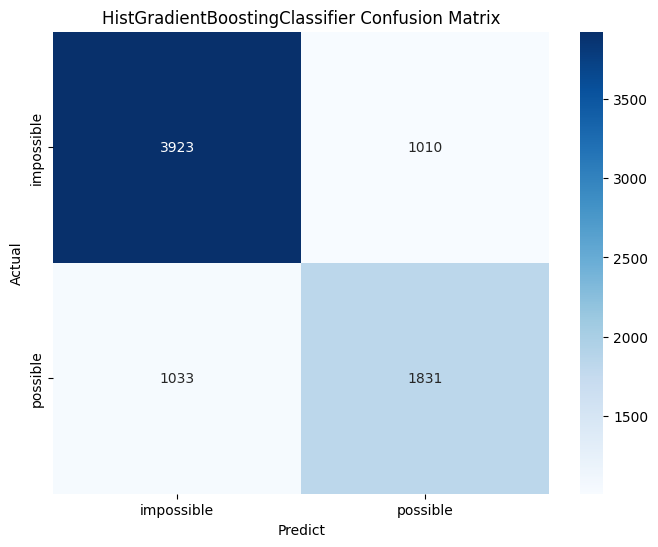

In [ ]:
from sklearn.feature_selection import SelectKBest, chi2

# 타겟 변수 분리
y = train_df['smoking']
X = train_df.drop(columns=['smoking'])

# Chi-Square Test로 Feature Selection
chi_selector = SelectKBest(score_func=chi2, k=10)  # 상위 10개 피처 선택
X_selected = chi_selector.fit_transform(X, y)
selected_features = X.columns[chi_selector.get_support()]  # 선택된 컬럼 이름 추출
print(f'Selected Features: {list(selected_features)}')

# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42, stratify=y)

# 모델 리스트
models = {
    'CatBoostClassifier': CatBoostClassifier(verbose=0, random_state=42),
    'HistGradientBoostingClassifier': HistGradientBoostingClassifier(max_iter=100, random_state=42)
}

# 모델 학습 및 평가
for name, model in models.items():
    print(f'===== {name} =====')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # 성능 평가
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]) if hasattr(model, 'predict_proba') else None

    print(f'정확도: {accuracy:.4f}')
    if roc_auc is not None:
        print(f'ROC-AUC: {roc_auc:.4f}')
    print('분류 보고서:\n', classification_report(y_test, y_pred))

    # 혼동 행렬 시각화
    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_test, y_pred),
                annot=True, fmt='d', cmap='Blues',
                xticklabels=['impossible', 'possible'],
                yticklabels=['impossible', 'possible'])
    plt.title(f'{name} Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predict')
    plt.show()
    print('\n')

상관계수로 추리는 것이 아니라 Chi-Square Test를 이용해서 새롭게 추렸는데 오히려 성능이 더 떨어짐.

컬럼을 제거하면 안 될 것 같음.

## 성능 개선을 위한 방법 2 - 하이퍼파리미터 튜닝

===== CatBoostClassifier =====
Fitting 2 folds for each of 8 candidates, totalling 16 fits


/usr/local/lib/python3.11/dist-packages/sklearn/experimental/enable_hist_gradient_boosting.py:19: UserWarning: Since version 1.0, it is not needed to import enable_hist_gradient_boosting anymore. HistGradientBoostingClassifier and HistGradientBoostingRegressor are now stable and can be normally imported from sklearn.ensemble.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


최적 하이퍼파라미터: {'learning_rate': 0.1, 'iterations': 1100, 'depth': 10}
정확도: 0.7935
ROC-AUC: 0.8747
분류 보고서:
               precision    recall  f1-score   support

           0       0.84      0.84      0.84      4933
           1       0.72      0.72      0.72      2864

    accuracy                           0.79      7797
   macro avg       0.78      0.78      0.78      7797
weighted avg       0.79      0.79      0.79      7797



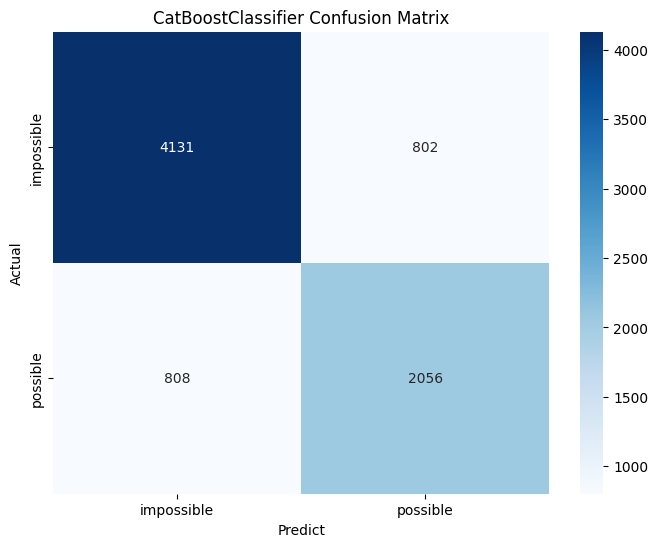




=== CatBoostClassifier Feature Importance ===
                Feature  Importance
15           hemoglobin    8.576219
20                  Gtp    7.907758
1            height(cm)    6.817220
12         triglyceride    6.605347
10  fasting blood sugar    6.259076
13                  HDL    6.034194
19                  ALT    5.873971
0                   age    5.594848
3             waist(cm)    5.392886
8              systolic    5.269916
9            relaxation    5.245264
18                  AST    5.188789
14                  LDL    4.614780
11          Cholesterol    4.505430
17     serum creatinine    4.490710
5       eyesight(right)    3.384417
4        eyesight(left)    3.345046
2            weight(kg)    3.001755
21        dental caries    1.482534
16        Urine protein    0.243044
7        hearing(right)    0.085683
6         hearing(left)    0.081115


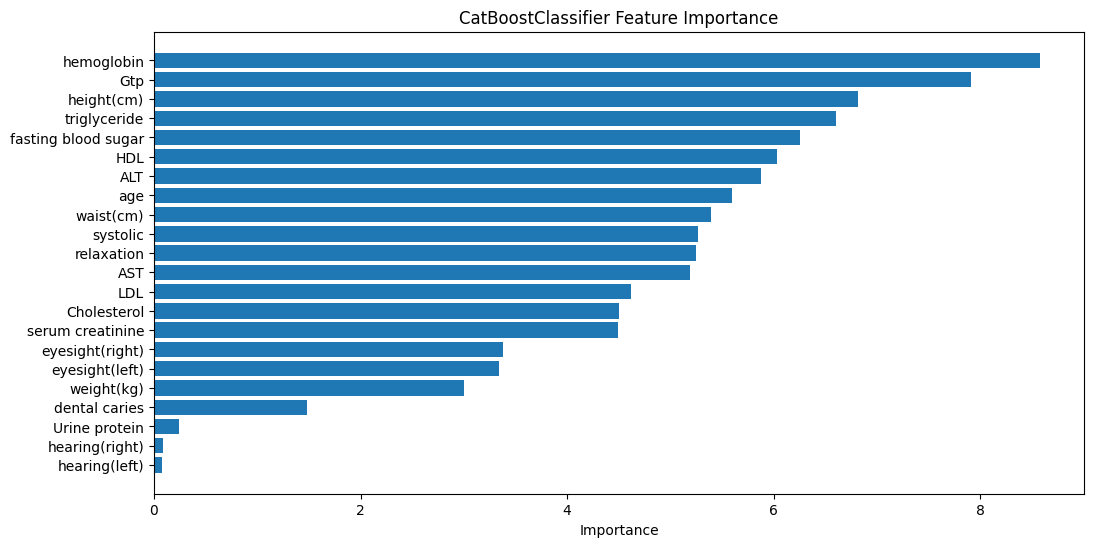



===== HistGradientBoostingClassifier =====
Fitting 2 folds for each of 8 candidates, totalling 16 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


최적 하이퍼파라미터: {'max_iter': 150, 'max_depth': 5, 'learning_rate': 0.1}
정확도: 0.7573
ROC-AUC: 0.8373
분류 보고서:
               precision    recall  f1-score   support

           0       0.82      0.80      0.81      4933
           1       0.66      0.69      0.68      2864

    accuracy                           0.76      7797
   macro avg       0.74      0.74      0.74      7797
weighted avg       0.76      0.76      0.76      7797



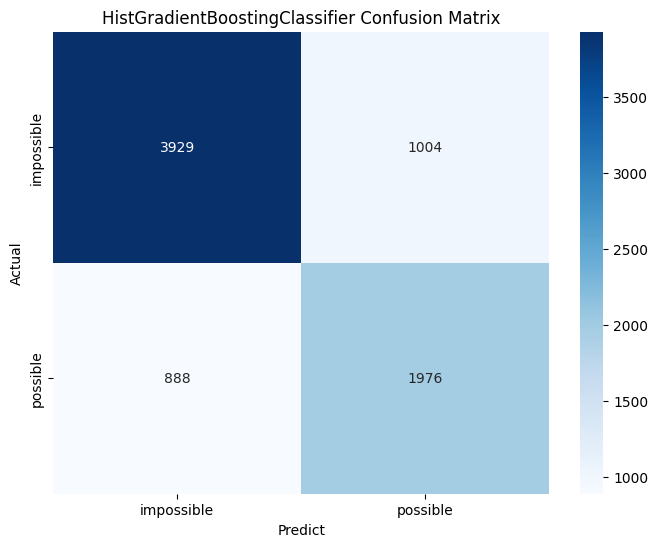




=== HistGradientBoostingClassifier does not support feature importance ===




In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.experimental import enable_hist_gradient_boosting  # for HistGradientBoostingClassifier

# 타겟 변수 분리
y = train_df['smoking']
X = train_df.drop(columns=['smoking'])

# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 모델 리스트
models = {
    'CatBoostClassifier': CatBoostClassifier(verbose=0, random_state=42),
    'HistGradientBoostingClassifier': HistGradientBoostingClassifier(max_iter=100, random_state=42)
}

# 하이퍼파라미터 그리드 정의
param_grids = {
    'CatBoostClassifier': {
        'iterations': [1100, 1150],
        'learning_rate': [0.01, 0.1],
        'depth': [6, 10]
    },
    'HistGradientBoostingClassifier': {
        'max_iter': [100, 150],
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5]
    }
}

# 모델 학습 및 하이퍼파라미터 튜닝
for name, model in models.items():
    print(f'===== {name} =====')

    # RandomizedSearchCV 사용
    random_search = RandomizedSearchCV(estimator=model, param_distributions=param_grids[name], n_iter=10,
                                       cv=2, n_jobs=-1, verbose=2, random_state=42)
    random_search.fit(X_train, y_train)

    print(f'최적 하이퍼파라미터: {random_search.best_params_}')

    # 최적 모델로 예측
    best_model = random_search.best_estimator_
    y_pred = best_model.predict(X_test)

    # 성능 평가
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1]) if hasattr(model, 'predict_proba') else None

    print(f'정확도: {accuracy:.4f}')
    if roc_auc is not None:
        print(f'ROC-AUC: {roc_auc:.4f}')
    print('분류 보고서:\n', classification_report(y_test, y_pred))

    # 혼동 행렬 시각화
    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_test, y_pred),
                annot=True, fmt='d', cmap='Blues',
                xticklabels=['impossible', 'possible'],
                yticklabels=['impossible', 'possible'])
    plt.title(f'{name} Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predict')
    plt.show()
    print('\n')

    if hasattr(best_model, 'feature_importances_'):
        feature_importance = best_model.feature_importances_
        feature_names = X_train.columns

        # Feature Importance 시각화
        importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
        importance_df = importance_df.sort_values(by='Importance', ascending=False)

        print(f'\n=== {name} Feature Importance ===')
        print(importance_df)

        # 시각화
        import matplotlib.pyplot as plt
        plt.figure(figsize=(12, 6))
        plt.barh(importance_df['Feature'], importance_df['Importance'])
        plt.gca().invert_yaxis()  # 중요도가 높은 순서대로 보기
        plt.title(f'{name} Feature Importance')
        plt.xlabel('Importance')
        plt.show()
    else:
        print(f'\n=== {name} does not support feature importance ===')
    print('\n')

## 과적합 확인

CatBoost

In [ ]:
from sklearn.model_selection import cross_val_score

model = CatBoostClassifier()
accuracy_cat = 0.7935

# 모델을 교차 검증하여 성능 평가
cv_scores = cross_val_score(model, X_train, y_train, cv=5) # 데이터를 5개의 폴드(fold)로 나누고 각 폴드에서 훈련과 검증을 반복하여 평균 성능을 계산
                                                           # cv_scores는 5번의 교차 검증에서 얻은 성능 점수가 저장됨

print("교차 검증 평균 성능:", cv_scores.mean())

# 훈련 데이터의 정확도가 교차 검증 성능보다 0.1 이상 높으면 과적합 가능성이 있다고 판단
if cv_scores.mean() < accuracy_cat - 0.1:
    print("과적합 가능성 있음")
else:
    print("과적합 아님")

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
6:	learn: 0.5958880	total: 68.3ms	remaining: 9.68s
7:	learn: 0.5869119	total: 77.7ms	remaining: 9.64s
8:	learn: 0.5791916	total: 87.6ms	remaining: 9.65s
9:	learn: 0.5720589	total: 97.1ms	remaining: 9.61s
10:	learn: 0.5659002	total: 108ms	remaining: 9.66s
11:	learn: 0.5596429	total: 119ms	remaining: 9.83s
12:	learn: 0.5542344	total: 132ms	remaining: 10s
13:	learn: 0.5490745	total: 142ms	remaining: 9.97s
14:	learn: 0.5440842	total: 151ms	remaining: 9.94s
15:	learn: 0.5402188	total: 164ms	remaining: 10.1s
16:	learn: 0.5363644	total: 182ms	remaining: 10.5s
17:	learn: 0.5326557	total: 197ms	remaining: 10.7s
18:	learn: 0.5294287	total: 209ms	remaining: 10.8s
19:	learn: 0.5266880	total: 224ms	remaining: 11s
20:	learn: 0.5239562	total: 235ms	remaining: 11s
21:	learn: 0.5212419	total: 245ms	remaining: 10.9s
22:	learn: 0.5189780	total: 255ms	remaining: 10.9s
23:	learn: 0.5169136	total: 267ms	remaining: 10.8s
24:	learn: 0.5147814	total: 277ms	remaining: 10.8s
2

HistGradientBoosting

In [ ]:
from sklearn.model_selection import cross_val_score

model = HistGradientBoostingClassifier()
accuracy_cat = 0.7573

# 모델을 교차 검증하여 성능 평가
cv_scores = cross_val_score(model, X_train, y_train, cv=5) # 데이터를 5개의 폴드(fold)로 나누고 각 폴드에서 훈련과 검증을 반복하여 평균 성능을 계산
                                                           # cv_scores는 5번의 교차 검증에서 얻은 성능 점수가 저장됨

print("교차 검증 평균 성능:", cv_scores.mean())

# 훈련 데이터의 정확도가 교차 검증 성능보다 0.1 이상 높으면 과적합 가능성이 있다고 판단
if cv_scores.mean() < accuracy - 0.1:
    print("과적합 가능성 있음")
else:
    print("과적합 아님")

교차 검증 평균 성능: 0.7598678531242389
과적합 아님


# XGBoost,LightGBM

## 모델링

XGBoost

In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 타겟 변수 분리
y = train_df['smoking']
X = train_df.drop(columns=['smoking'])

# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# XGBoost 모델 생성
xgb_model = xgb.XGBClassifier(
    n_estimators=1000,  # 트리 개수
    learning_rate=0.05,  # 학습률
    max_depth=6,  # 트리 깊이
    colsample_bytree=0.8,  # 트리별 샘플링 비율
    subsample=0.8,  # 데이터 샘플링 비율
    random_state=42
)

# 모델 학습
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

# 예측
y_pred = xgb_model.predict(X_test)

# 정확성, 정밀도, 재현율, F1 점수 계산
xgb_acc = accuracy_score(y_test, y_pred)
xgb_precision = precision_score(y_test, y_pred, average='weighted')  # 클래스 불균형 처리
xgb_recall = recall_score(y_test, y_pred, average='weighted')
xgb_f1 = f1_score(y_test, y_pred, average='weighted')

# 결과 출력
print(f"XGBoost Accuracy: {xgb_acc:.4f}")
print(f"XGBoost Precision: {xgb_precision:.4f}")
print(f"XGBoost Recall: {xgb_recall:.4f}")
print(f"XGBoost F1 Score: {xgb_f1:.4f}")

XGBoost Accuracy: 0.7782
XGBoost Precision: 0.7786
XGBoost Recall: 0.7782
XGBoost F1 Score: 0.7784


LightGBM

In [ ]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# LightGBM 모델 생성
lgb_model = lgb.LGBMClassifier(
    n_estimators=1000,            # 트리의 개수
    learning_rate=0.05,           # 학습률
    max_depth=8,                  # 트리의 최대 깊이
    colsample_bytree=0.8,         # 트리별 특성 샘플링 비율
    subsample=0.8,                # 샘플링 비율
    random_state=42               # 랜덤 시드
)

# 모델 학습 (훈련 상태 출력 없이)
lgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)])

# 예측
y_pred = lgb_model.predict(X_test)

# 정확성, 정밀도, 재현율, F1 점수 계산
lgb_acc = accuracy_score(y_test, y_pred)
lgb_precision = precision_score(y_test, y_pred, average='weighted')  # 클래스 불균형 처리
lgb_recall = recall_score(y_test, y_pred, average='weighted')
lgb_f1 = f1_score(y_test, y_pred, average='weighted')

# 결과 출력
print(f"LightGBM Accuracy: {lgb_acc:.4f}")
print(f"LightGBM Precision: {lgb_precision:.4f}")
print(f"LightGBM Recall: {lgb_recall:.4f}")
print(f"LightGBM F1 Score: {lgb_f1:.4f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 11454, number of negative: 19733
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004142 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2324
[LightGBM] [Info] Number of data points in the train set: 31187, number of used features: 22
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.367268 -> initscore=-0.543953
[LightGBM] [Info] Start training from score -0.543953
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

## 과적합 확인

XGBoost

In [ ]:
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier

model = XGBClassifier()
accuracy_cat = 0.7782

# 모델을 교차 검증하여 성능 평가
cv_scores = cross_val_score(model, X_train, y_train, cv=5) # 데이터를 5개의 폴드(fold)로 나누고 각 폴드에서 훈련과 검증을 반복하여 평균 성능을 계산
                                                           # cv_scores는 5번의 교차 검증에서 얻은 성능 점수가 저장됨

print("교차 검증 평균 성능:", cv_scores.mean())

# 훈련 데이터의 정확도가 교차 검증 성능보다 0.1 이상 높으면 과적합 가능성이 있다고 판단
if cv_scores.mean() < accuracy_cat - 0.1:
    print("과적합 가능성 있음")
else:
    print("과적합 아님")

교차 검증 평균 성능: 0.7656714372435223
과적합 아님


LightGBM

In [ ]:
from lightgbm import LGBMClassifier

model = LGBMClassifier()
accuracy_cat = 0.7752

# 모델을 교차 검증하여 성능 평가
cv_scores = cross_val_score(model, X_train, y_train, cv=5) # 데이터를 5개의 폴드(fold)로 나누고 각 폴드에서 훈련과 검증을 반복하여 평균 성능을 계산
                                                           # cv_scores는 5번의 교차 검증에서 얻은 성능 점수가 저장됨

print("교차 검증 평균 성능:", cv_scores.mean())

# 훈련 데이터의 정확도가 교차 검증 성능보다 0.1 이상 높으면 과적합 가능성이 있다고 판단
if cv_scores.mean() < accuracy_cat - 0.1:
    print("과적합 가능성 있음")
else:
    print("과적합 아님")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 9163, number of negative: 15786
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004334 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2275
[LightGBM] [Info] Number of data points in the train set: 24949, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.367269 -> initscore=-0.543950
[LightGBM] [Info] Start training from score -0.543950
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 9163, number of negative: 15786
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.030148 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2264
[LightGBM] [Info]

## 하이퍼파라미터 튜닝

===== XGBoostClassifier =====
Fitting 2 folds for each of 10 candidates, totalling 20 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [12:51:00] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


최적 하이퍼파라미터: {'n_estimators': 750, 'max_depth': 5, 'learning_rate': 0.1}
정확도: 0.7707
ROC-AUC: 0.8484
분류 보고서:
               precision    recall  f1-score   support

           0       0.82      0.82      0.82      4933
           1       0.69      0.69      0.69      2864

    accuracy                           0.77      7797
   macro avg       0.75      0.75      0.75      7797
weighted avg       0.77      0.77      0.77      7797



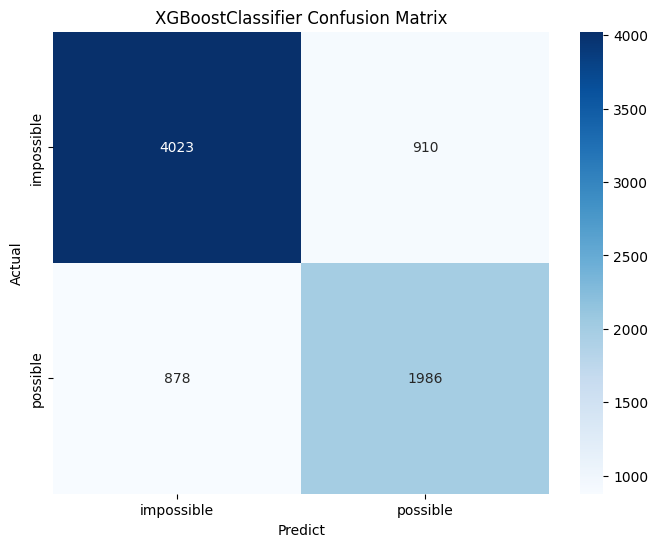



===== LGBMClassifier =====
Fitting 2 folds for each of 10 candidates, totalling 20 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 11454, number of negative: 19733
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012658 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2324
[LightGBM] [Info] Number of data points in the train set: 31187, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.367268 -> initscore=-0.543953
[LightGBM] [Info] Start training from score -0.543953
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spli

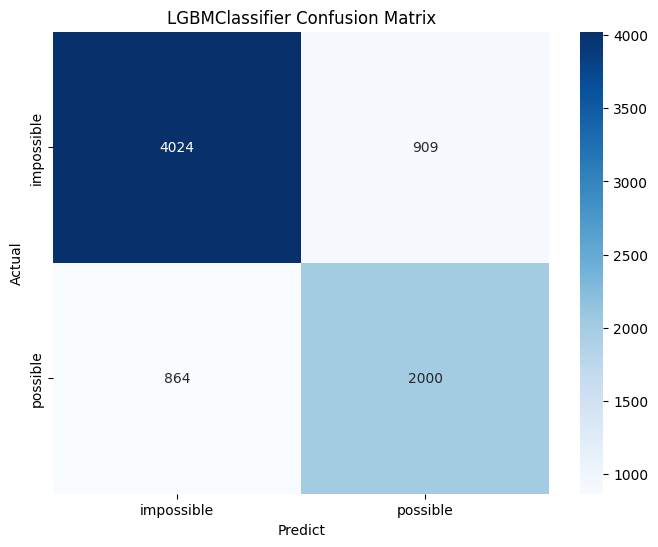

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 타겟 변수 분리
y = train_df['smoking']
X = train_df.drop(columns=['smoking'])

# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 모델 리스트
models = {
    'XGBoostClassifier': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'LGBMClassifier': LGBMClassifier(random_state=42)
}

# 하이퍼파라미터 그리드 정의
param_grids = {
    'XGBoostClassifier': {
        'n_estimators': [700, 750, 800],
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5]
    },
    'LGBMClassifier': {
        'n_estimators': [700, 750, 800],
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5]
    }
}

# 모델 학습 및 하이퍼파라미터 튜닝
for name, model in models.items():
    print(f'===== {name} =====')

    # RandomizedSearchCV 사용
    random_search = RandomizedSearchCV(estimator=model, param_distributions=param_grids[name], n_iter=10,
                                       cv=2, n_jobs=-1, verbose=2, random_state=42)
    random_search.fit(X_train, y_train)

    print(f'최적 하이퍼파라미터: {random_search.best_params_}')

    # 최적 모델로 예측
    best_model = random_search.best_estimator_
    y_pred = best_model.predict(X_test)

    # 성능 평가
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1]) if hasattr(model, 'predict_proba') else None

    print(f'정확도: {accuracy:.4f}')
    if roc_auc is not None:
        print(f'ROC-AUC: {roc_auc:.4f}')
    print('분류 보고서:\n', classification_report(y_test, y_pred))

    # 혼동 행렬 시각화
    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_test, y_pred),
                annot=True, fmt='d', cmap='Blues',
                xticklabels=['impossible', 'possible'],
                yticklabels=['impossible', 'possible'])
    plt.title(f'{name} Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predict')
    plt.show()
    print('\n')

XGB, LGB 모델 모두 하이퍼파라미터 튜닝을 하지 않았을 때가 정확도가 더 높았다.

따라서 feature engineering을 이용하여 성능 개선을 하는 방법을 택하였다.

# RandomForest, ExtraTrees

## 모델링

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier

In [ ]:
#1. RandomForestClassifier (랜덤 포레스트)
#2. ExtraTreesClassifier (엑스트라 트리)

# 타겟 변수 분리
y = train_df['smoking']
X = train_df.drop(columns=['smoking'])

# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

models = {
    "RandomForest": RandomForestClassifier(random_state=42, n_estimators=100),
    "ExtraTrees": ExtraTreesClassifier(random_state=42, n_estimators=100)
}

# 모델 학습 및 평가
metrics = []

for name, model in models.items(): #.items() 메서드는 각 키(key)와 값(value)을 튜플로 반환
    model.fit(X_train, y_train)  # 모델 학습
    y_pred = model.predict(X_test)  # 예측
    y_prob = model.predict_proba(X_test)[:, 1]

    # 평가 지표 계산
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    metrics.append([name, accuracy, precision, recall, f1, roc_auc])

# 평가 결과 출력
metrics_df = pd.DataFrame(metrics, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", 'ROC-AUC'])
metrics_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,RandomForest,0.7988,0.7300,0.7175,0.7237,0.8832
1,ExtraTrees,0.7906,0.7213,0.7004,0.7107,0.8843


RandomForest 교차 검증

In [ ]:
model = RandomForestClassifier()
accuracy_cat = 0.7988

# 모델을 교차 검증하여 성능 평가
cv_scores = cross_val_score(model, X_train, y_train, cv=5) # 데이터를 5개의 폴드(fold)로 나누고 각 폴드에서 훈련과 검증을 반복하여 평균 성능을 계산
                                                           # cv_scores는 5번의 교차 검증에서 얻은 성능 점수가 저장됨

print("교차 검증 평균 성능:", cv_scores.mean())

# 훈련 데이터의 정확도가 교차 검증 성능보다 0.1 이상 높으면 과적합 가능성이 있다고 판단
if cv_scores.mean() < accuracy_cat - 0.1:
    print("과적합 가능성 있음")
else:
    print("과적합 아님")

교차 검증 평균 성능: 0.7925736908209923
과적합 아님


## 하이퍼파라미터 튜닝

In [ ]:
## 성능 평가 함수 정의
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n{model_name} 성능 평가")
    print("="* 50)


    # 분류 보고서 출력 (정밀도, 재현율, F1 점수 등)
    print("\n분류 보고서:")
    print(classification_report(y_true, y_pred))

# 혼동 행렬 시각화 함수 정의
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-Smoker', 'Smoker'],
                yticklabels=['Non-Smoker', 'Smoker'])
    plt.title(f'{model_name} Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

===== RandomForest =====
RandomForest 정확도: 0.7961
RandomForest roc_auc: 0.8847

RandomForest 최종 성능:
Train f1-score: 1.0000
Test f1-score: 0.7964

혼동 행렬:


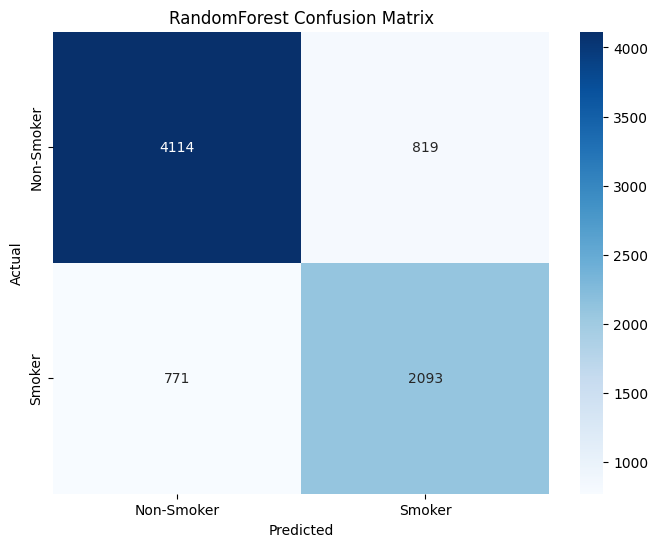


분류 리포트:
              precision    recall  f1-score   support

           0       0.84      0.83      0.84      4933
           1       0.72      0.73      0.72      2864

    accuracy                           0.80      7797
   macro avg       0.78      0.78      0.78      7797
weighted avg       0.80      0.80      0.80      7797

===== ExtraTrees =====
ExtraTrees 정확도: 0.8007
ExtraTrees roc_auc: 0.8874

ExtraTrees 최종 성능:
Train f1-score: 0.9999
Test f1-score: 0.8012

혼동 행렬:


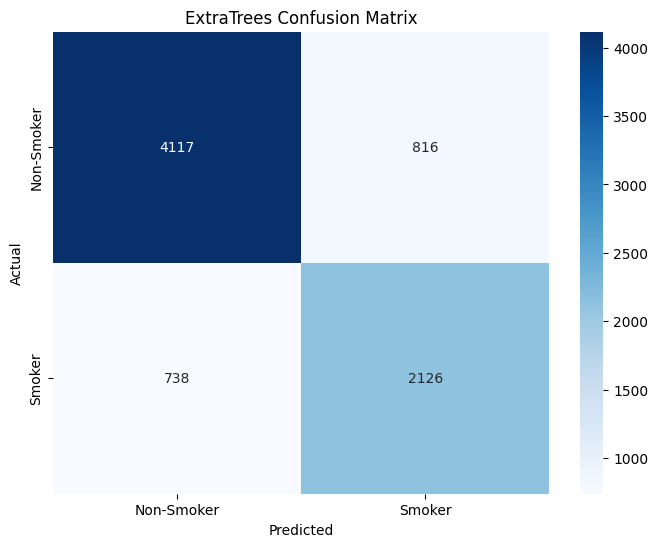


분류 리포트:
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      4933
           1       0.72      0.74      0.73      2864

    accuracy                           0.80      7797
   macro avg       0.79      0.79      0.79      7797
weighted avg       0.80      0.80      0.80      7797



In [ ]:
# 2. RandomForestClassifier (랜덤 포레스트)
rf_model = RandomForestClassifier(
    n_estimators=300,       # 트리의 개수
    max_depth=None,            # 트리의 최대 깊이
    min_samples_split=3,    # 내부 노드를 분할하기 위한 최소 샘플 수(2~20), 현재 노드에 있는 샘플 개수가 이 값보다 작으면 더 이상 분할되지 않음.
    min_samples_leaf=1,     # 리프 노드가 되기 위한 최소 샘플 수,  트리의 깊이를 줄이고 싶다면 높이기(1~10까지)
    max_features= "sqrt",       # 특성 샘플링 비율, "sqrt" (기본값, 특성 개수의 제곱근)
    bootstrap=True,         # 부트스트랩 샘플링 사용 여부
    #class_weight="balanced",  # 가중치 적용 (불균형 데이터 보정)
    random_state=42)

rf_model.fit(X_train, y_train)


# 3. ExtraTreesClassifier (엑스트라 트리)
et_model = ExtraTreesClassifier(
    n_estimators=300,       # 트리의 개수
    max_depth=None,            # 트리의 최대 깊이
    min_samples_split=3,    # 내부 노드를 분할하기 위한 최소 샘플 수, 현재 노드에 있는 샘플 개수가 이 값보다 작으면 더 이상 분할되지 않음.
    min_samples_leaf=2,     # 리프 노드가 되기 위한 최소 샘플 수,  트리의 깊이를 줄이고 싶다면 높이기(10까지)
    max_features=0.5,       # 특성 샘플링 비율, "sqrt" (기본값, 특성 개수의 제곱근)
    bootstrap=False,        # 부트스트랩 샘플링 사용 여부 (엑스트라 트리는 보통 False)
    #class_weight="balanced",  # 가중치 적용 (불균형 데이터 보정)
    random_state=42)

et_model.fit(X_train, y_train)


# 모델 평가
models = {'RandomForest': rf_model, 'ExtraTrees': et_model}

for name, model in models.items():
    print(f'===== {name} =====')
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # ROC-AUC 계산을 위해 확률값 사용
    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print(f'{name} 정확도: {acc:.4f}')
    print(f'{name} roc_auc: {roc_auc:.4f}')

    # train set 성능
    train_pred = model.predict(X_train)
    train_acc = f1_score(y_train, train_pred, average='weighted')

    # test set 성능
    test_pred = model.predict(X_test)
    test_acc = f1_score(y_test, test_pred, average='weighted')

    print(f"\n{name} 최종 성능:")
    print(f"Train f1-score: {train_acc:.4f}")
    print(f"Test f1-score: {test_acc:.4f}")

    print("\n혼동 행렬:")
    plot_confusion_matrix(y_test, y_pred, name)

    print("\n분류 리포트:")
    print(classification_report(y_test, test_pred))

ExtraTrees 교차 검증

In [ ]:
model = ExtraTreesClassifier()
accuracy_cat = 0.8007

# 모델을 교차 검증하여 성능 평가
cv_scores = cross_val_score(model, X_train, y_train, cv=5) # 데이터를 5개의 폴드(fold)로 나누고 각 폴드에서 훈련과 검증을 반복하여 평균 성능을 계산
                                                           # cv_scores는 5번의 교차 검증에서 얻은 성능 점수가 저장됨

print("교차 검증 평균 성능:", cv_scores.mean())

# 훈련 데이터의 정확도가 교차 검증 성능보다 0.1 이상 높으면 과적합 가능성이 있다고 판단
if cv_scores.mean() < accuracy_cat - 0.1:
    print("과적합 가능성 있음")
else:
    print("과적합 아님")

교차 검증 평균 성능: 0.7876999381541435
과적합 아님


# 중간 결론



---


< 모델들의 최고 성능 순위 >
1. ExtraTrees : 0.8007
2. RandomForest : 0.7988
3. CatBoost : 0.7935
4. XGBoost : 0.7782
5. LightGBM : 0.7752
6. HistGradientBoosting : 0.7573

HistGradientBoosting보다 이를 제외한 나머지 모델들의 정확도 값이 더 높고 서로 비슷하기에

**5개 모델로 Feature Engineering을 추가로 진행**하여 성능 개선을 이루고자 한다.


---



# Feature Engineering

새롭게 만들 수 있는 컬럼
- 비만도 지표
  - BMI (체질량지수) : weight(kg)/(height(m)^2)

- 심혈관 질환 관련(값이 높을수록 안 좋음)
  - 중성지방/HDL 비율 : triglyceride/HDL
  - LDL/HDL 비율
  - BP Ratio : Systolic/Relaxation

*HDL:좋은 콜레스테롤 / LDL:나쁜 콜레스테롤

*BP Ratio 2.0 이상이면 심근경색, 뇌졸중 위험이 높아짐.

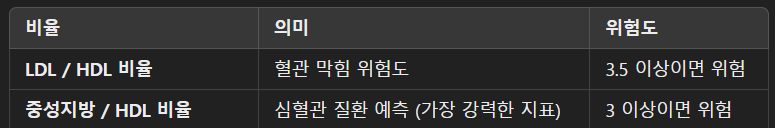

## 파생 변수 생성

In [9]:
# BMI 컬럼 생성
train_df['BMI'] = train_df['weight(kg)']/((train_df['height(cm)']/100)**2)
test_df['BMI'] = test_df['weight(kg)']/((test_df['height(cm)']/100)**2)

# 중성지방/HDL 비율 컬럼 생성
train_df['triglyceride/HDL'] = train_df['triglyceride']/train_df['HDL']
test_df['triglyceride/HDL'] = test_df['triglyceride']/test_df['HDL']

# LDL/HDL 비율 컬럼 생성
train_df['LDL/HDL'] = train_df['LDL']/train_df['HDL']
test_df['LDL/HDL'] = test_df['LDL']/test_df['HDL']

# BP Ratio(Systolic/Relaxation) 컬럼 생성
train_df['BP Ratio'] = train_df['systolic']/train_df['relaxation']
test_df['BP Ratio'] = test_df['systolic']/test_df['relaxation']

In [ ]:
train_df

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,serum creatinine,AST,ALT,Gtp,dental caries,smoking,BMI,triglyceride/HDL,LDL/HDL,BP Ratio
0,35,170,85,97.0,0.9,0.9,1,1,118,78,...,1.0,61,115,125,1,1,29.411765,2.185714,2.028571,1.512821
1,20,175,110,110.0,0.7,0.9,1,1,119,79,...,1.1,19,25,30,1,0,35.918367,1.802817,1.605634,1.506329
2,45,155,65,86.0,0.9,0.9,1,1,110,80,...,0.6,1090,1400,276,0,0,27.055151,2.105263,1.964912,1.375000
3,45,165,80,94.0,0.8,0.7,1,1,158,88,...,0.9,32,36,36,0,0,29.384757,7.956522,1.978261,1.795455
4,20,165,60,81.0,1.5,0.1,1,1,109,64,...,1.2,26,28,15,0,0,22.038567,4.255319,1.957447,1.703125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38979,40,165,60,80.0,0.4,0.6,1,1,107,60,...,0.5,18,18,21,1,0,22.038567,0.868852,1.180328,1.783333
38980,45,155,55,75.0,1.5,1.2,1,1,126,72,...,0.6,23,11,12,0,0,22.892820,1.315789,1.723684,1.750000
38981,40,170,105,124.0,0.6,0.5,1,1,141,85,...,0.8,24,23,35,1,1,36.332180,4.083333,2.875000,1.658824
38982,40,160,55,75.0,1.5,1.5,1,1,95,69,...,0.6,24,20,17,0,1,21.484375,0.607595,1.468354,1.376812


In [ ]:
test_df

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,BMI,triglyceride/HDL,LDL/HDL,BP Ratio
0,40,170,65,75.1,1.0,0.9,1,1,120,70,...,1,0.8,24,26,32,0,22.491349,6.341463,3.219512,1.714286
1,45,170,75,89.0,0.7,1.2,1,1,100,67,...,1,1.1,26,28,138,0,25.951557,7.040816,2.857143,1.492537
2,30,180,90,94.0,1.0,0.8,1,1,115,72,...,1,1.0,19,29,30,0,27.777778,1.943396,1.943396,1.597222
3,60,170,50,73.0,0.5,0.7,1,1,118,78,...,1,1.3,31,28,33,0,17.301038,1.076923,1.661538,1.512821
4,30,170,65,78.0,1.5,1.0,1,1,110,70,...,1,0.8,21,21,19,0,22.491349,4.666667,2.288889,1.571429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16703,60,165,65,82.0,0.7,1.0,1,1,101,68,...,1,0.8,78,75,33,0,23.875115,3.195122,2.682927,1.485294
16704,60,155,70,93.0,0.8,1.0,1,1,134,70,...,1,0.7,19,28,28,1,29.136316,4.886792,1.132075,1.914286
16705,40,155,50,67.2,0.9,0.8,1,1,134,80,...,1,0.7,16,10,14,0,20.811655,0.781250,2.046875,1.675000
16706,35,165,70,76.1,1.0,1.0,1,1,114,68,...,1,1.2,19,28,30,1,25.711662,0.581081,1.594595,1.676471


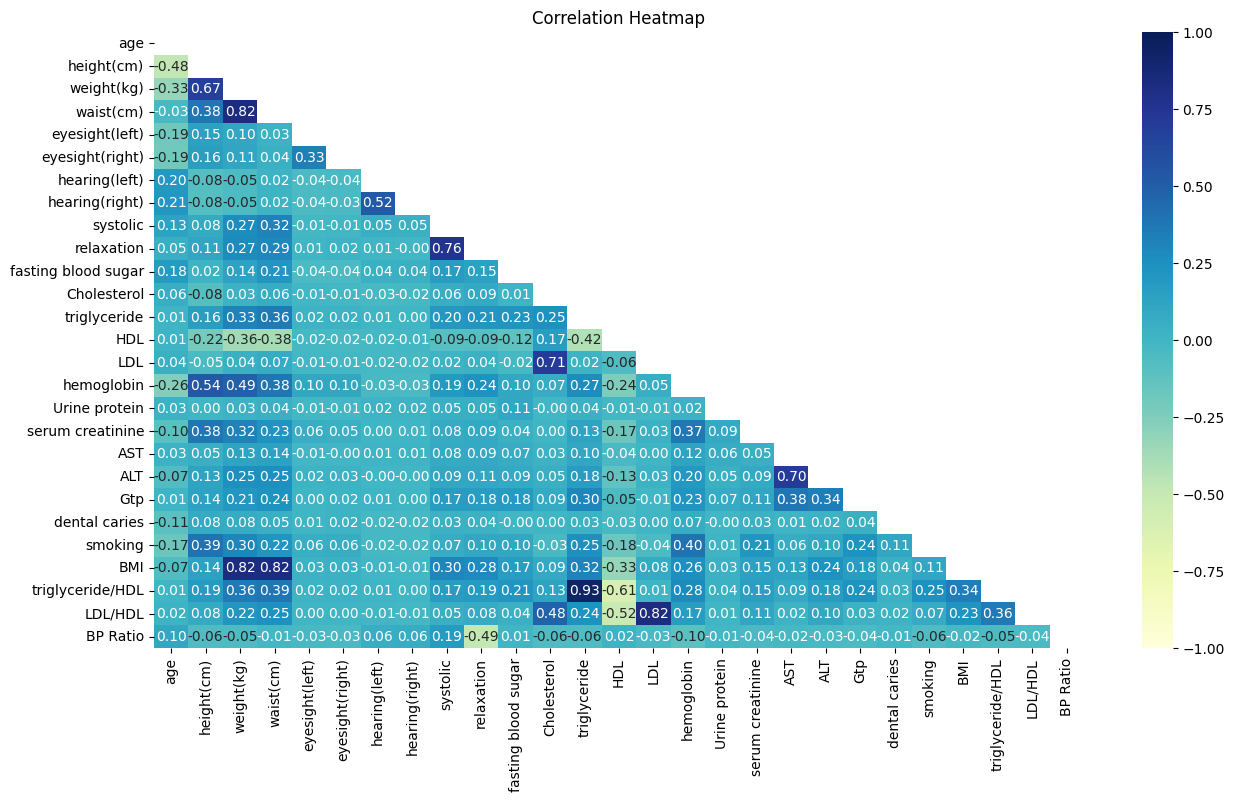

In [ ]:
# 상관관계 계산
correlation_matrix = train_df.corr()

# 상삼각행렬만 선택 (대각선 위 부분만 남기고 나머지는 NaN 처리)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# 히트맵 그리기
plt.figure(figsize=(15, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='YlGnBu', fmt='.2f', vmin=-1, vmax=1, mask=mask)

# 제목 설정
plt.title('Correlation Heatmap')

# 그래프 출력
plt.show()

## 모델별 모델링 및 성능평가

중간 결론 전에 진행한 부분에서

각 모델마다 높은 정확도를 보인 모델링 코드를 이용하여 아래 과정을 진행하였다.

CatBoost

===== CatBoostClassifier =====
Fitting 2 folds for each of 8 candidates, totalling 16 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


최적 하이퍼파라미터: {'learning_rate': 0.1, 'iterations': 1150, 'depth': 10}
정확도: 0.7918
ROC-AUC: 0.8764
분류 보고서:
               precision    recall  f1-score   support

           0       0.84      0.83      0.84      4933
           1       0.72      0.72      0.72      2864

    accuracy                           0.79      7797
   macro avg       0.78      0.78      0.78      7797
weighted avg       0.79      0.79      0.79      7797



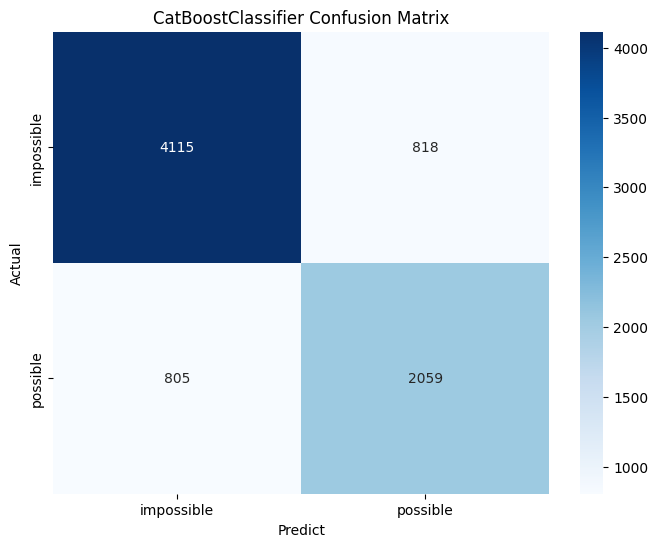




=== CatBoostClassifier Feature Importance ===
                Feature  Importance
15           hemoglobin    8.088127
20                  Gtp    7.328014
1            height(cm)    6.114801
10  fasting blood sugar    5.556207
19                  ALT    5.431815
25             BP Ratio    5.282854
0                   age    5.275956
18                  AST    4.785775
3             waist(cm)    4.568860
12         triglyceride    4.306903
17     serum creatinine    4.248115
8              systolic    4.136844
11          Cholesterol    3.895093
22                  BMI    3.812147
24              LDL/HDL    3.757468
23     triglyceride/HDL    3.672066
9            relaxation    3.585830
13                  HDL    3.479696
14                  LDL    3.462473
4        eyesight(left)    2.985759
5       eyesight(right)    2.910365
2            weight(kg)    1.505923
21        dental caries    1.494155
16        Urine protein    0.176663
7        hearing(right)    0.075648
6         heari

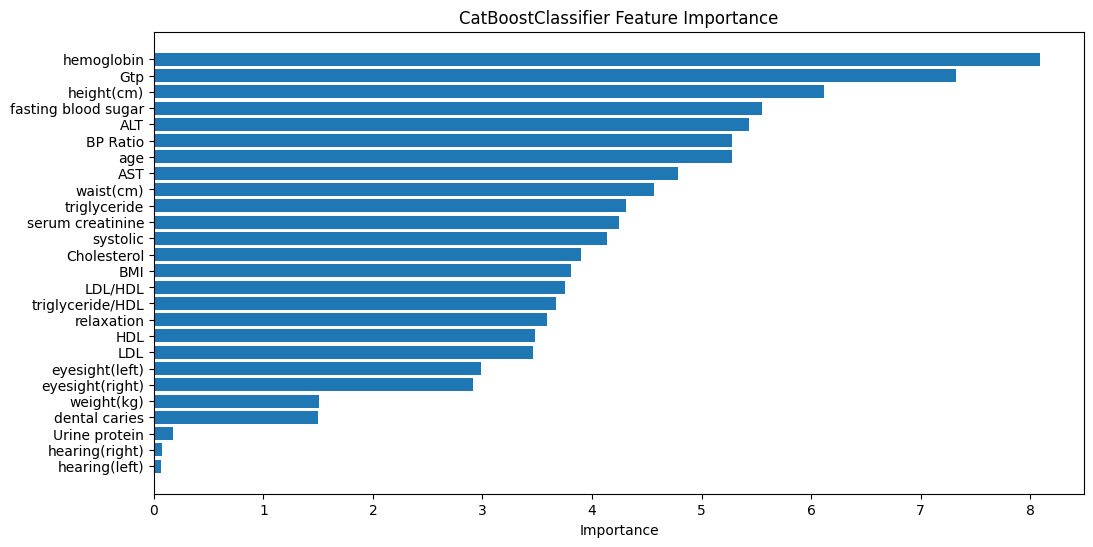

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# 타겟 변수 분리
y = train_df['smoking']
X = train_df.drop(columns=['smoking'])

# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 모델 리스트
model = CatBoostClassifier(verbose=0, random_state=42)

# 하이퍼파라미터 그리드 정의
param_grids = {'iterations': [1100, 1150], 'learning_rate': [0.01, 0.1], 'depth': [6, 10]}

# 모델 학습 및 하이퍼파라미터 튜닝
print('===== CatBoostClassifier =====')

# RandomizedSearchCV 사용
random_search = RandomizedSearchCV(estimator=model, param_distributions=param_grids, n_iter=10,
                                   cv=2, n_jobs=-1, verbose=2, random_state=42)
random_search.fit(X_train, y_train)

print(f'최적 하이퍼파라미터: {random_search.best_params_}')

# 최적 모델로 예측
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

# 성능 평가
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1]) if hasattr(model, 'predict_proba') else None

print(f'정확도: {accuracy:.4f}')
if roc_auc is not None:
    print(f'ROC-AUC: {roc_auc:.4f}')
print('분류 보고서:\n', classification_report(y_test, y_pred))

# 혼동 행렬 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred),
             annot=True, fmt='d', cmap='Blues',
             xticklabels=['impossible', 'possible'],
             yticklabels=['impossible', 'possible'])
plt.title('CatBoostClassifier Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predict')
plt.show()
print('\n')

feature_importance = best_model.feature_importances_
feature_names = X_train.columns

# Feature Importance 시각화
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print('\n=== CatBoostClassifier Feature Importance ===')
print(importance_df)

# 시각화
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.gca().invert_yaxis()  # 중요도가 높은 순서대로 보기
plt.title('CatBoostClassifier Feature Importance')
plt.xlabel('Importance')
plt.show()

XGBoost

In [ ]:
# XGBoost 모델 생성
xgb_model = xgb.XGBClassifier(
    n_estimators=1000,  # 트리 개수
    learning_rate=0.05,  # 학습률
    max_depth=6,  # 트리 깊이
    colsample_bytree=0.8,  # 트리별 샘플링 비율
    subsample=0.8,  # 데이터 샘플링 비율
    random_state=42
)

# 모델 학습
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

# 예측
y_pred = xgb_model.predict(X_test)

# 정확성, 정밀도, 재현율, F1 점수 계산
xgb_acc = accuracy_score(y_test, y_pred)
xgb_precision = precision_score(y_test, y_pred, average='weighted')  # 클래스 불균형 처리
xgb_recall = recall_score(y_test, y_pred, average='weighted')
xgb_f1 = f1_score(y_test, y_pred, average='weighted')

# 결과 출력
print(f"XGBoost Accuracy: {xgb_acc:.4f}")
print(f"XGBoost Precision: {xgb_precision:.4f}")
print(f"XGBoost Recall: {xgb_recall:.4f}")
print(f"XGBoost F1 Score: {xgb_f1:.4f}")

XGBoost Accuracy: 0.7829
XGBoost Precision: 0.7827
XGBoost Recall: 0.7829
XGBoost F1 Score: 0.7828


LightGBM

In [ ]:
# LightGBM 모델 생성
lgb_model = lgb.LGBMClassifier(
    n_estimators=1000,            # 트리의 개수
    learning_rate=0.05,           # 학습률
    max_depth=8,                  # 트리의 최대 깊이
    colsample_bytree=0.8,         # 트리별 특성 샘플링 비율
    subsample=0.8,                # 샘플링 비율
    random_state=42               # 랜덤 시드
)

# 모델 학습 (훈련 상태 출력 없이)
lgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)])

# 예측
y_pred = lgb_model.predict(X_test)

# 정확성, 정밀도, 재현율, F1 점수 계산
lgb_acc = accuracy_score(y_test, y_pred)
lgb_precision = precision_score(y_test, y_pred, average='weighted')  # 클래스 불균형 처리
lgb_recall = recall_score(y_test, y_pred, average='weighted')
lgb_f1 = f1_score(y_test, y_pred, average='weighted')

# 결과 출력
print(f"LightGBM Accuracy: {lgb_acc:.4f}")
print(f"LightGBM Precision: {lgb_precision:.4f}")
print(f"LightGBM Recall: {lgb_recall:.4f}")
print(f"LightGBM F1 Score: {lgb_f1:.4f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 11454, number of negative: 19733
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003975 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3214
[LightGBM] [Info] Number of data points in the train set: 31187, number of used features: 26
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.367268 -> initscore=-0.543953
[LightGBM] [Info] Start training from score -0.543953
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

RandomForest

In [ ]:
# 타겟 변수 분리
y = train_df['smoking']
X = train_df.drop(columns=['smoking'])

# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = RandomForestClassifier(random_state=42, n_estimators=100)

# 모델 학습 및 평가
metrics = []

model.fit(X_train, y_train)  # 모델 학습
y_pred = model.predict(X_test)  # 예측
y_prob = model.predict_proba(X_test)[:, 1]

# 평가 지표 계산
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

metrics.append(['RandomForest', accuracy, precision, recall, f1, roc_auc])

# 평가 결과 출력
metrics_df = pd.DataFrame(metrics, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", 'ROC-AUC'])
metrics_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,RandomForest,0.7972,0.7233,0.7256,0.7244,0.8813


ExtraTrees

===== ExtraTrees =====
ExtraTrees 정확도: 0.7992
ExtraTrees roc_auc: 0.8863

ExtraTrees 최종 성능:
Train f1-score: 0.9999
Test f1-score: 0.7996

혼동 행렬:


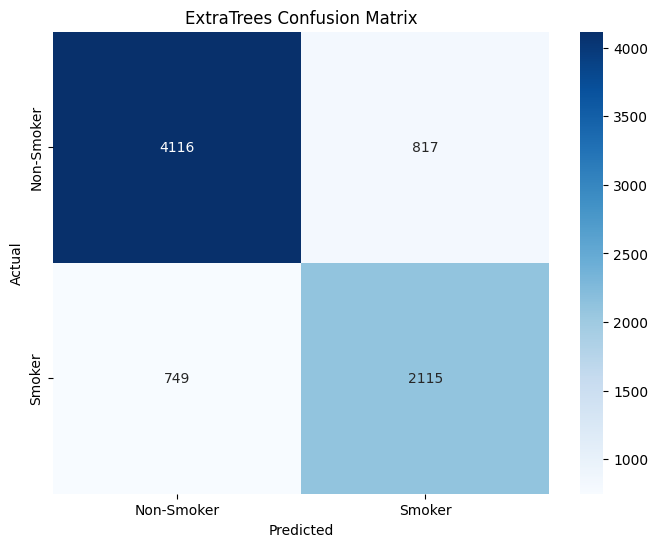


분류 리포트:
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      4933
           1       0.72      0.74      0.73      2864

    accuracy                           0.80      7797
   macro avg       0.78      0.79      0.78      7797
weighted avg       0.80      0.80      0.80      7797



In [ ]:
# 타겟 변수 분리
y = train_df['smoking']
X = train_df.drop(columns=['smoking'])

# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

et_model = ExtraTreesClassifier(
    n_estimators=300,       # 트리의 개수
    max_depth=None,            # 트리의 최대 깊이
    min_samples_split=3,    # 내부 노드를 분할하기 위한 최소 샘플 수, 현재 노드에 있는 샘플 개수가 이 값보다 작으면 더 이상 분할되지 않음.
    min_samples_leaf=2,     # 리프 노드가 되기 위한 최소 샘플 수,  트리의 깊이를 줄이고 싶다면 높이기(10까지)
    max_features=0.5,       # 특성 샘플링 비율, "sqrt" (기본값, 특성 개수의 제곱근)
    bootstrap=False,        # 부트스트랩 샘플링 사용 여부 (엑스트라 트리는 보통 False)
    #class_weight="balanced",  # 가중치 적용 (불균형 데이터 보정)
    random_state=42)

et_model.fit(X_train, y_train)


# 모델 평가
models = {'ExtraTrees': et_model}

for name, model in models.items():
    print(f'===== {name} =====')
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # ROC-AUC 계산을 위해 확률값 사용
    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print(f'{name} 정확도: {acc:.4f}')
    print(f'{name} roc_auc: {roc_auc:.4f}')

    # train set 성능
    train_pred = model.predict(X_train)
    train_acc = f1_score(y_train, train_pred, average='weighted')

    # test set 성능
    test_pred = model.predict(X_test)
    test_acc = f1_score(y_test, test_pred, average='weighted')

    print(f"\n{name} 최종 성능:")
    print(f"Train f1-score: {train_acc:.4f}")
    print(f"Test f1-score: {test_acc:.4f}")

    print("\n혼동 행렬:")
    plot_confusion_matrix(y_test, y_pred, name)

    print("\n분류 리포트:")
    print(classification_report(y_test, test_pred))

## 현 데이터의 문제점 파악

현재 생성된 컬럼들로는 성능이 전체적으로 오히려 감소하는 모습을 보인다.

따라서 추가적으로 문제점을 파악하고 이를 보완할 필요가 있다.


---


문제점 1) Feature Engineering 보강 필요

문제점 2) 비흡연자의 데이터에 비해 흡연자의 데이터가 약 2배 부족함. 이로 인해 1 예측을 잘 못하는 것 같음. 따라서 불균형 데이터 처리가 필요함.

## 추가 파생 변수 생성

- 간 기능 손상 여부(간 기능 검사에 쓰이는 효소 수치 사용)
  - ALT/AST 비율 : ALT/(AST+0.001)
  > 분모가 0일 수도 있기에 전체에 영향이 없는 0.001을 더함으로써 'ZeroDivisionError'를 피할 수 있음.
  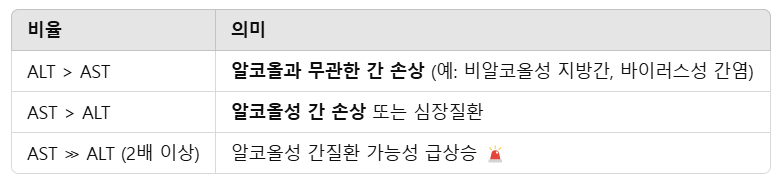
- 복부비만과 흡연 영향 파악
  - Waist/Height 비율
- 추가 비만 관련 변수
  - BMI 구간별 범주형 변수 (저체중/정상/과체중/비만)

In [10]:
# Feature Engineering
def feature_engineering(df):
    df['waist_height_ratio'] = df['waist(cm)'] / df['height(cm)']
    df['alt_ast_ratio'] = df['ALT'] / (df['AST'] + 0.001)
    bins = [0, 18.5, 24.9, 29.9, np.inf]
    labels = ['Underweight', 'Normal', 'Overweight', 'Obesity']
    df['BMI_category'] = pd.cut(df['BMI'], bins=bins, labels=labels)
    df = pd.get_dummies(df, columns=['BMI_category'], drop_first=True)
    return df

## 모델 별 - 모델링 + 성능평가 + 과적합 여부 확인

CatBoost

===== CatBoostClassifier =====
Fitting 2 folds for each of 8 candidates, totalling 16 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


최적 하이퍼파라미터: {'learning_rate': 0.1, 'iterations': 1100, 'depth': 10}
정확도: 0.7940
ROC-AUC: 0.8785
분류 보고서:
               precision    recall  f1-score   support

           0       0.85      0.82      0.83      4933
           1       0.71      0.74      0.73      2864

    accuracy                           0.79      7797
   macro avg       0.78      0.78      0.78      7797
weighted avg       0.80      0.79      0.79      7797



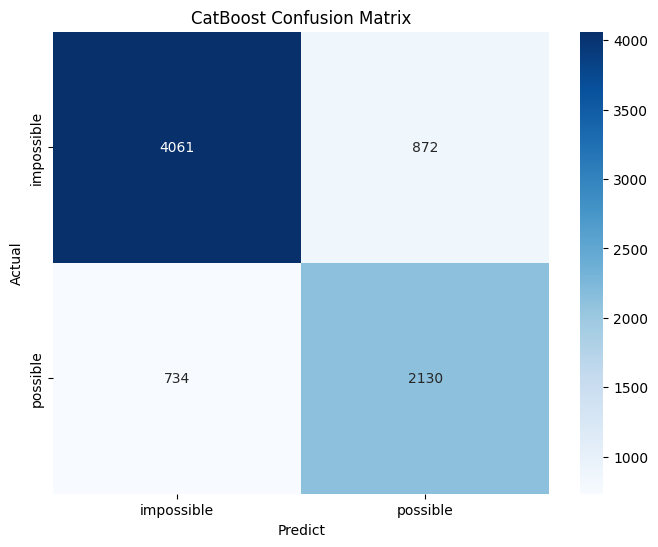


=== CatBoost Feature Importance ===
                    Feature  Importance
17         serum creatinine    8.373615
1                height(cm)    8.311453
15               hemoglobin    6.274393
0                       age    6.266889
20                      Gtp    5.997690
4            eyesight(left)    5.690480
5           eyesight(right)    4.418992
10      fasting blood sugar    4.171920
18                      AST    4.151359
25                 BP Ratio    4.085724
27            alt_ast_ratio    3.524590
8                  systolic    3.343643
12             triglyceride    3.254385
13                      HDL    3.127330
11              Cholesterol    3.051309
9                relaxation    2.870722
14                      LDL    2.859596
19                      ALT    2.745976
24                  LDL/HDL    2.680239
23         triglyceride/HDL    2.670458
26       waist_height_ratio    2.652470
3                 waist(cm)    2.577581
22                      BMI    2.524255
2  

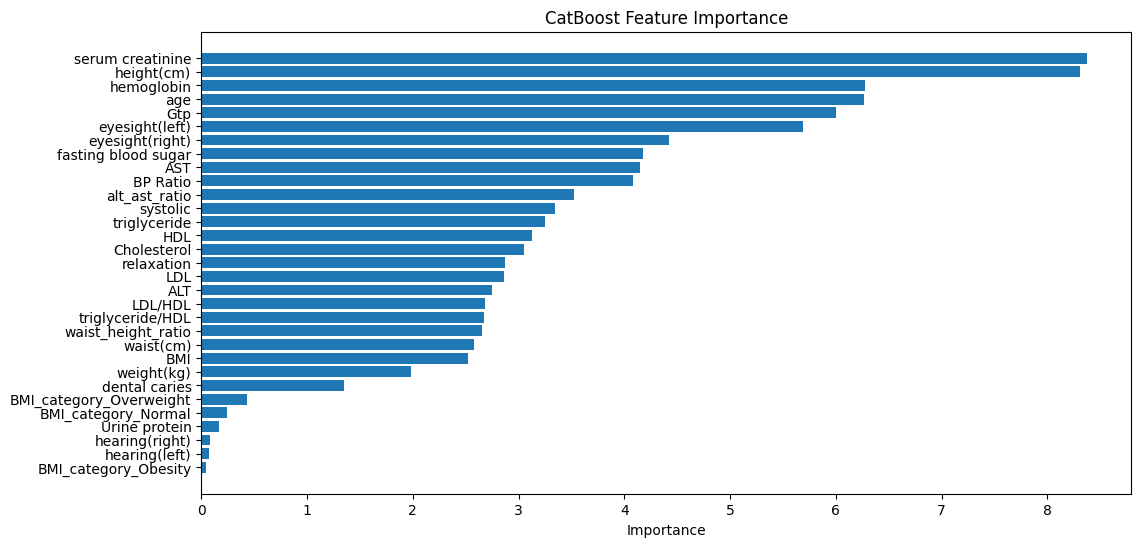

In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

# 타겟 변수 분리
y = train_df['smoking']
X = train_df.drop(columns=['smoking'])

# Feature Engineering 적용
X = feature_engineering(X)

# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 데이터 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE 적용
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# 모델 리스트
model = CatBoostClassifier(verbose=0, random_state=42)

# 하이퍼파라미터 그리드 정의
param_grids = {'iterations': [1100, 1150], 'learning_rate': [0.01, 0.1], 'depth': [6, 10]}

# 모델 학습 및 하이퍼파라미터 튜닝
print('===== CatBoostClassifier =====')

# RandomizedSearchCV 사용
random_search = RandomizedSearchCV(estimator=model, param_distributions=param_grids, n_iter=10,
                                   cv=2, n_jobs=-1, verbose=2, random_state=42)
random_search.fit(X_train_resampled, y_train_resampled)

print(f'최적 하이퍼파라미터: {random_search.best_params_}')

# 최적 모델로 예측
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test_scaled)

# 성능 평가
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, best_model.predict_proba(X_test_scaled)[:, 1]) if hasattr(model, 'predict_proba') else None

print(f'정확도: {accuracy:.4f}')
if roc_auc is not None:
    print(f'ROC-AUC: {roc_auc:.4f}')
print('분류 보고서:\n', classification_report(y_test, y_pred))

# 혼동 행렬 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred),
             annot=True, fmt='d', cmap='Blues',
             xticklabels=['impossible', 'possible'],
             yticklabels=['impossible', 'possible'])
plt.title('CatBoost Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predict')
plt.show()

# Feature Importance 시각화
feature_importance = best_model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print('\n=== CatBoost Feature Importance ===')
print(importance_df)

plt.figure(figsize=(12, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.gca().invert_yaxis()
plt.title('CatBoost Feature Importance')
plt.xlabel('Importance')
plt.show()

정확도가 미세하게 증가함.

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38984 entries, 0 to 38983
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      38984 non-null  int64  
 1   height(cm)               38984 non-null  int64  
 2   weight(kg)               38984 non-null  int64  
 3   waist(cm)                38984 non-null  float64
 4   eyesight(left)           38984 non-null  float64
 5   eyesight(right)          38984 non-null  float64
 6   hearing(left)            38984 non-null  int64  
 7   hearing(right)           38984 non-null  int64  
 8   systolic                 38984 non-null  int64  
 9   relaxation               38984 non-null  int64  
 10  fasting blood sugar      38984 non-null  int64  
 11  Cholesterol              38984 non-null  int64  
 12  triglyceride             38984 non-null  int64  
 13  HDL                      38984 non-null  int64  
 14  LDL                   

In [ ]:
model = CatBoostClassifier()
accuracy_cat = 0.7940

# 모델을 교차 검증하여 성능 평가
cv_scores = cross_val_score(model, X_train, y_train, cv=5) # 데이터를 5개의 폴드(fold)로 나누고 각 폴드에서 훈련과 검증을 반복하여 평균 성능을 계산
                                                           # cv_scores는 5번의 교차 검증에서 얻은 성능 점수가 저장됨

print("교차 검증 평균 성능:", cv_scores.mean())

# 훈련 데이터의 정확도가 교차 검증 성능보다 0.1 이상 높으면 과적합 가능성이 있다고 판단
if cv_scores.mean() < accuracy_cat - 0.1:
    print("과적합 가능성 있음")
else:
    print("과적합 아님")

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
6:	learn: 0.5959107	total: 83.4ms	remaining: 11.8s
7:	learn: 0.5864300	total: 95.3ms	remaining: 11.8s
8:	learn: 0.5783879	total: 107ms	remaining: 11.7s
9:	learn: 0.5708743	total: 120ms	remaining: 11.9s
10:	learn: 0.5644039	total: 132ms	remaining: 11.9s
11:	learn: 0.5582712	total: 143ms	remaining: 11.8s
12:	learn: 0.5529443	total: 155ms	remaining: 11.7s
13:	learn: 0.5478450	total: 166ms	remaining: 11.7s
14:	learn: 0.5436359	total: 179ms	remaining: 11.7s
15:	learn: 0.5394241	total: 191ms	remaining: 11.7s
16:	learn: 0.5352340	total: 205ms	remaining: 11.8s
17:	learn: 0.5318560	total: 216ms	remaining: 11.8s
18:	learn: 0.5284932	total: 228ms	remaining: 11.8s
19:	learn: 0.5258247	total: 240ms	remaining: 11.8s
20:	learn: 0.5230690	total: 252ms	remaining: 11.7s
21:	learn: 0.5203036	total: 263ms	remaining: 11.7s
22:	learn: 0.5179849	total: 275ms	remaining: 11.7s
23:	learn: 0.5160830	total: 286ms	remaining: 11.6s
24:	learn: 0.5140620	total: 298ms	remaining: 11.

CatBoost 추가 성능 개선 - 언더 샘플링(test)+오버 샘플링(train)

===== CatBoostClassifier =====
Fitting 2 folds for each of 8 candidates, totalling 16 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


최적 하이퍼파라미터: {'learning_rate': 0.1, 'iterations': 1200, 'depth': 10}
정확도: 0.7826
ROC-AUC: 0.8798
분류 보고서:
               precision    recall  f1-score   support

           0       0.76      0.82      0.79      2864
           1       0.81      0.74      0.77      2864

    accuracy                           0.78      5728
   macro avg       0.78      0.78      0.78      5728
weighted avg       0.78      0.78      0.78      5728



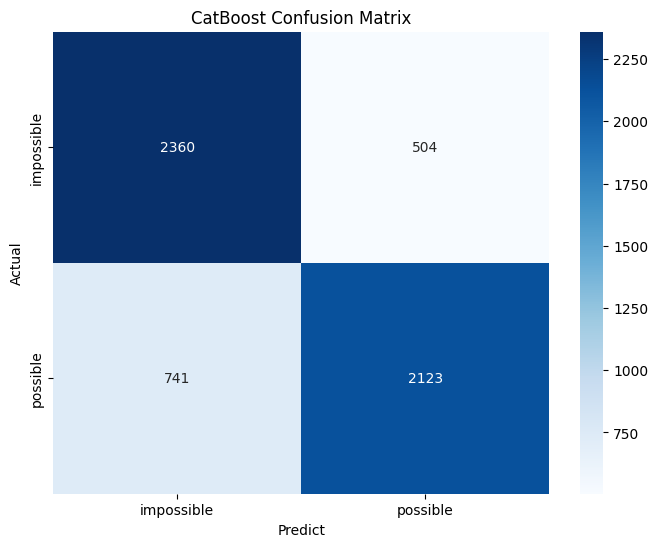


=== CatBoost Feature Importance ===
                    Feature  Importance
17         serum creatinine    8.272325
1                height(cm)    8.174902
15               hemoglobin    6.326577
0                       age    6.244269
20                      Gtp    5.993324
4            eyesight(left)    5.618081
5           eyesight(right)    4.389348
10      fasting blood sugar    4.211971
18                      AST    4.153372
25                 BP Ratio    4.117171
27            alt_ast_ratio    3.563029
8                  systolic    3.368925
12             triglyceride    3.258371
13                      HDL    3.149833
11              Cholesterol    3.066371
9                relaxation    2.900582
14                      LDL    2.896525
19                      ALT    2.744718
24                  LDL/HDL    2.720960
23         triglyceride/HDL    2.697708
26       waist_height_ratio    2.682284
3                 waist(cm)    2.593764
22                      BMI    2.531095
2  

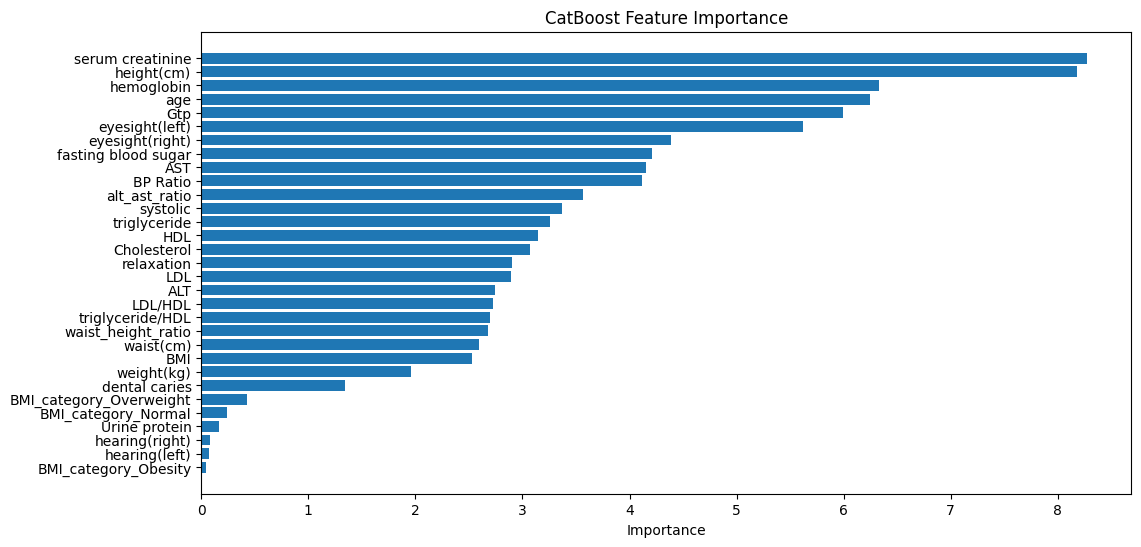

In [ ]:
from sklearn.utils import resample
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import RandomizedSearchCV

# 타겟 변수 분리
y = train_df['smoking']
X = train_df.drop(columns=['smoking'])

# Feature Engineering 적용
X = feature_engineering(X)

# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 데이터 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE 적용
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# 테스트 데이터에서 클래스 균형 맞추기 (언더샘플링)
non_smoking = X_test_scaled[y_test == 0]
smoking = X_test_scaled[y_test == 1]
y_non_smoking = y_test[y_test == 0]
y_smoking = y_test[y_test == 1]

non_smoking_downsampled, y_non_smoking_downsampled = resample(non_smoking, y_non_smoking,
                                                              replace=False,
                                                              n_samples=len(y_smoking),
                                                              random_state=42)

X_test_resampled = np.vstack((non_smoking_downsampled, smoking))
y_test_resampled = np.hstack((y_non_smoking_downsampled, y_smoking))

# 모델 리스트
model = CatBoostClassifier(verbose=0, random_state=42)

# 하이퍼파라미터 그리드 정의
param_grids = {'iterations': [1150, 1200], 'learning_rate': [0.01, 0.1], 'depth': [6, 10]}

# 모델 학습 및 하이퍼파라미터 튜닝
print('===== CatBoostClassifier =====')

# RandomizedSearchCV 사용
random_search = RandomizedSearchCV(estimator=model, param_distributions=param_grids, n_iter=10,
                                   cv=2, n_jobs=-1, verbose=2, random_state=42)
random_search.fit(X_train_resampled, y_train_resampled)

print(f'최적 하이퍼파라미터: {random_search.best_params_}')

# 최적 모델로 예측
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test_resampled)

# 성능 평가
accuracy = accuracy_score(y_test_resampled, y_pred)
roc_auc = roc_auc_score(y_test_resampled, best_model.predict_proba(X_test_resampled)[:, 1]) if hasattr(model, 'predict_proba') else None

print(f'정확도: {accuracy:.4f}')
if roc_auc is not None:
    print(f'ROC-AUC: {roc_auc:.4f}')
print('분류 보고서:\n', classification_report(y_test_resampled, y_pred))

# 혼동 행렬 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_resampled, y_pred),
             annot=True, fmt='d', cmap='Blues',
             xticklabels=['impossible', 'possible'],
             yticklabels=['impossible', 'possible'])
plt.title('CatBoost Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predict')
plt.show()

# Feature Importance 시각화
feature_importance = best_model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print('\n=== CatBoost Feature Importance ===')
print(importance_df)

plt.figure(figsize=(12, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.gca().invert_yaxis()
plt.title('CatBoost Feature Importance')
plt.xlabel('Importance')
plt.show()

In [ ]:
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score

model = CatBoostClassifier()
accuracy_cat = 0.7826

# 모델을 교차 검증하여 성능 평가
cv_scores = cross_val_score(model, X_train, y_train, cv=5) # 데이터를 5개의 폴드(fold)로 나누고 각 폴드에서 훈련과 검증을 반복하여 평균 성능을 계산
                                                           # cv_scores는 5번의 교차 검증에서 얻은 성능 점수가 저장됨

print("교차 검증 평균 성능:", cv_scores.mean())

# 훈련 데이터의 정확도가 교차 검증 성능보다 0.1 이상 높으면 과적합 가능성이 있다고 판단
if cv_scores.mean() < accuracy_cat - 0.1:
    print("과적합 가능성 있음")
else:
    print("과적합 아님")

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
6:	learn: 0.5959107	total: 261ms	remaining: 37.1s
7:	learn: 0.5864300	total: 306ms	remaining: 37.9s
8:	learn: 0.5783879	total: 362ms	remaining: 39.9s
9:	learn: 0.5708743	total: 411ms	remaining: 40.7s
10:	learn: 0.5644039	total: 459ms	remaining: 41.3s
11:	learn: 0.5582712	total: 513ms	remaining: 42.3s
12:	learn: 0.5529443	total: 559ms	remaining: 42.4s
13:	learn: 0.5478450	total: 606ms	remaining: 42.7s
14:	learn: 0.5436359	total: 653ms	remaining: 42.9s
15:	learn: 0.5394241	total: 704ms	remaining: 43.3s
16:	learn: 0.5352340	total: 743ms	remaining: 43s
17:	learn: 0.5318560	total: 772ms	remaining: 42.1s
18:	learn: 0.5284932	total: 811ms	remaining: 41.9s
19:	learn: 0.5258247	total: 853ms	remaining: 41.8s
20:	learn: 0.5230690	total: 887ms	remaining: 41.3s
21:	learn: 0.5203036	total: 929ms	remaining: 41.3s
22:	learn: 0.5179849	total: 969ms	remaining: 41.2s
23:	learn: 0.5160830	total: 1.02s	remaining: 41.7s
24:	learn: 0.5140620	total: 1.07s	remaining: 41.8s
2

오버 샘플링 + 파라미터 튜닝 + 추가 파생 변수까지 했을 때
- accuracy : 0.7940
- recall : 0.82(0)/0.74(1)
- precision : 0.85(0)/0.71(1)
- 교차 검증 성능 : 0.7695

언더 샘플링도 추가했을 때
- accuracy : 0.7826
- recall : 0.82(0)/0.74(1)
- precision : 0.76(0)/0.81(1)
- 교차 검증 성능 : 0.7695

위 두 모델을 비교했을 때,

언더 샘플링까지 한 모델이 정확도는 낮고, recall 값과 교차 검증 성능값은 동일하다.

하지만 언더 샘플링을 추가한 모델이 1의 precision 값이 월등히 높다. 우리는 흡연 예측 모델을 생성하는 것이 목표이기에 CatBoost 모델은 언더 샘플링까지 한 것이 최선의 성능 개선 방법이라고 결정하였다.



---


XGBoost

데이터 스케일링, SMOTE을 적용하니 오히려 정확도가 0.6328까지 감소하여,

해당 과정은 생략하였다.

===== XGBoostClassifier =====
정확도: 0.7809
ROC-AUC: 0.8603
분류 보고서:
               precision    recall  f1-score   support

           0       0.83      0.83      0.83      4933
           1       0.70      0.70      0.70      2864

    accuracy                           0.78      7797
   macro avg       0.76      0.76      0.76      7797
weighted avg       0.78      0.78      0.78      7797



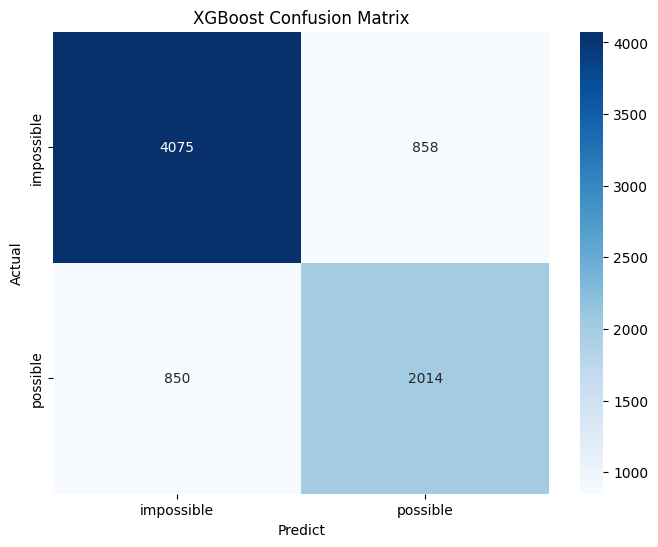


=== XGBoost Feature Importance ===
                    Feature  Importance
1                height(cm)    0.247185
15               hemoglobin    0.070969
20                      Gtp    0.055712
21            dental caries    0.036024
0                       age    0.034991
17         serum creatinine    0.031398
12             triglyceride    0.024663
7            hearing(right)    0.024554
23         triglyceride/HDL    0.024266
19                      ALT    0.023282
22                      BMI    0.022870
13                      HDL    0.022007
14                      LDL    0.021820
24                  LDL/HDL    0.021770
18                      AST    0.021517
6             hearing(left)    0.021402
29  BMI_category_Overweight    0.021386
26       waist_height_ratio    0.021377
11              Cholesterol    0.021110
27            alt_ast_ratio    0.020932
2                weight(kg)    0.020721
10      fasting blood sugar    0.020655
8                  systolic    0.020529
28  

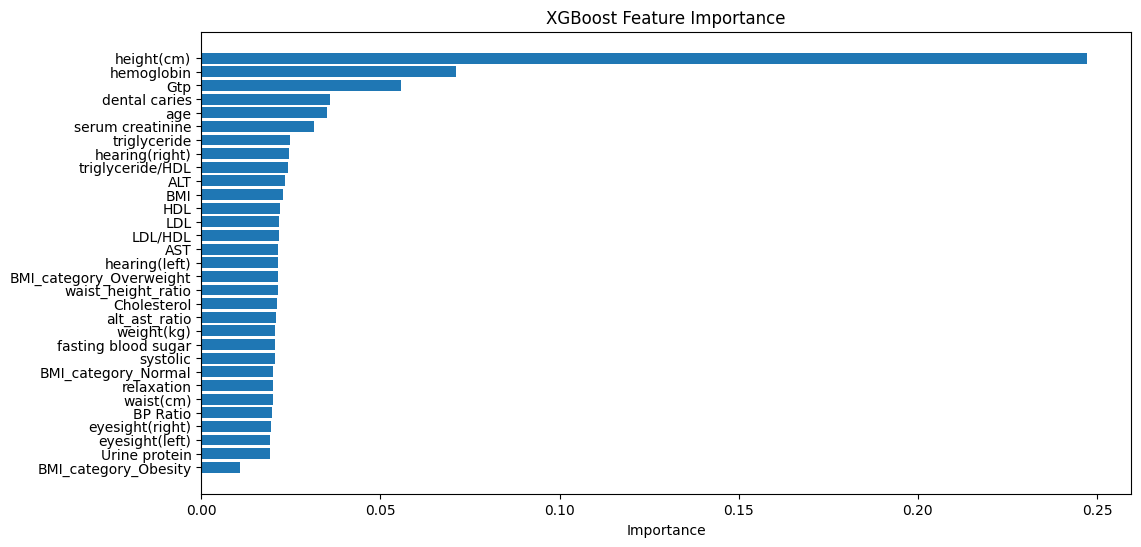

In [ ]:
# 타겟 변수 분리
y = train_df['smoking']
X = train_df.drop(columns=['smoking'])

# Feature Engineering 적용
X = feature_engineering(X)

# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# XGBoost 모델 생성
xgb_model = xgb.XGBClassifier(
    n_estimators=1000,  # 트리 개수
    learning_rate=0.05,  # 학습률
    max_depth=6,  # 트리 깊이
    colsample_bytree=0.8,  # 트리별 샘플링 비율
    subsample=0.8,  # 데이터 샘플링 비율
    random_state=42
)

# 모델 학습
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
y_pred = xgb_model.predict(X_test)

# 성능 평가
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1]) if hasattr(xgb_model, 'predict_proba') else None

print('===== XGBoostClassifier =====')
print(f'정확도: {accuracy:.4f}')
if roc_auc is not None:
    print(f'ROC-AUC: {roc_auc:.4f}')
print('분류 보고서:\n', classification_report(y_test, y_pred))

# 혼동 행렬 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred),
             annot=True, fmt='d', cmap='Blues',
             xticklabels=['impossible', 'possible'],
             yticklabels=['impossible', 'possible'])
plt.title('XGBoost Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predict')
plt.show()

# Feature Importance 시각화
feature_importance = xgb_model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print('\n=== XGBoost Feature Importance ===')
print(importance_df)

plt.figure(figsize=(12, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.gca().invert_yaxis()
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance')
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier

model = XGBClassifier()
accuracy_cat = 0.7809

# 모델을 교차 검증하여 성능 평가
cv_scores = cross_val_score(model, X_train, y_train, cv=5) # 데이터를 5개의 폴드(fold)로 나누고 각 폴드에서 훈련과 검증을 반복하여 평균 성능을 계산
                                                           # cv_scores는 5번의 교차 검증에서 얻은 성능 점수가 저장됨

print("교차 검증 평균 성능:", cv_scores.mean())

# 훈련 데이터의 정확도가 교차 검증 성능보다 0.1 이상 높으면 과적합 가능성이 있다고 판단
if cv_scores.mean() < accuracy_cat - 0.1:
    print("과적합 가능성 있음")
else:
    print("과적합 아님")

교차 검증 평균 성능: 0.7699360717101447
과적합 아님


Feature Importance를 보았을 때, ‘height’ 하나만 유독 값이 높게 나옴.
즉, height에 과도하게 의존하는 경향을 보임.

CatBoost와 비교했을 때,
흡연자(1)에 대한 성능값이 더 낮게 나타남.

따라서 **XGBoost를 사용하지 않기**로 결정하였다.



---


LightGBM

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 19733, number of negative: 19733
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013934 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6306
[LightGBM] [Info] Number of data points in the train set: 39466, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spli

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


===== LightGBM =====
정확도: 0.7795
ROC-AUC: 0.5125
분류 보고서:
               precision    recall  f1-score   support

           0       0.84      0.81      0.82      4933
           1       0.69      0.73      0.71      2864

    accuracy                           0.78      7797
   macro avg       0.76      0.77      0.77      7797
weighted avg       0.78      0.78      0.78      7797



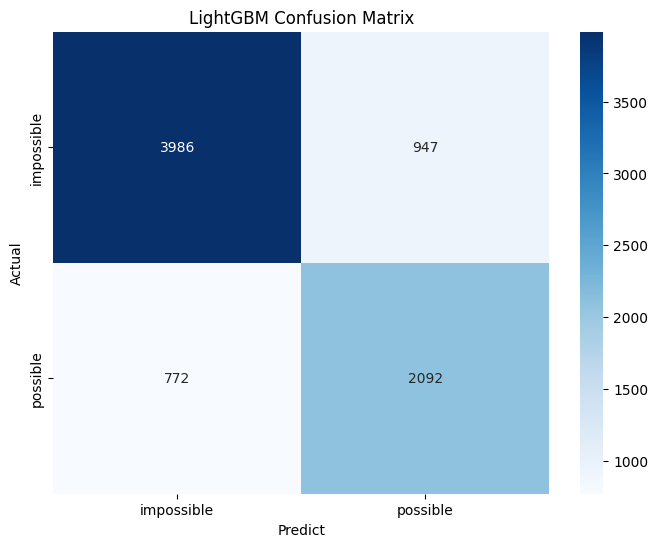


=== LightGBM Feature Importance ===
                    Feature  Importance
20                      Gtp        1698
25                 BP Ratio        1635
15               hemoglobin        1630
27            alt_ast_ratio        1596
10      fasting blood sugar        1494
12             triglyceride        1456
11              Cholesterol        1416
24                  LDL/HDL        1402
26       waist_height_ratio        1305
14                      LDL        1277
13                      HDL        1255
23         triglyceride/HDL        1252
18                      AST        1252
0                       age        1228
8                  systolic        1160
19                      ALT        1160
3                 waist(cm)        1155
17         serum creatinine        1049
22                      BMI        1024
1                height(cm)        1009
9                relaxation         997
4            eyesight(left)         768
5           eyesight(right)         762
2  

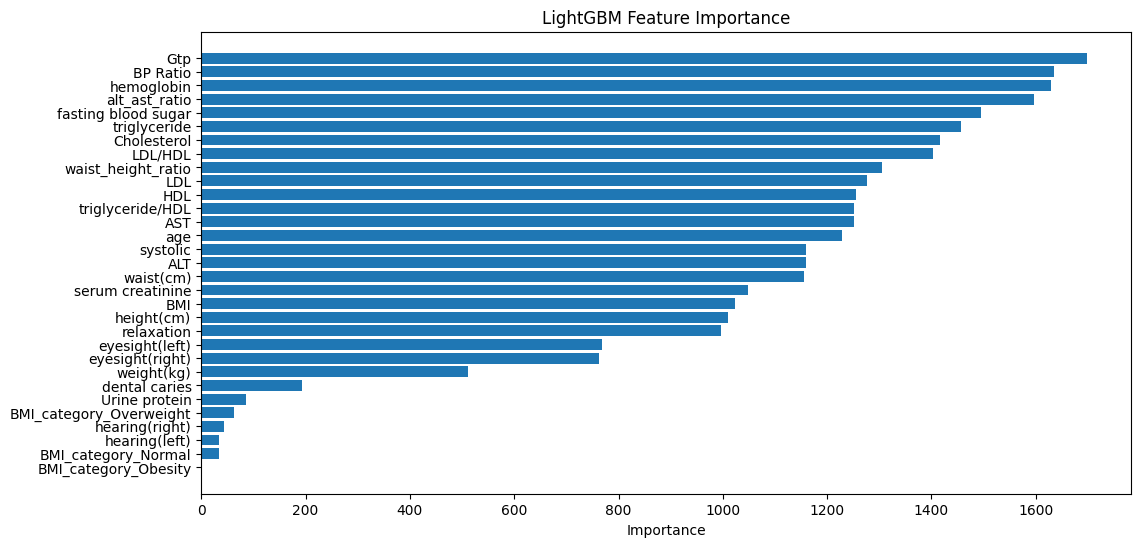

In [ ]:
# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 데이터 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE 적용
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# LightGBM 모델 생성
lgb_model = lgb.LGBMClassifier(
    n_estimators=1000,            # 트리의 개수
    learning_rate=0.05,           # 학습률
    max_depth=8,                  # 트리의 최대 깊이
    colsample_bytree=0.8,         # 트리별 특성 샘플링 비율
    subsample=0.8,                # 샘플링 비율
    random_state=42               # 랜덤 시드
)

# 모델 학습
lgb_model.fit(X_train_resampled, y_train_resampled, eval_set=[(X_test_scaled, y_test)])

# 예측
y_pred = lgb_model.predict(X_test_scaled)

# 성능 평가
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, lgb_model.predict_proba(X_test)[:, 1]) if hasattr(lgb_model, 'predict_proba') else None

name = 'LightGBM'

print(f'===== {name} =====')
print(f'정확도: {accuracy:.4f}')
if roc_auc is not None:
    print(f'ROC-AUC: {roc_auc:.4f}')
print('분류 보고서:\n', classification_report(y_test, y_pred))

# 혼동 행렬 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred),
             annot=True, fmt='d', cmap='Blues',
             xticklabels=['impossible', 'possible'],
             yticklabels=['impossible', 'possible'])
plt.title(f'{name} Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predict')
plt.show()

# Feature Importance 시각화
feature_importance = lgb_model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(f'\n=== {name} Feature Importance ===')
print(importance_df)

plt.figure(figsize=(12, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.gca().invert_yaxis()
plt.title(f'{name} Feature Importance')
plt.xlabel('Importance')
plt.show()

In [ ]:
from lightgbm import LGBMClassifier

model = LGBMClassifier()
accuracy_cat = 0.7795

# 모델을 교차 검증하여 성능 평가
cv_scores = cross_val_score(model, X_train, y_train, cv=5) # 데이터를 5개의 폴드(fold)로 나누고 각 폴드에서 훈련과 검증을 반복하여 평균 성능을 계산
                                                           # cv_scores는 5번의 교차 검증에서 얻은 성능 점수가 저장됨

print("교차 검증 평균 성능:", cv_scores.mean())

# 훈련 데이터의 정확도가 교차 검증 성능보다 0.1 이상 높으면 과적합 가능성이 있다고 판단
if cv_scores.mean() < accuracy_cat - 0.1:
    print("과적합 가능성 있음")
else:
    print("과적합 아님")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 9163, number of negative: 15786
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006296 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3678
[LightGBM] [Info] Number of data points in the train set: 24949, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.367269 -> initscore=-0.543950
[LightGBM] [Info] Start training from score -0.543950
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 9163, number of negative: 15786
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012376 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col

LightGBM 또한 XGBoost와 마찬가지로 튜닝한 것이 기존보다 낮은 정확도를 가진다.

처음 파생 변수를 적용했을 때보다 추가 파생 변수를 적용한 것이 정확도가 더 높았지만, 기존 모델링에 비해서는 낮다.

LightGBM은 다른 모델과 달리 ROC-AUC 값이 0.5125로 상당히 낮은 값을 보인다. 여기서 ROC-AUC는 분류 모델의 예측 확률이 얼마나 잘 구분되는지 측정하는 지표이다. 이는 1에 가까울수록 성능이 좋다는 것인데, 현재 모델은 상당히 낮기에 성능이 좋지 않다는 것을 의미한다.

따라서 **LightGBM 모델을 최종 모델로 사용하지 않기**로 결정하였다.



---


RandomForest

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


===== RandomForest =====
정확도: 0.7924
ROC-AUC: 0.3965
분류 보고서:
               precision    recall  f1-score   support

           0       0.87      0.79      0.83      4933
           1       0.69      0.79      0.74      2864

    accuracy                           0.79      7797
   macro avg       0.78      0.79      0.78      7797
weighted avg       0.80      0.79      0.79      7797



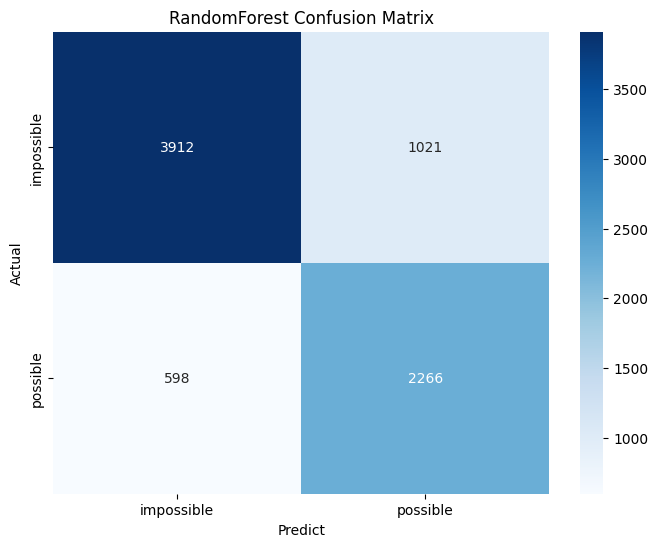


=== RandomForest Feature Importance ===
                    Feature  Importance
1                height(cm)    0.125353
15               hemoglobin    0.098762
20                      Gtp    0.079562
17         serum creatinine    0.046114
23         triglyceride/HDL    0.042829
12             triglyceride    0.042265
2                weight(kg)    0.039015
0                       age    0.036681
27            alt_ast_ratio    0.036151
19                      ALT    0.033442
3                 waist(cm)    0.033316
25                 BP Ratio    0.031505
26       waist_height_ratio    0.031262
10      fasting blood sugar    0.030672
13                      HDL    0.030667
11              Cholesterol    0.030621
24                  LDL/HDL    0.029842
14                      LDL    0.029719
18                      AST    0.029081
8                  systolic    0.028965
9                relaxation    0.026777
22                      BMI    0.025985
4            eyesight(left)    0.022053

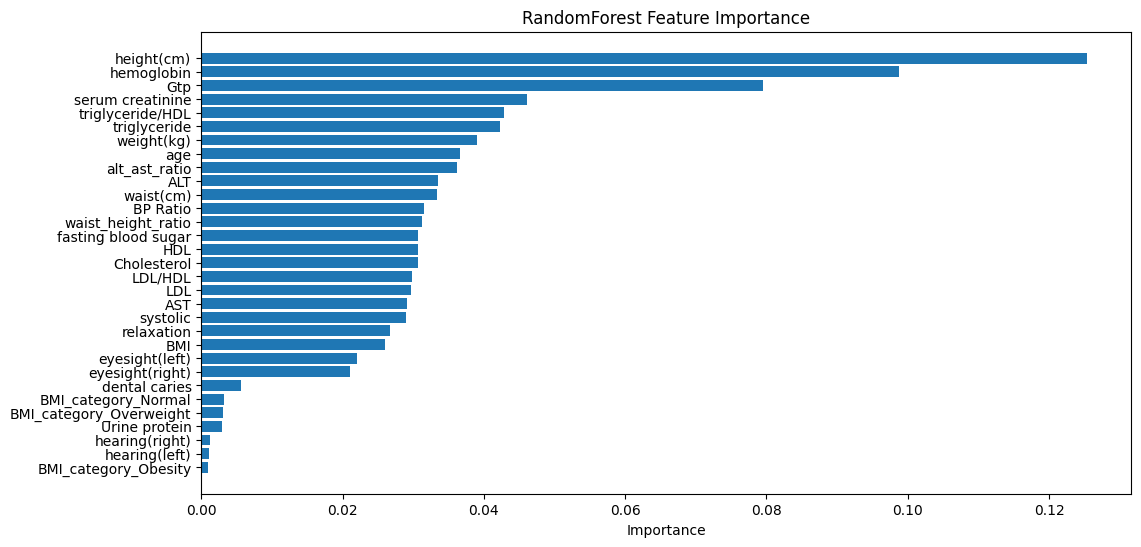

In [ ]:
# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 데이터 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE 적용
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# 모델 생성
model = RandomForestClassifier(random_state=42, n_estimators=100)

# 모델 학습 및 평가
metrics = []

model.fit(X_train_resampled, y_train_resampled)  # 모델 학습
y_pred = model.predict(X_test_scaled)  # 예측

# 성능 평가
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]) if hasattr(model, 'predict_proba') else None

name = 'RandomForest'

print(f'===== {name} =====')
print(f'정확도: {accuracy:.4f}')
if roc_auc is not None:
    print(f'ROC-AUC: {roc_auc:.4f}')
print('분류 보고서:\n', classification_report(y_test, y_pred))

# 혼동 행렬 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred),
             annot=True, fmt='d', cmap='Blues',
             xticklabels=['impossible', 'possible'],
             yticklabels=['impossible', 'possible'])
plt.title(f'{name} Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predict')
plt.show()

# Feature Importance 시각화
feature_importance = model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(f'\n=== {name} Feature Importance ===')
print(importance_df)

plt.figure(figsize=(12, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.gca().invert_yaxis()
plt.title(f'{name} Feature Importance')
plt.xlabel('Importance')
plt.show()

In [ ]:
model = RandomForestClassifier()
accuracy_cat = 0.7924

# 모델을 교차 검증하여 성능 평가
cv_scores = cross_val_score(model, X_train, y_train, cv=5) # 데이터를 5개의 폴드(fold)로 나누고 각 폴드에서 훈련과 검증을 반복하여 평균 성능을 계산
                                                           # cv_scores는 5번의 교차 검증에서 얻은 성능 점수가 저장됨

print("교차 검증 평균 성능:", cv_scores.mean())

# 훈련 데이터의 정확도가 교차 검증 성능보다 0.1 이상 높으면 과적합 가능성이 있다고 판단
if cv_scores.mean() < accuracy_cat - 0.1:
    print("과적합 가능성 있음")
else:
    print("과적합 아님")

교차 검증 평균 성능: 0.7896878421512386
과적합 아님


RandomForest 모델은 성능 개선을 할수록 정확도 값이 감소한다.

또한 LightGBM과 마찬가지로 ROC-AUC 값이 0.3965로 상당히 낮은 값을 가지기에 해당 모델은 사용하지 않은 것이 좋을 듯 하다.



---

ExtraTrees

ExtraTrees에서는 학습할 때 bool 타입이 있으면 에러가 난다.

===== ExtraTrees =====
정확도: 0.7891
ROC-AUC: 0.8850
분류 보고서:
               precision    recall  f1-score   support

           0       0.87      0.78      0.82      4933
           1       0.68      0.81      0.74      2864

    accuracy                           0.79      7797
   macro avg       0.78      0.79      0.78      7797
weighted avg       0.80      0.79      0.79      7797



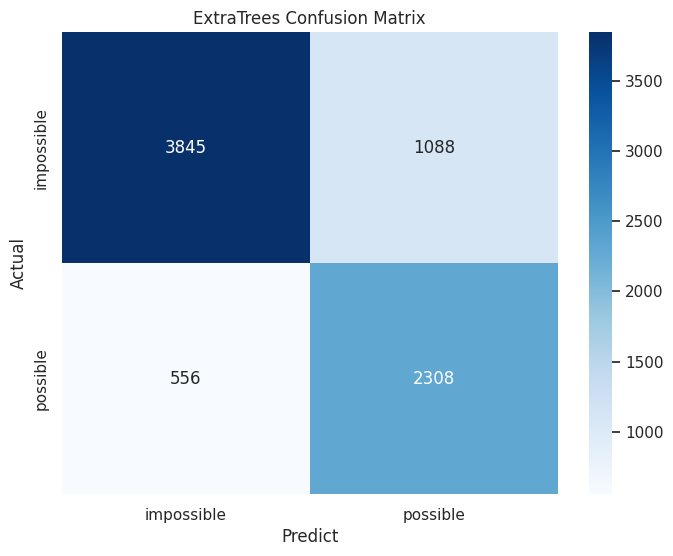


=== ExtraTrees Feature Importance ===
                    Feature  Importance
1                height(cm)    0.159058
15               hemoglobin    0.114351
20                      Gtp    0.058052
2                weight(kg)    0.057783
0                       age    0.047619
12             triglyceride    0.041436
17         serum creatinine    0.040585
23         triglyceride/HDL    0.038953
3                 waist(cm)    0.031971
13                      HDL    0.027306
27            alt_ast_ratio    0.025654
25                 BP Ratio    0.025304
8                  systolic    0.025233
11              Cholesterol    0.024812
4            eyesight(left)    0.024769
9                relaxation    0.024644
5           eyesight(right)    0.024631
22                      BMI    0.024238
10      fasting blood sugar    0.023984
26       waist_height_ratio    0.023975
14                      LDL    0.023506
19                      ALT    0.023159
18                      AST    0.023111
2

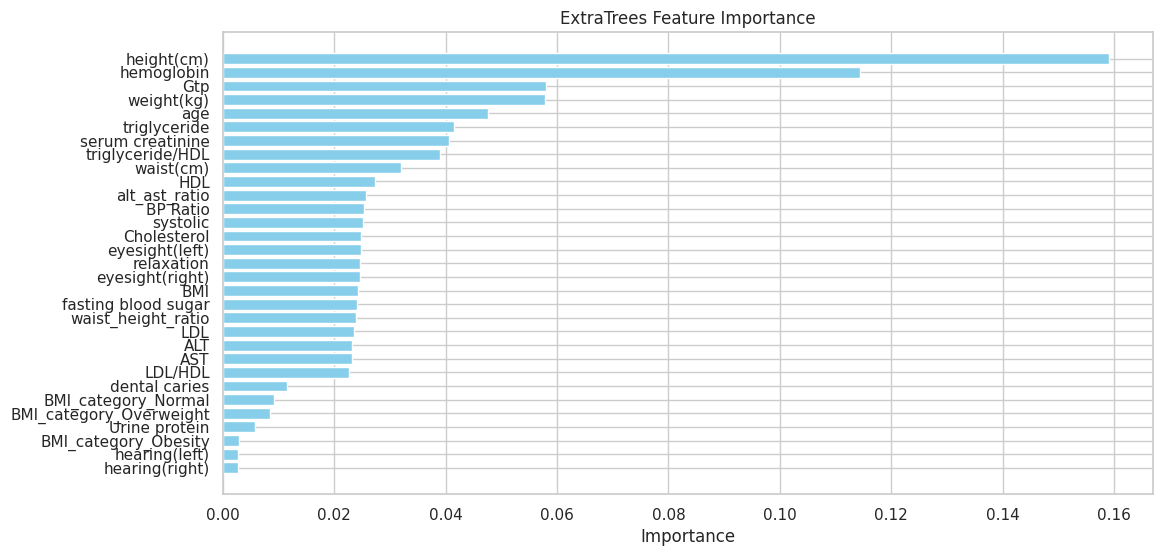

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 타겟 변수 분리
y = train_df['smoking']
X = train_df.drop(columns=['smoking'])

# Feature Engineering 적용
X = feature_engineering(X)

# 범주형 변수 Label Encoding
categorical_cols = X.select_dtypes(include=['object']).columns

if len(categorical_cols) > 0:
    le = LabelEncoder()
    for col in categorical_cols:
        X[col] = le.fit_transform(X[col])

# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 데이터 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE 적용
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# ExtraTrees 모델 학습
et_model = ExtraTreesClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=3,
    min_samples_leaf=2,
    max_features=0.5,
    bootstrap=False,
    random_state=42
)

et_model.fit(X_train_resampled, y_train_resampled)
y_pred = et_model.predict(X_test_scaled)

# 성능 평가
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, et_model.predict_proba(X_test_scaled)[:, 1]) if hasattr(et_model, 'predict_proba') else None

name = 'ExtraTrees'

print(f'===== {name} =====')
print(f'정확도: {accuracy:.4f}')
if roc_auc is not None:
    print(f'ROC-AUC: {roc_auc:.4f}')
print('분류 보고서:\n', classification_report(y_test, y_pred))

# 혼동 행렬 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['impossible', 'possible'],
            yticklabels=['impossible', 'possible'])
plt.title(f'{name} Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predict')
plt.show()

# Feature Importance 시각화
feature_importance = et_model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(f'\n=== {name} Feature Importance ===')
print(importance_df)

plt.figure(figsize=(12, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.gca().invert_yaxis()
plt.title(f'{name} Feature Importance')
plt.xlabel('Importance')
plt.show()

In [ ]:
model = ExtraTreesClassifier()
accuracy_cat = 0.7891

# 모델을 교차 검증하여 성능 평가
cv_scores = cross_val_score(model, X_train, y_train, cv=5) # 데이터를 5개의 폴드(fold)로 나누고 각 폴드에서 훈련과 검증을 반복하여 평균 성능을 계산
                                                           # cv_scores는 5번의 교차 검증에서 얻은 성능 점수가 저장됨

print("교차 검증 평균 성능:", cv_scores.mean())

# 훈련 데이터의 정확도가 교차 검증 성능보다 0.1 이상 높으면 과적합 가능성이 있다고 판단
if cv_scores.mean() < accuracy_cat - 0.1:
    print("과적합 가능성 있음")
else:
    print("과적합 아님")

교차 검증 평균 성능: 0.7830185137121121
과적합 아님


ExtraTrees 모델 또한 성능 개선을 진행할수록 정확도 값이 감소한다.

## 파생 변수별 분포 확인 및 t-검정

<ipython-input-11-9993003b7731>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_df, x='smoking', y=feature, palette='Set2')
<ipython-input-11-9993003b7731>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_df, x='smoking', y=feature, palette='Set2')
<ipython-input-11-9993003b7731>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_df, x='smoking', y=feature, palette='Set2')
<ipython-input-11-9993003b7731>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. A

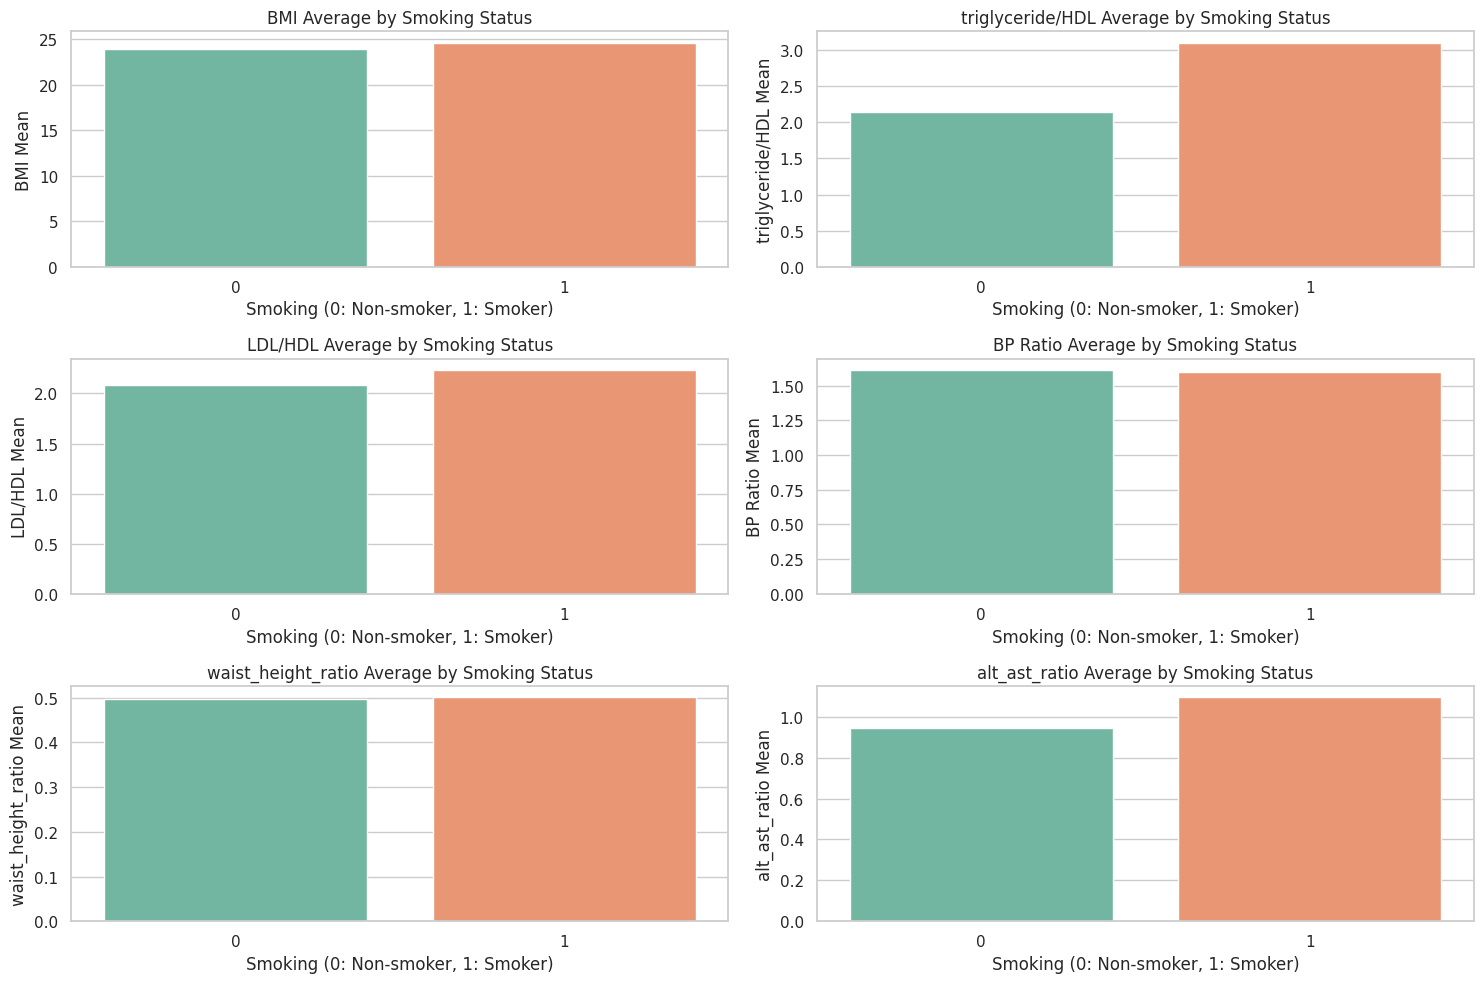

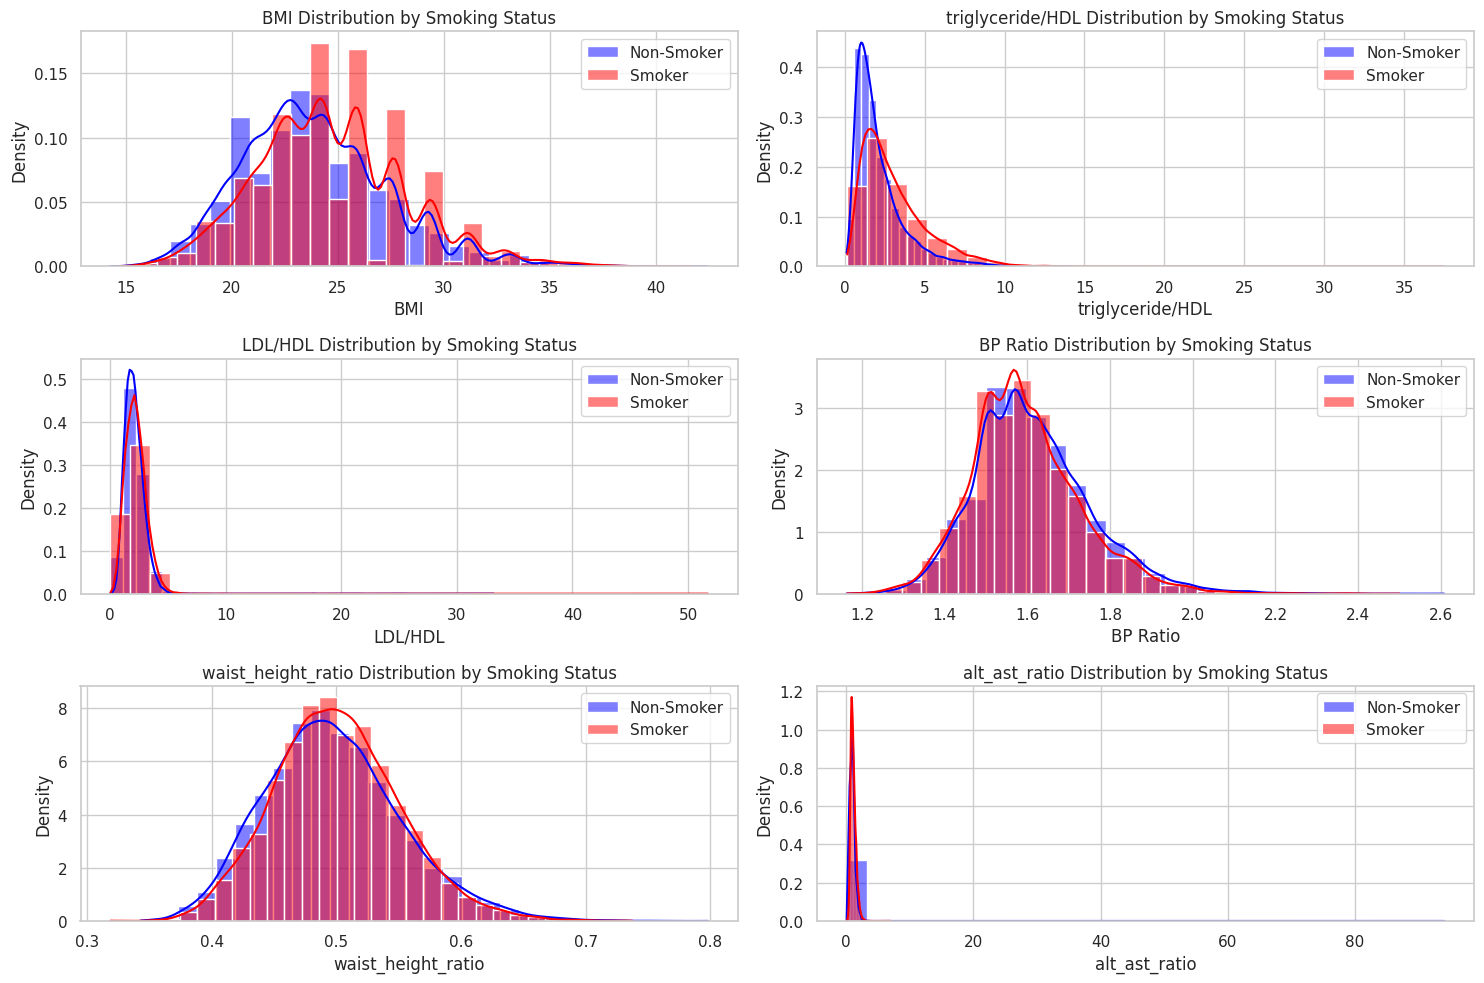

In [11]:
feature_engineering(train_df)

# 그래프 스타일 설정
sns.set(style='whitegrid')

# 파생 변수 리스트
features = ['BMI', 'triglyceride/HDL', 'LDL/HDL', 'BP Ratio', 'waist_height_ratio', 'alt_ast_ratio']

# 막대그래프: 평균 비교
def plot_bar_avg(df, features):
    plt.figure(figsize=(15, 10))
    for i, feature in enumerate(features, 1):
        plt.subplot(3, 2, i)
        avg_df = df.groupby('smoking')[feature].mean().reset_index()
        sns.barplot(data=avg_df, x='smoking', y=feature, palette='Set2')
        plt.title(f'{feature} Average by Smoking Status')
        plt.xlabel('Smoking (0: Non-smoker, 1: Smoker)')
        plt.ylabel(f'{feature} Mean')
    plt.tight_layout()
    plt.show()

# 히스토그램: 분포 비교
def plot_hist_distribution(df, features):
    plt.figure(figsize=(15, 10))
    for i, feature in enumerate(features, 1):
        plt.subplot(3, 2, i)
        sns.histplot(df[df['smoking'] == 0][feature], color='blue', label='Non-Smoker', kde=True, bins=30, stat='density')
        sns.histplot(df[df['smoking'] == 1][feature], color='red', label='Smoker', kde=True, bins=30, stat='density')
        plt.title(f'{feature} Distribution by Smoking Status')
        plt.xlabel(feature)
        plt.legend()
    plt.tight_layout()
    plt.show()

# 그래프 호출
plot_bar_avg(train_df, features)
plot_hist_distribution(train_df, features)

In [12]:
# t-검정을 위한 features 리스트
features = ['BMI', 'triglyceride/HDL', 'LDL/HDL', 'BP Ratio', 'waist_height_ratio', 'alt_ast_ratio']

# 흡연자와 비흡연자의 차이를 비교
for feature in features:
    smokers_data = train_df[train_df['smoking'] == 1][feature]
    non_smokers_data = train_df[train_df['smoking'] == 0][feature]

    # t-검정
    t_stat, p_val = stats.ttest_ind(smokers_data, non_smokers_data)

    print(f"{feature} - t-검정 결과: t-통계량 = {t_stat}, p-값 = {p_val}")

BMI - t-검정 결과: t-통계량 = 20.944315839728542, p-값 = 7.236416267883566e-97
triglyceride/HDL - t-검정 결과: t-통계량 = 50.9516005767229, p-값 = 0.0
LDL/HDL - t-검정 결과: t-통계량 = 14.144253563663755, p-값 = 2.623995807616444e-45
BP Ratio - t-검정 결과: t-통계량 = -12.292366953200286, p-값 = 1.1542440180803325e-34
waist_height_ratio - t-검정 결과: t-통계량 = 5.7896177663215465, p-값 = 7.108683647727204e-09
alt_ast_ratio - t-검정 결과: t-통계량 = 23.878893518203327, p-값 = 4.031327929094795e-125


'triglyceride/HDL'와 'alt_ast_ratio'를 제외하고는 비흡연자와 흡연자의 평균이 차이가 거의 없다.

하지만 히스토그램을 봤을 때는, 비흡연자와 흡연자의 분포 차이가 명확함을 알 수 있다.

또한 t-검정 결과 6개의 파생 변수들의 p-value 값이 0.05보다 낮기에 귀무가설(유의미한 관계가 없다.)이 기각된다.

따라서 파생 변수가 유의미하다고 결론지을 수 있다.

# 최종 결론

지금까지 5개의 모델을 이용하여 모델링을 진행하였다.

XGBoost에서는 Feature Importance를 보았을 때, 특정 변수 height 하나만 유독 값이 높게 나오기에 적합한 모델로 보기 어렵다. 또한 CatBoost와 비교했을 때,
흡연자(1)에 대한 성능값이 더 낮게 나타남.

LightGBM와 RandomForest는 ROC-AUC 값이 0.5125, 0.3965로 상당히 낮은 값을 보이기에 이 또한 적합한 모델이라고 보기는 어렵다.



따라서 5개 모델 중 최종 모델로 선정하기 적합한 모델은 **CatBoost, ExtraTrees**이다.


각 모델에서의 최고 성능 수치를 비교하자면, ExtraTrees가 정확도가 0.8007로 가장 높았다.

하지만 해당 모델은 Feature Engineering을 적용할수록 정확도가 감소하였다. 즉, 하이퍼파라미터 튜닝을 한 모델링 코드를 이용했을 때가 성능이 가장 좋다는 의미이다.

우리는 파생 변수를 추가할수록 성능이 감소하는 모델이 과연 적합한가에 대해 의문을 가지게 되었다. 결과적으로, 성능 개선 작업을 적용할수록 성능이 감소하는 경향을 보이는 것은 실무 적용 모델로 사용하기에는 한계가 있다고 판단하였다.

주요 이유는, **1의 precision 값이 0.68로** CatBoost의 0.81에 비해 현저히 **낮다**는 것이다. CatBoost의 적절한 모델링을 선정하는 과정에서 이야기했듯이 우리는 흡연 예측 모델을 목표로 하기에 **1의 precision 값이 높은 모델을 선정**하는 것이 좋다.

결론은 precision, 개선 가능성을 이유로 ExtraTrees 모델을 최종 모델로 사용하지 않기로 결정하였다.

따라서 **CatBoost를 최종 모델로 선택**하였다.

추가적으로, 최종 결론 과정을 한 눈에 볼 수 있도록

추가 파생 변수까지 적용한 각 모델 별 정확도와 교차 검증 평균 성능, ROU_AUC, precision(1)을 막대 그래프로 나타내어 보았다.



---

**최종 선택 모델 : CatBoost**

---




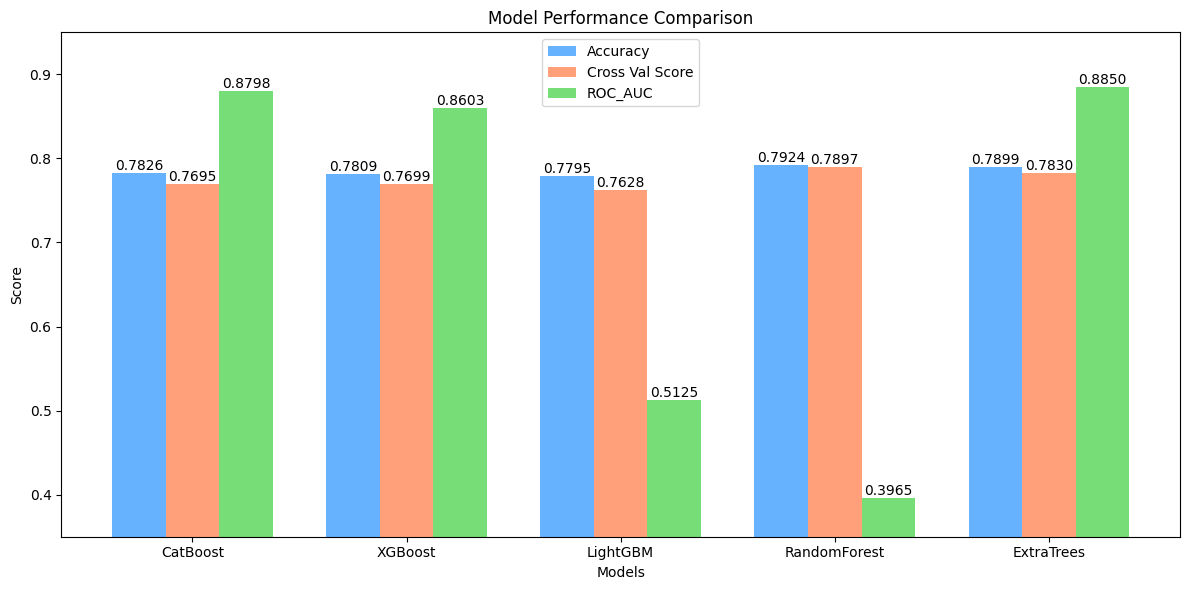

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 모델 이름
models = ['CatBoost', 'XGBoost', 'LightGBM', 'RandomForest', 'ExtraTrees']

# Accuracy와 Cross Validation Score, ROU_AUC
accuracy = [0.7826, 0.7809, 0.7795, 0.7924, 0.7899]
cross_val = [0.7695, 0.7699, 0.7628, 0.7897, 0.7830]
roc_auc = [0.8798, 0.8603, 0.5125, 0.3965, 0.8850]

# 막대 너비 설정
bar_width = 0.25
index = np.arange(len(models))

plt.figure(figsize=(12, 6))
bar1 = plt.bar(index, accuracy, bar_width, label='Accuracy', color='#66B2FF')
bar2 = plt.bar(index + bar_width, cross_val, bar_width, label='Cross Val Score', color='#FFA07A')
bar3 = plt.bar(index + bar_width * 2, roc_auc, bar_width, label='ROC_AUC', color='#77DD77')

# 그래프 세부 설정
plt.title('Model Performance Comparison')
plt.xlabel('Models')
plt.ylabel('Score')
plt.xticks(index + bar_width, models)
plt.ylim(0.35, 0.95)
plt.legend()

# 정확한 수치 표시
for bars in [bar1, bar2, bar3]:
    for bar in bars:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{bar.get_height():.4f}',
                 ha='center', va='bottom', fontsize=10)

plt.tight_layout()  # 그래프 간격 자동 조정
plt.show()

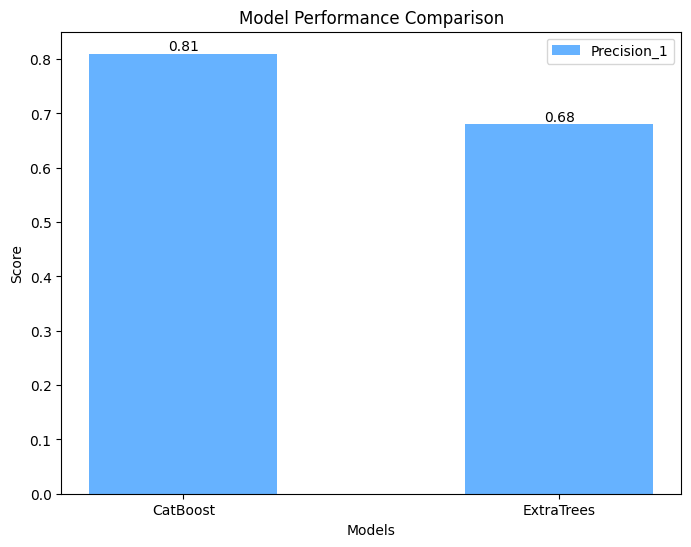

In [ ]:
# 모델 이름
models = ['CatBoost', 'ExtraTrees']

# precision(1)
precision_1 = [0.81, 0.68]

# 막대 너비 설정
bar_width = 0.5
index = np.arange(len(models))

plt.figure(figsize=(8, 6))
plt.bar(index, precision_1, bar_width, label='Precision_1', color='#66B2FF')

# 그래프 세부 설정
plt.title('Model Performance Comparison')
plt.xlabel('Models')
plt.ylabel('Score')
plt.xticks(index, models)
plt.legend()
for bar in plt.gca().patches:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{bar.get_height():.2f}', ha='center', va='bottom')

## CatBoost 모델 저장

기존 코드에서 확률 예측 코드까지 포함되게끔 모델을 저장하는 것은 불가함.

예측 모델만 저장하고, 해당 모델을 불러와서 확률을 구하는 코드를 실행하는 것이 맞음.

따라서 기존 코드를 간략하게 한 상태를 모델로 저장함.

In [ ]:
from sklearn.utils import resample
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import RandomizedSearchCV

# 데이터 불러오기
train_df = pd.read_csv('/content/train_dataset.csv')

# BMI 컬럼 생성
train_df['BMI'] = train_df['weight(kg)']/((train_df['height(cm)']/100)**2)

# 중성지방/HDL 비율 컬럼 생성
train_df['triglyceride/HDL'] = train_df['triglyceride']/train_df['HDL']

# LDL/HDL 비율 컬럼 생성
train_df['LDL/HDL'] = train_df['LDL']/train_df['HDL']

# BP Ratio(Systolic/Relaxation) 컬럼 생성
train_df['BP Ratio'] = train_df['systolic']/train_df['relaxation']

# 타겟 변수 분리
y = train_df['smoking']
X = train_df.drop(columns=['smoking'])

# Feature Engineering 적용
X = feature_engineering(X)

# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 데이터 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE 적용
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# 테스트 데이터에서 클래스 균형 맞추기 (언더샘플링)
non_smoking = X_test_scaled[y_test == 0]
smoking = X_test_scaled[y_test == 1]
y_non_smoking = y_test[y_test == 0]
y_smoking = y_test[y_test == 1]

non_smoking_downsampled, y_non_smoking_downsampled = resample(non_smoking, y_non_smoking,
                                                              replace=False,
                                                              n_samples=len(y_smoking),
                                                              random_state=42)

X_test_resampled = np.vstack((non_smoking_downsampled, smoking))
y_test_resampled = np.hstack((y_non_smoking_downsampled, y_smoking))

# 모델 리스트
model = CatBoostClassifier(verbose=0, random_state=42)

# 하이퍼파라미터 그리드 정의
param_grids = {'iterations': [1150, 1200], 'learning_rate': [0.01, 0.1], 'depth': [6, 10]}

# RandomizedSearchCV 사용
random_search = RandomizedSearchCV(estimator=model, param_distributions=param_grids, n_iter=10,
                                   cv=2, n_jobs=-1, verbose=2, random_state=42)
random_search.fit(X_train_resampled, y_train_resampled)

# 최적 모델로 예측
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test_resampled)

Fitting 2 folds for each of 8 candidates, totalling 16 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


In [ ]:
import joblib

# 모델 저장
joblib.dump(best_model, 'catboost_model.pkl')
print("모델 저장 완료")

모델 저장 완료


## test_df에 모델 적용

In [ ]:
test_df = pd.read_csv('/content/test_dataset.csv')
test_df['BMI'] = test_df['weight(kg)']/((test_df['height(cm)']/100)**2)
test_df['triglyceride/HDL'] = test_df['triglyceride']/test_df['HDL']
test_df['LDL/HDL'] = test_df['LDL']/test_df['HDL']
test_df['BP Ratio'] = test_df['systolic']/test_df['relaxation']
test_df = feature_engineering(test_df)

In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16708 entries, 0 to 16707
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      16708 non-null  int64  
 1   height(cm)               16708 non-null  int64  
 2   weight(kg)               16708 non-null  int64  
 3   waist(cm)                16708 non-null  float64
 4   eyesight(left)           16708 non-null  float64
 5   eyesight(right)          16708 non-null  float64
 6   hearing(left)            16708 non-null  int64  
 7   hearing(right)           16708 non-null  int64  
 8   systolic                 16708 non-null  int64  
 9   relaxation               16708 non-null  int64  
 10  fasting blood sugar      16708 non-null  int64  
 11  Cholesterol              16708 non-null  int64  
 12  triglyceride             16708 non-null  int64  
 13  HDL                      16708 non-null  int64  
 14  LDL                   

In [ ]:
# 모델 불러오기
model = joblib.load('catboost_model.pkl')

# 예측값 저장 (0 또는 1 예측값)
test_df['smoking_pred'] = model.predict(test_df)

# 금연 가능성 확률 (0일 확률)
prob = model.predict_proba(test_df)
test_df['smoking_prob_0'] = prob[:, 0]  # 0: 금연 가능성, 1: 흡연 확률

# 1번부터 순차적으로 번호 매기는 컬럼 추가
test_df['Patient_ID'] = range(1, len(test_df) + 1)

# 컬럼 순서 조정
cols = ['Patient_ID'] + [col for col in test_df.columns if col != 'Patient_ID']
test_df = test_df[cols]

# 결과 저장
test_df.to_csv('test_with_predictions.csv', index=False)
print("예측 결과 저장 완료")

예측 결과 저장 완료


In [ ]:
# train 데이터 저장(파생 변수 포함된)
train_with_feature = feature_engineering(train_df)
train_with_feature.to_csv('train_with_feature.csv', index=False)

train_with_feature.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38984 entries, 0 to 38983
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      38984 non-null  int64  
 1   height(cm)               38984 non-null  int64  
 2   weight(kg)               38984 non-null  int64  
 3   waist(cm)                38984 non-null  float64
 4   eyesight(left)           38984 non-null  float64
 5   eyesight(right)          38984 non-null  float64
 6   hearing(left)            38984 non-null  int64  
 7   hearing(right)           38984 non-null  int64  
 8   systolic                 38984 non-null  int64  
 9   relaxation               38984 non-null  int64  
 10  fasting blood sugar      38984 non-null  int64  
 11  Cholesterol              38984 non-null  int64  
 12  triglyceride             38984 non-null  int64  
 13  HDL                      38984 non-null  int64  
 14  LDL                   

# 한계점 및 개선점

< 한계점 >

- 데이터가 성별에 따라 구분되어 있지 않아, BMI나 간수치 등 성별에 따른 신체 지표를 통합해서 분석하는 데 어려움이 있었음.
성별에 따라 신체 지표의 평균값이나 범위가 다를 수 있기 때문에, 이를 일괄적으로 적용하기 어려운 점이 아쉬웠음.

- 금연을 결심하는 계기는 건강 문제뿐만 아니라 개인의 상황과 심리 상태에도 영향을 받으므로, 이러한 요소들이 반영된 데이터가 있었다면 더욱 정확한 분석과 예측이 가능했을 것이라고 생각됨.



---



< 개선점 >

추후에 데이터를 수집할 때 성별, 심리상태 등의 정보를 추가로 수집하는 것이 좋을 것 같음.